# TPC Digital Current → primary-density analysis v29

v29 keeps the successful v26/v27 live-BCO normalization and the v20-style recovery machinery, but changes how the new copper-coverage information is applied.

### Main v29 changes

- **Restore the old geometrical definition first**:
  \[
  \rho_{\rm pitch}=\frac{Q/\Delta BCO}{r\,\Delta r\,\Delta\phi}.
  \]
  This is exactly the v26/v27 pitch-cell density.

- **Apply the coverage fraction only as a second multiplicative correction**:
  \[
  \rho_{\rm corrected}=\frac{\rho_{\rm pitch}}{f_{\rm coverage}}.
  \]
  The pitch-cell area itself is no longer replaced throughout the reconstruction.

- **Zig-zag coverage is averaged per module by default.** The R1 layer-by-layer
  MedianFraction alternates strongly between roughly 0.506 and 0.564; v29 uses
  one robust median for all R1 zig-zag rows, and similarly one value for R2 and R3.
  The raw per-layer values are retained as QA. Set
  `TPC_DC_ZIGZAG_COVERAGE_MODE=layer` to test the unsmoothed table values.

- **Antenna pads keep their ring-specific coverage fractions**, so the much
  smaller antenna copper fraction naturally boosts the antenna density relative
  to normal zig-zag pads without an empirical attachment by default.

- **Both products are preserved**: pitch-cell density and coverage-corrected
  density. The raw physical-copper area is written only as a QA quantity.

- **Runtime bug fixed** in the run/reference overlay machinery:
  `gem={{}}` is corrected to `gem={}`. This was the `TypeError: unhashable type: 'dict'`
  that stopped the v28 cross-run ratio plots.

- The direct run/reference radial and phi ratios, alpha-through-stage stability,
  live-BCO vs Nsamples closure tests, fast GEM-current study, local r-phi cleaning,
  and all intermediate recovery products remain available.

The local SSD batch input remains:

```text
/media/yoren/T7_Shield/sPHENIX/tracking/dc/dc_run*.root
```


In [1]:
import ROOT as root
import numpy as np
import pandas as pd
import math, os, re, subprocess, json, glob
from pathlib import Path
from array import array
from scipy import ndimage
from scipy.optimize import least_squares
from concurrent.futures import ThreadPoolExecutor, as_completed

root.gROOT.SetBatch(True)
root.TH1.AddDirectory(False)
root.gStyle.SetOptStat(0)

# ============================================================
# USER CONFIGURATION
# ============================================================

INPUT_ROOT = os.environ.get(
    "TPC_DC_INPUT",
    "input/dc0/dc_run00080858_win00.root"
)

MAPPING_DIR = Path(os.environ.get(
    "TPC_DC_MAPPING_DIR",
    "/home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/TPC/ChannelMapping1/PadPlane/"
))
GAIN_MAP_FILE = Path(os.environ.get(
    "TPC_DC_GAIN_MAP",
    "../distort/input/layer_gain_79513_Mariia_side01.root"
))

GAIN_MAP_HIST_SIDE0 = "hGainMap_side0_South"
GAIN_MAP_HIST_SIDE1 = "hGainMap_side1_North"
GAIN_LAYER_OFFSET = 7
APPLY_STANDARD_PAD_GAIN = True

DC_VARIANTS = ("raw", "ped60_signed", "ped60_positive", "ped60_strict")
MAIN_VARIANT = os.environ.get("TPC_DC_VARIANT", "ped60_signed")
DEFECT_VARIANT = os.environ.get("TPC_DC_DEFECT_VARIANT", "ped60_positive")
if MAIN_VARIANT not in DC_VARIANTS:
    raise ValueError(f"Unknown MAIN_VARIANT={MAIN_VARIANT}")
if DEFECT_VARIANT not in DC_VARIANTS:
    raise ValueError(f"Unknown DEFECT_VARIANT={DEFECT_VARIANT}")

N_SIDES, N_SECTORS, N_MODULES, LAYERS_PER_MODULE = 2, 12, 3, 16
N_PADS = {0:94, 1:128, 2:192}
PHI_MIN, PHI_MAX = -math.pi, math.pi
GLOBAL_PHI_BINS = 720
SOURCE_R_MIN_CM = 22.0
SOURCE_R_MAX_CM = 76.0
GLOBAL_DR_CM = 0.10

# ------------------------------------------------------------
# v29 copper-coverage correction
# ------------------------------------------------------------
# IMPORTANT: keep the successful v26/v27 definition first:
#
#     rho_pitch = (Q / live_BCO) / (r * dr * dphi)
#
# and only THEN apply the independent copper/active-fraction correction:
#
#     rho_corrected = rho_pitch / coverage_fraction
#
# This avoids changing the meaning of the geometrical pitch cell throughout
# the reconstruction. Both rho_pitch and rho_corrected are retained for QA.
#
# coverage_by_layer.csv gives the copper fraction inside the pitch cell.
# R1 zig-zag layer-by-layer MedianFraction alternates strongly (~0.506/0.564),
# so by default zig-zag pads use ONE median fraction per module. This prevents
# an artificial odd/even radial modulation from the coverage calculation.
# Antenna pads keep their ring-specific fractions (~0.106-0.138).
COVERAGE_TABLE_FILE = Path(os.environ.get(
    "TPC_DC_COVERAGE_TABLE", "coverage_by_layer.csv"
))
COVERAGE_SCOPE = os.environ.get("TPC_DC_COVERAGE_SCOPE", "interior")
COVERAGE_COLUMN = os.environ.get("TPC_DC_COVERAGE_COLUMN", "MedianFraction")

APPLY_COVERAGE_CORRECTION = (
    os.environ.get("TPC_DC_APPLY_COVERAGE_CORRECTION", "1") == "1"
)
ZIGZAG_COVERAGE_MODE = os.environ.get(
    "TPC_DC_ZIGZAG_COVERAGE_MODE", "module_median"
)
if ZIGZAG_COVERAGE_MODE not in ("module_median", "layer"):
    raise ValueError(
        f"Unknown ZIGZAG_COVERAGE_MODE={ZIGZAG_COVERAGE_MODE}; "
        "use module_median or layer"
    )

# v29: Digital Current is treated as an INTEGRATED signal over the
# synchronized live BCO interval after pedestal subtraction. Nsamples remains
# important for pedestal subtraction and readout QA, but it is not assumed to
# be a common live-time denominator.
DC_TIME_NORMALIZATION = os.environ.get("TPC_DC_TIME_NORM", "live_bco")
if DC_TIME_NORMALIZATION not in ("live_bco", "nsamples"):
    raise ValueError(f"Unknown DC_TIME_NORMALIZATION={DC_TIME_NORMALIZATION}")

# Keep PHGarfield source range separately.
PHGARFIELD_R_MIN_CM = 22.8
PHGARFIELD_R_MAX_CM = 75.43

# ------------------------------------------------------------
# Native defect detection / recovery, inherited from v20
# ------------------------------------------------------------
MIN_EXPOSURE_FRACTION = 0.50
DEAD_CELL_REL_THRESHOLD = 0.18

MIN_DEAD_FEE_WIDTH = 2
DEAD_FEE_LAYER_FRACTION = 0.45
FEE_BRIDGE_PADS = 2
FEE_CONTEXT_PADS = 12
FEE_MIN_CONTEXT_CELLS = 4
FEE_CONTEXT_MEDIAN_LAYERS = 3
FEE_CONTEXT_GAUSS_SIGMA_LAYERS = 0.8

STRIPE_REL_THRESHOLD = 0.28
FULL_STRIPE_FRACTION = 0.70
HALF_STRIPE_FRACTION = 0.70
OTHER_HALF_MAX_DEAD_FRACTION = 0.35
STRIPE_NEIGHBOR_LAYERS = 3
ALLOW_R3_HALF_STRIPES = True

MIN_DEAD_BLOCK_WIDTH = 2
MIN_DEAD_BLOCK_LAYERS = 2
MIN_DEAD_BLOCK_CELLS = 6
BLOCK_CONTEXT_PADS = 12
BLOCK_CONTEXT_LAYERS = 3

REPAIR_SINGLE_OUTLIERS = True
SINGLE_DEAD_FACTOR = 0.25
SINGLE_HOT_FACTOR = 2.5
SINGLE_OUTLIER_PAD_RADIUS = 2
SINGLE_OUTLIER_LAYER_RADIUS = 1
SINGLE_OUTLIER_MIN_NEIGHBORS = 5
SINGLE_OUTLIER_PASSES = 2

# Native smoothing is intentionally modest. Strong smoothing is done later
# by the explicit physics model, and all intermediate stages are retained.
SMOOTH_NATIVE_MAPS = True
SMOOTH_PAD_RADIUS = 2
SMOOTH_LAYER_RADIUS = 1
SMOOTH_BLEND = 0.75

# ------------------------------------------------------------
# v29 local r-phi afterburner
#
# Work on physical TPC rows x coarse phi bins, independently inside R1/R2/R3.
# The filter removes coherent local spikes/dips without changing each row's
# radial median. Raw/recovered products are always preserved separately.
# ------------------------------------------------------------
LOCAL_RPHI_ENABLED = os.environ.get("TPC_DC_LOCAL_RPHI", "1") == "1"
LOCAL_RPHI_LAYER_RADIUS = int(os.environ.get("TPC_DC_LOCAL_RPHI_LAYER_RADIUS", "1"))
LOCAL_RPHI_PHI_RADIUS = int(os.environ.get("TPC_DC_LOCAL_RPHI_PHI_RADIUS", "2"))
LOCAL_RPHI_OUTLIER_NSIGMA = float(os.environ.get("TPC_DC_LOCAL_RPHI_NSIGMA", "4.0"))
LOCAL_RPHI_ROW_OUTLIER_NSIGMA = float(os.environ.get("TPC_DC_LOCAL_RPHI_ROW_NSIGMA", "4.0"))
LOCAL_RPHI_MIN_NEIGHBORS = int(os.environ.get("TPC_DC_LOCAL_RPHI_MIN_NEIGHBORS", "6"))
LOCAL_RPHI_SMOOTH_BLEND = float(os.environ.get("TPC_DC_LOCAL_RPHI_BLEND", "0.75"))
LOCAL_RPHI_ITERATIONS = int(os.environ.get("TPC_DC_LOCAL_RPHI_ITERATIONS", "2"))
LOCAL_RPHI_USE_FOR_MODEL = os.environ.get("TPC_DC_LOCAL_RPHI_USE_FOR_MODEL", "1") == "1"
LOCAL_RPHI_APPLY_TO_FINAL = os.environ.get("TPC_DC_LOCAL_RPHI_APPLY_FINAL", "1") == "1"

# Explicit radial profiles in fixed phi slices. v29 writes both TH1D and
# TGraphErrors versions. The graph contains only finite points and is the
# preferred ROOT-browser object for sparse antenna + TPC radial coverage.
PHI_SLICE_COUNT = int(os.environ.get("TPC_DC_PHI_SLICE_COUNT", "24"))
PHI_SLICE_MIN_VALID_BINS = int(os.environ.get("TPC_DC_PHI_SLICE_MIN_VALID", "2"))

ADC_ESTIMATOR = "trimmed_mean"
TRIM_FRACTION = 0.15
CLIP_OUTLIERS = True
CLIP_NSIGMA = 5.0

# ------------------------------------------------------------
# Empirical R1 power-law fits
# ------------------------------------------------------------
ALPHA_BOUNDS = (0.0, 4.0)
ALPHA_INITIAL = 1.8
R1_FIT_N_LAYERS = 12       # now means 12 PHYSICAL R1 layers, not 0.1-cm grid bins
R1_FIT_RMIN_CM = 31.0
R1_FIT_RMAX_CM = 40.5

# ------------------------------------------------------------
# Smooth two-source physics model
#
# rho(r,phi) =
#   A_collision * (Rref/r)^alpha_collision
# + A_beam      * (Rref/r)^alpha_beam
#     * [1 + epsilon*cos(phi-phi0)]
#
# The two alpha values are kept configurable. By default they encode the
# expected broad collision component (~1.23, flat phi) and a more central
# beam-background component (~2, one preferred phi direction).
# ------------------------------------------------------------
COLLISION_ALPHA_INITIAL = float(os.environ.get("TPC_DC_COLLISION_ALPHA_INITIAL", "1.23"))
COLLISION_ALPHA_BOUNDS = (1.0, 1.5)
BEAM_ALPHA_INITIAL = float(os.environ.get("TPC_DC_BEAM_ALPHA_INITIAL", "2.0"))
BEAM_ALPHA_BOUNDS = (1.5, 2.5)
PHYSICS_MODEL_RREF_CM = 40.0
PHYSICS_MODEL_RMIN_CM = 31.0
PHYSICS_MODEL_RMAX_CM = 76.0
PHYSICS_MODEL_PHI_BINS = 72
PHYSICS_MODEL_MIN_PER_BIN = 6
PHYSICS_MODEL_EPS_MAX = 0.80
PHYSICS_MODEL_SCALE_MIN = 0.50
PHYSICS_MODEL_SCALE_MAX = 2.00
PHYSICS_MODEL_ERROR_FLOOR = 0.03

# Layer-response calibration is derived across all files as a separate QA
# product. Do not silently apply it during the first pass.
APPLY_LAYER_RESPONSE_CORRECTION = (
    os.environ.get("TPC_DC_APPLY_LAYER_CORRECTION", "0") == "1"
)
LAYER_RESPONSE_FILE = Path(os.environ.get(
    "TPC_DC_LAYER_RESPONSE_FILE",
    "output_dc/TPC_DC_layer_response_v29.csv"
))

# ------------------------------------------------------------
# Antenna QA
# ------------------------------------------------------------
ANTENNA_LOG_MAD_NSIGMA = 6.0
ANTENNA_MIN_EXPOSURE_FRACTION = 0.50
ANTENNA_REPAIR_PHI_RADIUS = 2
ANTENNA_REPAIR_RING_RADIUS = 1
ANTENNA_REPAIR_PASSES = 2
ANTENNA_PHI_SMOOTH = os.environ.get("TPC_DC_ANTENNA_PHI_SMOOTH", "1") == "1"
ANTENNA_PHI_SMOOTH_RADIUS = int(os.environ.get("TPC_DC_ANTENNA_PHI_RADIUS", "1"))
ANTENNA_PHI_SMOOTH_BLEND = float(os.environ.get("TPC_DC_ANTENNA_PHI_BLEND", "0.70"))

# The global DC histogram was filled in the preprocessing eBDC phi convention.
# Keep that lookup coordinate separate from the canonical IdealPadMap-like phi
# used to place the reconstructed antenna cell into the final r-phi map.
ANTENNA_GLOBAL_LOOKUP_MODE = os.environ.get(
    "TPC_DC_ANTENNA_LOOKUP_MODE", "dc_preprocessing"
)
if ANTENNA_GLOBAL_LOOKUP_MODE not in ("dc_preprocessing", "idealpadmap"):
    raise ValueError(f"Unknown ANTENNA_GLOBAL_LOOKUP_MODE={ANTENNA_GLOBAL_LOOKUP_MODE}")
ANTENNA_COMPARE_LOOKUP_MODES = True

# Optional empirical relative-response attachment. Raw antenna values are always
# preserved. Modes:
#   none       : no response scaling
#   outer_ring : one common factor chosen so A3 matches the empirical R1 extrapolation
#   one_scale  : one common robust factor from all four antenna rings
ANTENNA_ATTACH_MODE = os.environ.get("TPC_DC_ANTENNA_ATTACH_MODE", "none")
if ANTENNA_ATTACH_MODE not in ("none", "outer_ring", "one_scale"):
    raise ValueError(f"Unknown ANTENNA_ATTACH_MODE={ANTENNA_ATTACH_MODE}")
ANTENNA_ATTACH_FACTOR_MIN = 0.01
ANTENNA_ATTACH_FACTOR_MAX = 100.0

# ------------------------------------------------------------
# Output and batch
# ------------------------------------------------------------
def infer_run(path):
    m=re.search(r"run0*(\d{5})", str(path))
    return int(m.group(1)) if m else -1

def infer_window(path):
    m=re.search(r"win0*(\d+)", str(path))
    return int(m.group(1)) if m else -1

RUN_NUMBER = infer_run(INPUT_ROOT)
WINDOW_NUMBER = infer_window(INPUT_ROOT)

if RUN_NUMBER > 0 and WINDOW_NUMBER >= 0:
    default_tag = f"run{RUN_NUMBER}_win{WINDOW_NUMBER:02d}"
elif RUN_NUMBER > 0:
    default_tag = f"run{RUN_NUMBER}"
else:
    default_tag = Path(INPUT_ROOT).stem

RUN_TAG = os.environ.get("TPC_DC_TAG", default_tag)
IS_BATCH_CHILD = os.environ.get("TPC_DC_BATCH_CHILD", "0") == "1"

OUTPUT_DIR = Path(os.environ.get("TPC_DC_OUTPUT_DIR", "output_dc"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
QA_PLOT_DIR = OUTPUT_DIR / f"qa_v29_{RUN_TAG}"
QA_PLOT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_ROOT = OUTPUT_DIR / f"TPC_DC_primary_density_v29_{RUN_TAG}.root"
OUTPUT_SUMMARY = OUTPUT_DIR / f"TPC_DC_summary_v29_{RUN_TAG}.csv"
OUTPUT_LAYER_PROFILE = OUTPUT_DIR / f"TPC_DC_layer_profile_v29_{RUN_TAG}.csv"
OUTPUT_STAGE_LAYER_PROFILE = OUTPUT_DIR / f"TPC_DC_layer_stages_v29_{RUN_TAG}.csv"
OUTPUT_PHI_PROFILE = OUTPUT_DIR / f"TPC_DC_phi_profile_v29_{RUN_TAG}.csv"
OUTPUT_PREAREA_LAYER_PROFILE = OUTPUT_DIR / f"TPC_DC_prearea_layers_v29_{RUN_TAG}.csv"
OUTPUT_LOCAL_RPHI_PROFILE = OUTPUT_DIR / f"TPC_DC_local_rphi_v29_{RUN_TAG}.csv"
OUTPUT_NORM_CLOSURE = OUTPUT_DIR / f"TPC_DC_norm_closure_v29_{RUN_TAG}.csv"
OUTPUT_PHI_STAGE_PROFILE = OUTPUT_DIR / f"TPC_DC_phi_stages_v29_{RUN_TAG}.csv"

# Cross-run shape-stability reference. 80858 is present in the current Takao
# set and is used only as a ratio reference, not as a physics calibration.
SHAPE_REFERENCE_RUN = int(os.environ.get("TPC_DC_SHAPE_REFERENCE_RUN", "80858"))
SHAPE_RATIO_STAGES = ("measured", "structure", "stripes", "outliers", "smoothed")


# All 57 local Takao-window files are flat in this directory.
BATCH_INPUT_GLOB = os.environ.get(
    "TPC_DC_BATCH_GLOB",
    "/media/yoren/T7_Shield/sPHENIX/tracking/dc/dc_run*.root"
)
BATCH_FAST_MODE = os.environ.get("TPC_DC_BATCH_FAST", "1") == "1"
BATCH_MAX_WORKERS = int(os.environ.get("TPC_DC_BATCH_WORKERS", "6"))

# Full spatial reconstruction is expensive. By default, v29 uses only one
# representative synchronized window per run (middle window = 1).
SPATIAL_BATCH_ONE_WINDOW_PER_RUN = (
    os.environ.get("TPC_DC_SPATIAL_ONE_WINDOW", "1") == "1"
)
SPATIAL_BATCH_WINDOW = int(os.environ.get("TPC_DC_SPATIAL_WINDOW", "1"))

# The GEM-current study is lightweight and reads all available windows
# directly from the original DC ROOT files. It does NOT execute the full
# primary-density notebook for each window.
LIGHTWEIGHT_GEM_VARIANT = os.environ.get("TPC_DC_GEM_VARIANT", "ped60_signed")
LIGHTWEIGHT_GEM_REFERENCE_RUN = int(os.environ.get("TPC_DC_REFERENCE_RUN", "80858"))

# Full interactive QA keeps all four variants. Batch children skip only the
# expensive legacy strict variant by default; raw, signed and positive remain
# available for the R2/R3 and pedestal diagnostics.
if IS_BATCH_CHILD and BATCH_FAST_MODE:
    PROCESS_VARIANTS = tuple(dict.fromkeys(("raw", MAIN_VARIANT, DEFECT_VARIANT)))
else:
    PROCESS_VARIANTS = DC_VARIANTS

NOTEBOOK_FILE = Path(os.environ.get(
    "TPC_DC_NOTEBOOK",
    "TPC_IBF_PrimaryDensity_Extraction_v29_DC.ipynb"
))
REFERENCE_RUN = int(os.environ.get("TPC_DC_REFERENCE_RUN", "80858"))

print("Input:", INPUT_ROOT)
print("Run/window:", RUN_NUMBER, WINDOW_NUMBER)
print("Mapping:", MAPPING_DIR)
print("Gain map:", GAIN_MAP_FILE)
print("Main variant:", MAIN_VARIANT)
print("DC time normalization:", DC_TIME_NORMALIZATION)
print("Defect-detection variant:", DEFECT_VARIANT)
print("Processed variants:", PROCESS_VARIANTS)
print("Output:", OUTPUT_ROOT)
print("Batch glob:", BATCH_INPUT_GLOB)


Welcome to JupyROOT 6.30/06
Input: input/dc0/dc_run00080858_win00.root
Run/window: 80858 0
Mapping: /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/TPC/ChannelMapping1/PadPlane
Gain map: ../distort/input/layer_gain_79513_Mariia_side01.root
Main variant: ped60_signed
DC time normalization: live_bco
Defect-detection variant: ped60_positive
Processed variants: ('raw', 'ped60_signed', 'ped60_positive', 'ped60_strict')
Output: output_dc/TPC_DC_primary_density_v29_run80858_win00.root
Batch glob: /media/yoren/T7_Shield/sPHENIX/tracking/dc/dc_run*.root



## 1. Mapping geometry

The standard 48 TPC rows and the four R1 antenna rings are kept as **separate radial systems**.

For a standard TPC row, the radial collection width is the local layer pitch:
- interior: half the distance between the neighboring row centers;
- first row: distance to the second row;
- last row: distance to the previous row.

This is the same first/last convention used by `IdealPadMap::get_layer_thickness`. It avoids the v21 problem where the first standard R1 layer was widened toward the last antenna ring.

For φ, the mapping CSV stores the local CDB pad φ. The global side/sector transformation below follows the current `IdealPadMap` convention.


In [2]:

def load_mapping(region):
    p = MAPPING_DIR / f"AutoPad-{region}-RevA.sch.ChannelMapping.csv"
    if not p.exists():
        raise FileNotFoundError(
            f"Missing {p}. Set TPC_DC_MAPPING_DIR to "
            "DC_ML_processing/1_dc_preprocessing."
        )
    df=pd.read_csv(p)
    required={"Radius","Pad","PadName","PadR","PadPhi","FEE","FEE_Chan"}
    missing=required-set(df.columns)
    if missing:
        raise KeyError(f"{p} missing columns {sorted(missing)}")
    return df

mapping={m:load_mapping(f"R{m+1}") for m in range(3)}

# Snapshot of the user-provided coverage table.  If COVERAGE_TABLE_FILE is
# available it is used, so updated geometry tables can be tested without
# editing the notebook.  Otherwise this snapshot keeps v29 self-contained.
_COVERAGE_FALLBACK = {('R1', 'antenna', 0): 0.1377410984046115, ('R1', 'antenna', 1): 0.1249682347269857, ('R1', 'antenna', 2): 0.1144128902043639, ('R1', 'antenna', 3): 0.1055314891717958, ('R1', 'zigzag', 0): 0.5659048406219811, ('R1', 'zigzag', 1): 0.5057101529699684, ('R1', 'zigzag', 2): 0.5632970867290367, ('R1', 'zigzag', 3): 0.5060024455363279, ('R1', 'zigzag', 4): 0.5635697197580969, ('R1', 'zigzag', 5): 0.5062730374126768, ('R1', 'zigzag', 6): 0.5638505116623996, ('R1', 'zigzag', 7): 0.5064660087830619, ('R1', 'zigzag', 8): 0.5640852838658585, ('R1', 'zigzag', 9): 0.5067015303337137, ('R1', 'zigzag', 10): 0.5642486692961238, ('R1', 'zigzag', 11): 0.5069160275739729, ('R1', 'zigzag', 12): 0.5645547909305708, ('R1', 'zigzag', 13): 0.5070482384837957, ('R1', 'zigzag', 14): 0.5647179936445584, ('R1', 'zigzag', 15): 0.50997420239251, ('R2', 'zigzag', 0): 0.6113206594441606, ('R2', 'zigzag', 1): 0.611396650097997, ('R2', 'zigzag', 2): 0.6114392461373208, ('R2', 'zigzag', 3): 0.6115303918219113, ('R2', 'zigzag', 4): 0.6115391978708746, ('R2', 'zigzag', 5): 0.611616304777163, ('R2', 'zigzag', 6): 0.6115631523851366, ('R2', 'zigzag', 7): 0.6116502544246458, ('R2', 'zigzag', 8): 0.6116778051185754, ('R2', 'zigzag', 9): 0.6116318265060707, ('R2', 'zigzag', 10): 0.6117342487426307, ('R2', 'zigzag', 11): 0.6116968324072551, ('R2', 'zigzag', 12): 0.6117678656969971, ('R2', 'zigzag', 13): 0.611735766900447, ('R2', 'zigzag', 14): 0.6117637518795949, ('R2', 'zigzag', 15): 0.6117618321848141, ('R3', 'zigzag', 0): 0.6158919456160623, ('R3', 'zigzag', 1): 0.616003604765087, ('R3', 'zigzag', 2): 0.6161120023129798, ('R3', 'zigzag', 3): 0.6161904983036954, ('R3', 'zigzag', 4): 0.6162750937109914, ('R3', 'zigzag', 5): 0.6163408471018442, ('R3', 'zigzag', 6): 0.6164540790915224, ('R3', 'zigzag', 7): 0.6165006849739457, ('R3', 'zigzag', 8): 0.6165722093934449, ('R3', 'zigzag', 9): 0.6166294141316955, ('R3', 'zigzag', 10): 0.6166992114911716, ('R3', 'zigzag', 11): 0.6167626971696192, ('R3', 'zigzag', 12): 0.6168101567347879, ('R3', 'zigzag', 13): 0.6168724019628199, ('R3', 'zigzag', 14): 0.616913045812197, ('R3', 'zigzag', 15): 0.616965262566706}

def _find_coverage_table():
    candidates=[COVERAGE_TABLE_FILE, Path.cwd()/COVERAGE_TABLE_FILE.name,
                MAPPING_DIR/COVERAGE_TABLE_FILE.name,
                Path(INPUT_ROOT).resolve().parent/COVERAGE_TABLE_FILE.name]
    for p in candidates:
        try:
            p=Path(p)
            if p.exists(): return p
        except Exception:
            pass
    return None

def load_copper_fraction_lookup():
    p=_find_coverage_table()
    if p is None:
        print("coverage table not found; using embedded v29 snapshot")
        return dict(_COVERAGE_FALLBACK), "embedded snapshot"
    d=pd.read_csv(p)
    required={"Module","PadType","LayerIndex","Scope",COVERAGE_COLUMN}
    miss=required-set(d.columns)
    if miss:
        raise KeyError(f"{p} missing coverage columns {sorted(miss)}")
    q=d[d["Scope"].astype(str)==COVERAGE_SCOPE].copy()
    lut={(str(r.Module),str(r.PadType),int(r.LayerIndex)):float(getattr(r,COVERAGE_COLUMN))
         for _,r in q.iterrows()}
    print(f"Loaded copper fractions from {p}: {len(lut)} layer entries")
    return lut, str(p)

COPPER_FRACTION_LOOKUP, COPPER_FRACTION_SOURCE = load_copper_fraction_lookup()

def wrap_phi(phi):
    return (np.asarray(phi)+math.pi)%(2*math.pi)-math.pi

def centered_widths(x):
    """Pitch-cell width around centers without coupling separate detector systems."""
    x=np.asarray(x,float)
    if len(x)<2:
        return np.ones_like(x)
    w=np.empty_like(x)
    w[1:-1]=0.5*(x[2:]-x[:-2])
    w[0]=x[1]-x[0]
    w[-1]=x[-1]-x[-2]
    return np.abs(w)

def circular_pitch_widths(phi):
    """Per-pad local angular pitch from ordered local pad centers."""
    p=np.unwrap(np.asarray(phi,float))
    return centered_widths(p)

def row_geometry(df, radius_index):
    r=df[df["Radius"]==radius_index].copy().sort_values("Pad")
    if r.empty:
        raise KeyError(f"No Radius={radius_index}")
    return {
        "radius_index":int(radius_index),
        "r_cm":float(np.mean(r["PadR"]))/10.0,
        "n_pads":len(r),
        "phi_local":r["PadPhi"].to_numpy(float),
        "local_pad":r["Pad"].to_numpy(int),
        "pad_name":r["PadName"].astype(str).to_numpy(),
        "fee":r["FEE"].to_numpy(int),
        "fee_chan":r["FEE_Chan"].to_numpy(int),
    }

zigzag_rows={m:[row_geometry(mapping[m],il) for il in range(16)] for m in range(3)}
antenna_rows=[row_geometry(mapping[0],il) for il in (-4,-3,-2,-1)]

for m in range(3):
    for il,row in enumerate(zigzag_rows[m]):
        row["module_index"]=m
        row["module_name"]=f"R{m+1}"
        row["pad_type"]="zigzag"
        row["coverage_layer"]=il
        row["copper_fraction_raw"]=float(
            COPPER_FRACTION_LOOKUP.get((f"R{m+1}","zigzag",il),1.0)
        )

# One robust zig-zag fraction per module by default. Keep the raw layer values
# separately for QA and allow TPC_DC_ZIGZAG_COVERAGE_MODE=layer as a cross-check.
ZIGZAG_MODULE_COVERAGE={}
for m in range(3):
    vals=np.array(
        [r["copper_fraction_raw"] for r in zigzag_rows[m]],float
    )
    vals=vals[np.isfinite(vals)&(vals>0)]
    ZIGZAG_MODULE_COVERAGE[m]=float(np.nanmedian(vals)) if len(vals) else 1.0

for ia,row in enumerate(antenna_rows):
    row["module_index"]=0
    row["module_name"]="R1"
    row["pad_type"]="antenna"
    row["coverage_layer"]=ia
    row["copper_fraction_raw"]=float(
        COPPER_FRACTION_LOOKUP.get(("R1","antenna",ia),1.0)
    )

# Standard radial widths are derived separately within R1/R2/R3.
for m in range(3):
    centers=np.array([r["r_cm"] for r in zigzag_rows[m]],float)
    widths=centered_widths(centers)
    for il,row in enumerate(zigzag_rows[m]):
        row["dr_cm"]=float(widths[il])
        row["rlo"]=row["r_cm"]-0.5*row["dr_cm"]
        row["rhi"]=row["r_cm"]+0.5*row["dr_cm"]
        row["dphi_pad"]=circular_pitch_widths(row["phi_local"])

# Antenna rings are a separate radial system. Do not couple outer antenna width to R1.
ant_centers=np.array([r["r_cm"] for r in antenna_rows],float)
ant_widths=centered_widths(ant_centers)
for ia,row in enumerate(antenna_rows):
    row["dr_cm"]=float(ant_widths[ia])
    row["rlo"]=row["r_cm"]-0.5*row["dr_cm"]
    row["rhi"]=row["r_cm"]+0.5*row["dr_cm"]
    row["dphi_pad"]=circular_pitch_widths(row["phi_local"])

def global_phi_for_pad(row, side, sector, pad_index):
    """
    Reproduce current IdealPadMap side/sector transformation using
    local CDB phi from the mapping file.
    """
    npads=row["n_pads"]
    lookup=pad_index if side==0 else npads-1-pad_index
    cdb_phi=float(row["phi_local"][lookup])
    mapped_sector=(5 + N_SECTORS - (sector % N_SECTORS)) % N_SECTORS
    phi=((1.0 if side==1 else -1.0)*(cdb_phi-math.pi/2.0)
         + mapped_sector*math.pi/6.0)
    return float(wrap_phi(phi))

def global_phi_for_dc_preprocessing(row, side, sector, pad_index):
    """
    Phi convention used when the DC preprocessing filled the already-global
    phi-r histograms: mapped PadPhi plus the eBDC sector shift.

    This is a LOOKUP coordinate only. The final canonical r-phi output still
    uses global_phi_for_pad(), which follows the IdealPadMap convention.
    """
    ebdc = int(sector) + (12 if int(side)==1 else 0)
    local_phi = float(row["phi_local"][pad_index])
    return float(wrap_phi(local_phi + (ebdc - 12)*math.pi/6.0))

def antenna_lookup_phi(row, side, sector, pad_index, mode=ANTENNA_GLOBAL_LOOKUP_MODE):
    if mode == "dc_preprocessing":
        return global_phi_for_dc_preprocessing(row,side,sector,pad_index)
    if mode == "idealpadmap":
        return global_phi_for_pad(row,side,sector,pad_index)
    raise ValueError(mode)

def pad_pitch_area_cm2(row, pad_index):
    return row["r_cm"] * float(row["dphi_pad"][pad_index]) * row["dr_cm"]

def pad_raw_copper_fraction(row):
    """Layer/ring value directly from coverage_by_layer.csv."""
    f=float(row.get("copper_fraction_raw",1.0))
    return f if np.isfinite(f) and f>0 else 1.0

def pad_applied_coverage_fraction(row):
    """
    Fraction used by v29 as a SECOND correction after the pitch-cell density.

    Zig-zag:
      module_median (default) -> constant within R1, R2, R3
      layer                   -> raw layer value from the table
    Antenna:
      ring-specific raw fraction
    """
    if not APPLY_COVERAGE_CORRECTION:
        return 1.0
    if row.get("pad_type")=="zigzag" and ZIGZAG_COVERAGE_MODE=="module_median":
        f=float(ZIGZAG_MODULE_COVERAGE.get(int(row["module_index"]),1.0))
    else:
        f=pad_raw_copper_fraction(row)
    return f if np.isfinite(f) and f>0 else 1.0

def pad_active_area_cm2(row, pad_index):
    """Physical copper area using the RAW row/ring fraction, for QA only."""
    return pad_pitch_area_cm2(row,pad_index) * pad_raw_copper_fraction(row)

def pad_area_cm2(row, pad_index):
    """Base geometrical denominator. v29 ALWAYS starts from the pitch cell."""
    return pad_pitch_area_cm2(row,pad_index)

def apply_coverage_to_density(rho_pitch,row):
    f=pad_applied_coverage_fraction(row)
    return rho_pitch/f if np.isfinite(rho_pitch) and np.isfinite(f) and f>0 else np.nan

print("Standard radial geometry:")
for m in range(3):
    rr=np.array([r["r_cm"] for r in zigzag_rows[m]])
    dr=np.array([r["dr_cm"] for r in zigzag_rows[m]])
    dp=np.concatenate([r["dphi_pad"] for r in zigzag_rows[m]])
    print(f" R{m+1}: r={rr[0]:.4f}..{rr[-1]:.4f} cm, "
          f"dr median={np.median(dr):.5f} cm, "
          f"dphi median={np.median(dp):.7f}")

print(
    f"Coverage correction: {APPLY_COVERAGE_CORRECTION}; "
    f"zigzag mode={ZIGZAG_COVERAGE_MODE}; source={COPPER_FRACTION_SOURCE}"
)
for m in range(3):
    raw=[pad_raw_copper_fraction(r) for r in zigzag_rows[m]]
    app=[pad_applied_coverage_fraction(r) for r in zigzag_rows[m]]
    print(
        f" R{m+1} zigzag raw fraction: {min(raw):.4f}..{max(raw):.4f}, "
        f"raw median={np.median(raw):.4f}; applied={np.median(app):.4f}"
    )
print(
    " antenna ring fractions:",
    [round(pad_applied_coverage_fraction(r),6) for r in antenna_rows]
)

print("Antenna radial geometry:")
for ia,row in enumerate(antenna_rows):
    print(f" A{ia}: r={row['r_cm']:.4f} cm, dr={row['dr_cm']:.4f} cm, "
          f"pads/sector={row['n_pads']}")

print("\nCritical v21 comparison:")
print(" first standard R1 dr in v29 =",zigzag_rows[0][0]["dr_cm"],"cm")
print(" nominal R1 pitch            =",zigzag_rows[0][1]["r_cm"]-zigzag_rows[0][0]["r_cm"],"cm")

coverage table not found; using embedded v29 snapshot
Standard radial geometry:
 R1: r=31.4984..39.9852 cm, dr median=0.56599 cm, dphi median=0.0053073
 R2: r=41.6592..56.9695 cm, dr median=1.02069 cm, dphi median=0.0039592
 R3: r=58.9110..75.3667 cm, dr median=1.09705 cm, dphi median=0.0026514
Coverage correction: True; zigzag mode=module_median; source=embedded snapshot
 R1 zigzag raw fraction: 0.5057..0.5659, raw median=0.5366; applied=0.5366
 R2 zigzag raw fraction: 0.6113..0.6118, raw median=0.6116; applied=0.6116
 R3 zigzag raw fraction: 0.6159..0.6170, raw median=0.6165; applied=0.6165
 antenna ring fractions: [0.137741, 0.124968, 0.114413, 0.105531]
Antenna radial geometry:
 A0: r=23.2776 cm, dr=2.2622 cm, pads/sector=8
 A1: r=25.5398 cm, dr=2.2622 cm, pads/sector=8
 A2: r=27.8020 cm, dr=2.2622 cm, pads/sector=8
 A3: r=30.0643 cm, dr=2.2622 cm, pads/sector=8

Critical v21 comparison:
 first standard R1 dr in v29 = 0.5630560144543253 cm
 nominal R1 pitch            = 0.563056014


## 2. Read synchronized DC ROOT input

Normal TPC rows use native `pad × layer` histograms. Antenna rings are reconstructed from the global `φ × r × frame` histograms because the present preprocessing does not yet write native antenna histograms.

Every DC quantity is normalized by its matching `nsamples` exposure.


In [3]:
fin=root.TFile.Open(str(INPUT_ROOT),"READ")
if not fin or fin.IsZombie():
    raise OSError(f"Cannot open {INPUT_ROOT}")

def th2_to_numpy(h):
    nx,ny=h.GetNbinsX(),h.GetNbinsY()
    z=np.empty((ny,nx),float)
    for iy in range(ny):
        for ix in range(nx):
            z[iy,ix]=h.GetBinContent(ix+1,iy+1)
    return z

def project_xy_numpy(h3):
    nr,nphi=h3.GetNbinsY(),h3.GetNbinsX()
    out=np.zeros((nr,nphi),float)
    for ir in range(1,nr+1):
        for ip in range(1,nphi+1):
            out[ir-1,ip-1]=sum(h3.GetBinContent(ip,ir,iz)
                               for iz in range(1,h3.GetNbinsZ()+1))
    redges=np.array(
        [h3.GetYaxis().GetBinLowEdge(i) for i in range(1,nr+1)]
        +[h3.GetYaxis().GetBinUpEdge(nr)],float)
    pedges=np.array(
        [h3.GetXaxis().GetBinLowEdge(i) for i in range(1,nphi+1)]
        +[h3.GetXaxis().GetBinUpEdge(nphi)],float)
    return out,redges,pedges

def safe_ratio(num,den):
    return np.divide(num,den,out=np.full_like(num,np.nan,dtype=float),
                     where=np.isfinite(den)&(den>0))

def norm_value(side,label):
    h=fin.Get("h_dc_norm")
    if not h:
        return np.nan
    iy=next((i for i in range(1,h.GetNbinsY()+1)
             if h.GetYaxis().GetBinLabel(i)==label),None)
    return h.GetBinContent(side+1,iy) if iy else np.nan

LIVE_FRAME_SLOTS=np.array([norm_value(s,"LIVE_FRAME_SLOTS") for s in range(2)],float)
LIVE_BCO_TICKS=np.array([norm_value(s,"LIVE_BCO_TICKS") for s in range(2)],float)

def global_name(variant,side):
    return f"h_dc_phi_r_frame_{variant}_side{side}"

def native_name(variant,side,sector,module):
    return f"h_dc_pad_vs_layer_{variant}_side{side}_sec{sector:02d}_R{module+1}"

def make_dc_rates(q,nsamples,side):
    """
    Keep both interpretations explicitly.

    sample_rate = Q / Nsamples
      Legacy v21-v25 quantity. Useful QA, but Nsamples is not assumed to be
      a common live-time exposure.

    bco_rate = Q / LIVE_BCO_TICKS
      v29 default physics normalization. This treats ped60 as integrated
      signal over the synchronized BCO window.
    """
    sample_rate=safe_ratio(q,nsamples)
    live=float(LIVE_BCO_TICKS[side])
    bco_rate=(q/live) if np.isfinite(live) and live>0 else np.full_like(q,np.nan,float)
    selected=bco_rate if DC_TIME_NORMALIZATION=="live_bco" else sample_rate
    return sample_rate,bco_rate,selected

global_dc={}
for side in range(2):
    h_exp=fin.Get(f"h_dc_nsamples_phi_r_frame_side{side}")
    h_cnt=fin.Get(f"h_dc_sampleblocks_phi_r_frame_side{side}")
    if not h_exp or not h_cnt:
        raise KeyError(f"Missing global DC exposure/count side {side}")
    exp,r_edges_mm,phi_edges_02pi=project_xy_numpy(h_exp)
    cnt,_,_=project_xy_numpy(h_cnt)
    item={
        "nsamples":exp,
        "sampleblocks":cnt,
        "r_edges_mm":r_edges_mm,
        "phi_edges_02pi":phi_edges_02pi,
    }
    for variant in PROCESS_VARIANTS:
        h=fin.Get(global_name(variant,side))
        if not h:
            raise KeyError(global_name(variant,side))
        q,_,_=project_xy_numpy(h)
        sample_rate,bco_rate,rate=make_dc_rates(q,exp,side)
        item[variant]=q
        item[f"{variant}_sample_rate"]=sample_rate
        item[f"{variant}_bco_rate"]=bco_rate
        item[f"{variant}_rate"]=rate
    global_dc[side]=item

native_dc={}
for side in range(2):
    for sector in range(12):
        for module in range(3):
            he=fin.Get(f"h_dc_nsamples_pad_vs_layer_side{side}_sec{sector:02d}_R{module+1}")
            hc=fin.Get(f"h_dc_sampleblocks_pad_vs_layer_side{side}_sec{sector:02d}_R{module+1}")
            if not he or not hc:
                raise KeyError(f"Missing native exposure/count s{side} sec{sector} R{module+1}")
            exp=th2_to_numpy(he)
            cnt=th2_to_numpy(hc)
            item={"nsamples":exp,"sampleblocks":cnt}
            for variant in PROCESS_VARIANTS:
                h=fin.Get(native_name(variant,side,sector,module))
                if not h:
                    raise KeyError(native_name(variant,side,sector,module))
                q=th2_to_numpy(h)
                sample_rate,bco_rate,rate=make_dc_rates(q,exp,side)
                item[variant]=q
                item[f"{variant}_sample_rate"]=sample_rate
                item[f"{variant}_bco_rate"]=bco_rate
                item[f"{variant}_rate"]=rate
            native_dc[(side,module,sector)]=item

pGem=fin.Get("p_dc_gem_r1_current")
RUN_GEM_CURRENT=np.array([
    pGem.GetBinContent(1) if pGem else np.nan,
    pGem.GetBinContent(2) if pGem else np.nan
],float)

print("Live frame slots:",LIVE_FRAME_SLOTS)
print("Live BCO ticks:",LIVE_BCO_TICKS)
print("DC time normalization:",DC_TIME_NORMALIZATION)
print("R1 GEM current/load [South,North]:",RUN_GEM_CURRENT)

# Exposure masks still identify missing/readout-dead cells, but exposure is
# NOT used as the v29 physics live-time denominator.
native_low_exposure={}
for key,item in native_dc.items():
    exp=item["nsamples"]
    good=exp[np.isfinite(exp)&(exp>0)]
    ref=float(np.median(good)) if len(good) else np.nan
    bad=(~np.isfinite(exp))|(exp<=0)
    if np.isfinite(ref):
        bad |= exp < MIN_EXPOSURE_FRACTION*ref
    native_low_exposure[key]=bad

fin.Close()


Live frame slots: [3000. 3000.]
Live BCO ticks: [29160000. 29160000.]
DC time normalization: live_bco
R1 GEM current/load [South,North]: [13.80696487 13.52348614]



## 3. v20 dead-FEE / stripe / block detection and recovery

Defects are classified in native sector coordinates before any global \(r,\phi\) remapping. Low-exposure cells are excluded from the reference population.

The same structural masks are applied to every DC variant so signed/positive/strict comparisons are not biased by using different detector masks.


In [4]:

def robust_scale(x):
    x=np.asarray(x,float)
    x=x[np.isfinite(x)]
    if not len(x):
        return 0.0
    med=np.median(x)
    mad=np.median(np.abs(x-med))
    return 1.4826*mad if mad>0 else np.std(x)

def clipped_values(x):
    x=np.asarray(x,float)
    x=x[np.isfinite(x)]
    if not len(x):
        return x
    med=np.median(x); sig=robust_scale(x)
    if CLIP_OUTLIERS and np.isfinite(sig) and sig>0:
        x=x[np.abs(x-med)<=CLIP_NSIGMA*sig]
    return x

def estimate_values(x,mode=None):
    mode=ADC_ESTIMATOR if mode is None else mode
    x=clipped_values(x)
    if not len(x):
        return np.nan
    if mode in ("raw","mean"):
        return float(np.mean(x))
    if mode=="sum":
        return float(np.sum(x))
    if mode=="median":
        return float(np.median(x))
    if mode=="trimmed_mean":
        xs=np.sort(x)
        ntrim=int(TRIM_FRACTION*len(xs))
        if 2*ntrim>=len(xs):
            return float(np.median(xs))
        return float(np.mean(xs[ntrim:len(xs)-ntrim]))
    raise ValueError(mode)

def contiguous_true_regions(mask):
    mask=np.asarray(mask,bool)
    out=[]; start=None
    for i,v in enumerate(mask):
        if v and start is None:
            start=i
        elif not v and start is not None:
            out.append((start,i)); start=None
    if start is not None:
        out.append((start,len(mask)))
    return out

def robust_dead_cell_candidates(adc):
    adc=np.asarray(adc,float)
    pos=np.where(np.isfinite(adc)&(adc>0),adc,np.nan)
    row=np.nanmedian(pos,axis=1)
    col=np.nanmedian(pos,axis=0)
    glob=np.nanmedian(pos)
    row=np.where(np.isfinite(row),row,glob)
    col=np.where(np.isfinite(col),col,glob)
    expected=np.maximum(row[:,None],col[None,:])
    candidate=(~np.isfinite(adc)) | (
        np.isfinite(expected)&(expected>0)&
        (adc<DEAD_CELL_REL_THRESHOLD*expected)
    )
    return candidate,expected

def radial_dead_fraction(adc,il):
    rows=[j for d in range(1,STRIPE_NEIGHBOR_LAYERS+1)
          for j in (il-d,il+d) if 0<=j<adc.shape[0]]
    if not rows:
        return np.zeros(adc.shape[1],bool)
    ref=np.nanmedian(
        np.where(np.asarray(adc[rows])>0,adc[rows],np.nan),axis=0
    )
    return (~np.isfinite(adc[il])) | (
        np.isfinite(ref)&(ref>0)&(adc[il]<STRIPE_REL_THRESHOLD*ref)
    )

def detect_dead_structures(adc,module,low_exposure=None):
    work=np.asarray(adc,float).copy()
    if low_exposure is not None:
        work[np.asarray(low_exposure,bool)]=np.nan

    candidate,expected=robust_dead_cell_candidates(work)
    nlayer,npad=work.shape
    mid=npad//2

    colfrac=np.mean(candidate,axis=0)
    fee_cols=colfrac>=DEAD_FEE_LAYER_FRACTION
    if FEE_BRIDGE_PADS>0:
        fee_cols=ndimage.binary_closing(
            fee_cols,structure=np.ones(2*FEE_BRIDGE_PADS+1)
        )
    fee_regions=[
        x for x in contiguous_true_regions(fee_cols)
        if x[1]-x[0]>=MIN_DEAD_FEE_WIDTH
    ]
    fee_region_mask=np.zeros_like(candidate)
    for lo,hi in fee_regions:
        fee_region_mask[:,lo:hi]=True
    fee_mask=fee_region_mask&candidate

    stripe_full=np.zeros_like(candidate)
    stripe_half=np.zeros_like(candidate)
    stripe_details=[]
    for il in range(nlayer):
        dead=radial_dead_fraction(work,il)
        usable=~fee_region_mask[il]
        if low_exposure is not None:
            usable &= ~np.asarray(low_exposure,bool)[il]
        if np.count_nonzero(usable)<4:
            continue

        frac=np.count_nonzero(dead&usable)/np.count_nonzero(usable)
        if frac>=FULL_STRIPE_FRACTION:
            stripe_full[il,usable]=True
            stripe_details.append(("full",il,float(frac)))
            continue

        if module==2 and ALLOW_R3_HALF_STRIPES:
            left=usable[:mid]; right=usable[mid:]
            lf=np.count_nonzero(dead[:mid]&left)/max(np.count_nonzero(left),1)
            rf=np.count_nonzero(dead[mid:]&right)/max(np.count_nonzero(right),1)
            if lf>=HALF_STRIPE_FRACTION and rf<=OTHER_HALF_MAX_DEAD_FRACTION:
                stripe_half[il,:mid]=left
                stripe_details.append(("half-left",il,float(lf)))
            elif rf>=HALF_STRIPE_FRACTION and lf<=OTHER_HALF_MAX_DEAD_FRACTION:
                stripe_half[il,mid:]=right
                stripe_details.append(("half-right",il,float(rf)))

    already=fee_mask|stripe_full|stripe_half
    remaining=candidate&~already
    labels,nlab=ndimage.label(remaining,structure=np.ones((3,3),int))
    block=np.zeros_like(candidate)
    block_details=[]
    for lab in range(1,nlab+1):
        yy,xx=np.where(labels==lab)
        if not len(xx):
            continue
        width=xx.max()-xx.min()+1
        height=yy.max()-yy.min()+1
        if (width>=MIN_DEAD_BLOCK_WIDTH and
            height>=MIN_DEAD_BLOCK_LAYERS and
            len(xx)>=MIN_DEAD_BLOCK_CELLS):
            block[yy,xx]=True
            block_details.append((
                int(yy.min()),int(yy.max()+1),
                int(xx.min()),int(xx.max()+1),int(len(xx))
            ))

    return {
        "candidate":candidate,
        "expected":expected,
        "fee":fee_mask,
        "fee_regions":fee_regions,
        "fee_region_mask":fee_region_mask,
        "stripe_full":stripe_full,
        "stripe_half":stripe_half,
        "stripe":stripe_full|stripe_half,
        "stripe_details":stripe_details,
        "block":block,
        "block_details":block_details,
        "col_dead_fraction":colfrac,
        "low_exposure":np.zeros_like(candidate) if low_exposure is None else np.asarray(low_exposure,bool),
    }

auto_masks={}
for key,item in native_dc.items():
    det=item[f"{DEFECT_VARIANT}_rate"].copy()
    auto_masks[key]=detect_dead_structures(det,key[1],native_low_exposure[key])

print("Dead-FEE regions:",sum(len(v["fee_regions"]) for v in auto_masks.values()))
print("Dead stripes:",sum(len(v["stripe_details"]) for v in auto_masks.values()))
print("Large dead blocks:",sum(len(v["block_details"]) for v in auto_masks.values()))
print("Low-exposure cells:",sum(np.count_nonzero(v["low_exposure"]) for v in auto_masks.values()))


/tmp/ipykernel_12437/643175265.py:54: RuntimeWarning: All-NaN slice encountered
  row=np.nanmedian(pos,axis=1)
/tmp/ipykernel_12437/643175265.py:55: RuntimeWarning: All-NaN slice encountered
  col=np.nanmedian(pos,axis=0)
/tmp/ipykernel_12437/643175265.py:71: RuntimeWarning: All-NaN slice encountered
  ref=np.nanmedian(


Dead-FEE regions: 30
Dead stripes: 0
Large dead blocks: 144
Low-exposure cells: 18480


In [5]:

def local_robust_value(arr,il,ip,pad_radius,layer_radius,exclude=None):
    vals=[]
    for jl in range(max(0,il-layer_radius),min(arr.shape[0],il+layer_radius+1)):
        for jp in range(max(0,ip-pad_radius),min(arr.shape[1],ip+pad_radius+1)):
            if jl==il and jp==ip:
                continue
            if exclude is not None and exclude[jl,jp]:
                continue
            v=arr[jl,jp]
            if np.isfinite(v) and v>0:
                vals.append(v)
    return estimate_values(vals,"trimmed_mean") if len(vals)>=SINGLE_OUTLIER_MIN_NEIGHBORS else np.nan

def repair_fee_regions(adc,fee_mask,fee_regions,protected):
    out=adc.copy().astype(float)
    for lo,hi in fee_regions:
        for il,ip0 in zip(*np.where(fee_mask[:,lo:hi])):
            ip=ip0+lo
            left=[out[il,p] for p in range(max(0,lo-FEE_CONTEXT_PADS),lo)
                  if not protected[il,p] and np.isfinite(out[il,p]) and out[il,p]>0]
            right=[out[il,p] for p in range(hi,min(out.shape[1],hi+FEE_CONTEXT_PADS))
                   if not protected[il,p] and np.isfinite(out[il,p]) and out[il,p]>0]
            lv=estimate_values(left,"trimmed_mean")
            rv=estimate_values(right,"trimmed_mean")
            if np.isfinite(lv) and np.isfinite(rv):
                t=(ip-lo+1)/(hi-lo+1)
                out[il,ip]=(1-t)*lv+t*rv
            elif np.isfinite(lv):
                out[il,ip]=lv
            elif np.isfinite(rv):
                out[il,ip]=rv
    return out

def repair_mask_from_context(adc,mask,protected):
    out=adc.copy().astype(float)
    for il,ip in zip(*np.where(mask)):
        v=local_robust_value(out,il,ip,BLOCK_CONTEXT_PADS,BLOCK_CONTEXT_LAYERS,protected|mask)
        if np.isfinite(v):
            out[il,ip]=v
    return out

def recover_stripes(adc,stripe_mask,other_bad):
    out=adc.copy().astype(float)
    for il,ip in zip(*np.where(stripe_mask)):
        vals=[]
        for d in range(1,STRIPE_NEIGHBOR_LAYERS+1):
            for jl in (il-d,il+d):
                if 0<=jl<out.shape[0] and not other_bad[jl,ip]:
                    v=out[jl,ip]
                    if np.isfinite(v) and v>0:
                        vals.append(v)
        if vals:
            out[il,ip]=estimate_values(vals,"trimmed_mean")
        else:
            v=local_robust_value(
                out,il,ip,2,STRIPE_NEIGHBOR_LAYERS,
                other_bad|stripe_mask
            )
            if np.isfinite(v):
                out[il,ip]=v
    return out

def repair_single_outliers(adc,protected):
    out=adc.copy().astype(float)
    changed_mask=np.zeros_like(out,dtype=bool)
    for _ in range(SINGLE_OUTLIER_PASSES):
        new=out.copy()
        pass_changed=np.zeros_like(out,dtype=bool)
        for il in range(out.shape[0]):
            for ip in range(out.shape[1]):
                if protected[il,ip]:
                    continue
                ref=local_robust_value(
                    out,il,ip,SINGLE_OUTLIER_PAD_RADIUS,
                    SINGLE_OUTLIER_LAYER_RADIUS,protected
                )
                if not np.isfinite(ref) or ref<=0:
                    continue
                v=out[il,ip]
                bad=(not np.isfinite(v)) or v<=0 or \
                    v<SINGLE_DEAD_FACTOR*ref or v>SINGLE_HOT_FACTOR*ref
                if bad:
                    new[il,ip]=ref
                    pass_changed[il,ip]=True
        out=new
        changed_mask |= pass_changed
        if not np.any(pass_changed):
            break
    return out,changed_mask

def robust_smooth_native(adc):
    if not SMOOTH_NATIVE_MAPS:
        return adc.copy()
    out=adc.copy().astype(float)
    sm=out.copy()
    for il in range(out.shape[0]):
        for ip in range(out.shape[1]):
            vals=[]
            for jl in range(max(0,il-SMOOTH_LAYER_RADIUS),
                            min(out.shape[0],il+SMOOTH_LAYER_RADIUS+1)):
                for jp in range(max(0,ip-SMOOTH_PAD_RADIUS),
                                min(out.shape[1],ip+SMOOTH_PAD_RADIUS+1)):
                    v=out[jl,jp]
                    if np.isfinite(v) and v>0:
                        vals.append(v)
            ref=estimate_values(vals,"trimmed_mean")
            if np.isfinite(ref):
                sm[il,ip]=(1-SMOOTH_BLEND)*out[il,ip]+SMOOTH_BLEND*ref
    return sm

def recover_native_variant(variant):
    """
    Preserve every important recovery stage.
      measured   : input rate exactly as read
      exposure   : low-exposure cells set to NaN
      structure  : dead FEE + large block recovery
      stripes    : radial stripe recovery added
      outliers   : isolated hot/dead recovery added
      smoothed   : modest local native smoothing

    The legacy native_products tuple is still constructed below so the
    rest of the notebook remains backward-compatible.
    """
    stages={name:{} for name in (
        "measured","exposure","structure","stripes","outliers","smoothed"
    )}
    repaired_mask={}
    unstable_mask={}
    single_mask={}

    for key,item in native_dc.items():
        raw=item[f"{variant}_rate"].astype(float).copy()
        m=auto_masks[key]
        low=m["low_exposure"]
        stripe=m["stripe"]

        stages["measured"][key]=raw.copy()

        a0=raw.copy()
        a0[low]=np.nan
        stages["exposure"][key]=a0.copy()

        # Structural readout failures.
        a1=repair_fee_regions(
            a0,m["fee"],m["fee_regions"],
            stripe|m["block"]|low
        )
        a1=repair_mask_from_context(
            a1,m["block"],
            stripe|m["fee"]|low
        )
        stages["structure"][key]=a1.copy()

        # Radial dead stripes.
        other_bad=m["fee"]|m["block"]|low
        a2=recover_stripes(a1,stripe,other_bad)
        stages["stripes"][key]=a2.copy()

        # Isolated outliers.
        if REPAIR_SINGLE_OUTLIERS:
            a3,single=repair_single_outliers(a2,low)
        else:
            a3=a2.copy()
            single=np.zeros_like(a3,dtype=bool)
        stages["outliers"][key]=a3.copy()
        single_mask[key]=single

        # Mild detector-local smoothing. The final strong smoothing is not done
        # here; it is handled by the explicit two-source physics model.
        a4=robust_smooth_native(a3)
        stages["smoothed"][key]=a4.copy()

        repaired_mask[key]=m["fee"]|m["block"]|m["stripe"]|single
        unstable_mask[key]=m["fee"]|m["block"]|m["stripe"]|single|low

    return stages,repaired_mask,unstable_mask,single_mask

native_stages={}
native_products={}
native_single_masks={}

for variant in PROCESS_VARIANTS:
    stages,rep,unst,single=recover_native_variant(variant)
    native_stages[variant]=stages
    native_single_masks[variant]=single
    # Legacy tuple used by the standard global map code.
    native_products[variant]=(
        stages["measured"],
        stages["smoothed"],
        rep,
        unst,
    )

print("Recovered native maps for:",", ".join(PROCESS_VARIANTS))
print("Saved stages: measured -> exposure -> structure -> stripes -> outliers -> smoothed")


Recovered native maps for: raw, ped60_signed, ped60_positive, ped60_strict
Saved stages: measured -> exposure -> structure -> stripes -> outliers -> smoothed



## 4. Gain map and standard-pad global density maps

For every native standard pad:

\[
\rho_{\rm DC} = \frac{Q/N_{\rm samples}}{r\,\Delta r\,\Delta\phi},
\qquad
\rho_{\rm primary} = \frac{\rho_{\rm DC}}{G_{\rm sector,layer}}.
\]

Measured and recovered maps are both retained. Coverage, repair fraction, and unstable fraction are propagated to the global map.


In [6]:

gain_hist={}
if APPLY_STANDARD_PAD_GAIN:
    fg=root.TFile.Open(str(GAIN_MAP_FILE),"READ")
    if not fg or fg.IsZombie():
        raise OSError(f"Cannot open gain map {GAIN_MAP_FILE}")
    for side,name in [(0,GAIN_MAP_HIST_SIDE0),(1,GAIN_MAP_HIST_SIDE1)]:
        h=fg.Get(name)
        if not h:
            raise KeyError(name)
        h=h.Clone(name+"_clone")
        h.SetDirectory(0)
        gain_hist[side]=h
    fg.Close()

def gain_for(side,sector,module,local_layer):
    if not APPLY_STANDARD_PAD_GAIN:
        return 1.0
    glayer=7+16*module+local_layer
    h=gain_hist[side]
    bx=h.GetXaxis().FindBin(sector+0.5)
    by=h.GetYaxis().FindBin((glayer-GAIN_LAYER_OFFSET)+0.5)
    g=float(h.GetBinContent(bx,by))
    return g if np.isfinite(g) and g>0 else np.nan

# Optional static layer-response correction derived from the cross-run pass.
layer_response_lookup={}
if APPLY_LAYER_RESPONSE_CORRECTION:
    if LAYER_RESPONSE_FILE.exists():
        _lr=pd.read_csv(LAYER_RESPONSE_FILE)
        required={"side","global_layer","correction"}
        missing=required-set(_lr.columns)
        if missing:
            raise KeyError(f"{LAYER_RESPONSE_FILE} missing {sorted(missing)}")
        for _,row in _lr.iterrows():
            layer_response_lookup[
                (int(row["side"]),int(row["global_layer"]))
            ]=float(row["correction"])
        print("Loaded layer-response correction:",LAYER_RESPONSE_FILE)
    else:
        print("WARNING: layer-response correction requested but file missing:",
              LAYER_RESPONSE_FILE)

def layer_response_for(side,module,local_layer):
    if not APPLY_LAYER_RESPONSE_CORRECTION:
        return 1.0
    glayer=7+16*module+local_layer
    c=layer_response_lookup.get((side,glayer),1.0)
    return c if np.isfinite(c) and c>0 else 1.0

phi_edges=np.linspace(PHI_MIN,PHI_MAX,GLOBAL_PHI_BINS+1)
phi_centers=0.5*(phi_edges[:-1]+phi_edges[1:])
r_edges=np.arange(SOURCE_R_MIN_CM,SOURCE_R_MAX_CM+GLOBAL_DR_CM*1.001,GLOBAL_DR_CM)
if r_edges[-1]<SOURCE_R_MAX_CM:
    r_edges=np.r_[r_edges,SOURCE_R_MAX_CM]
r_edges[-1]=SOURCE_R_MAX_CM
r_centers=0.5*(r_edges[:-1]+r_edges[1:])
GRID_SHAPE=(len(r_centers),len(phi_centers))

def circular_delta(a,b):
    return np.arctan2(np.sin(a-b),np.cos(a-b))

def cell_bins(rlo,rhi,phi_center,dphi):
    ir=np.where((r_centers>=rlo)&(r_centers<rhi))[0]
    ip=np.where(np.abs(circular_delta(phi_centers,phi_center))<=0.5*dphi)[0]
    return ir,ip

def accumulate_cell(sum_map,count_map,value,rlo,rhi,phi,dphi,weight=1.0):
    if not np.isfinite(value):
        return
    ir,ip=cell_bins(rlo,rhi,phi,dphi)
    if not len(ir) or not len(ip):
        return
    sum_map[np.ix_(ir,ip)] += value*weight
    count_map[np.ix_(ir,ip)] += weight

def build_standard_global(side,variant,native_maps,repaired_mask,unstable_mask):
    dc_sum=np.zeros(GRID_SHAPE)
    pr_sum=np.zeros(GRID_SHAPE)
    dc_count=np.zeros(GRID_SHAPE)
    pr_count=np.zeros(GRID_SHAPE)
    repaired_sum=np.zeros(GRID_SHAPE)
    unstable_sum=np.zeros(GRID_SHAPE)

    for module in range(3):
        response=layer_response_for(side,module,0)  # overwritten per layer below
        for sector in range(12):
            key=(side,module,sector)
            a=native_maps[key]
            rep=repaired_mask[key]
            unst=unstable_mask[key]

            for il,row in enumerate(zigzag_rows[module]):
                g=gain_for(side,sector,module,il)
                response=layer_response_for(side,module,il)
                for ip in range(row["n_pads"]):
                    v=a[il,ip]
                    if not np.isfinite(v):
                        continue
                    dphi=float(row["dphi_pad"][ip])
                    pitch_area=pad_pitch_area_cm2(row,ip)
                    if not np.isfinite(pitch_area) or pitch_area<=0:
                        continue

                    # v29: reproduce the v26/v27 pitch-cell density first,
                    # then divide by the independent coverage fraction.
                    rho_pitch=v/pitch_area
                    rho=apply_coverage_to_density(rho_pitch,row)
                    prho=rho/g if np.isfinite(g) and g>0 else np.nan
                    if np.isfinite(prho) and np.isfinite(response) and response>0:
                        prho=prho/response

                    phi=global_phi_for_pad(row,side,sector,ip)
                    ir,ib=cell_bins(row["rlo"],row["rhi"],phi,dphi)
                    if not len(ir) or not len(ib):
                        continue

                    dc_sum[np.ix_(ir,ib)] += rho
                    dc_count[np.ix_(ir,ib)] += 1.0

                    if np.isfinite(prho):
                        pr_sum[np.ix_(ir,ib)] += prho
                        pr_count[np.ix_(ir,ib)] += 1.0

                    repaired_sum[np.ix_(ir,ib)] += float(rep[il,ip])
                    unstable_sum[np.ix_(ir,ib)] += float(unst[il,ip])

    def average(s,c):
        out=np.full(GRID_SHAPE,np.nan)
        good=c>0
        out[good]=s[good]/c[good]
        return out

    return {
        "dc":average(dc_sum,dc_count),
        "primary":average(pr_sum,pr_count),
        "coverage":dc_count,
        "primary_coverage":pr_count,
        "repair_fraction":average(repaired_sum,dc_count),
        "unstable_fraction":average(unstable_sum,dc_count),
    }

standard_maps={}
for variant in PROCESS_VARIANTS:
    measured,recovered,rep,unst=native_products[variant]
    standard_maps[variant]={"measured":{},"recovered":{}}
    for side in range(2):
        standard_maps[variant]["measured"][side]=build_standard_global(
            side,variant,measured,rep,unst
        )
        standard_maps[variant]["recovered"][side]=build_standard_global(
            side,variant,recovered,rep,unst
        )

# Intermediate global maps for MAIN_VARIANT. These make every recovery step
# inspectable rather than collapsing everything into "measured" vs "recovered".
_main_rep=native_products[MAIN_VARIANT][2]
_main_unst=native_products[MAIN_VARIANT][3]
main_stage_standard_maps={}
for stage,nmaps in native_stages[MAIN_VARIANT].items():
    main_stage_standard_maps[stage]={}
    for side in range(2):
        main_stage_standard_maps[stage][side]=build_standard_global(
            side,MAIN_VARIANT,nmaps,_main_rep,_main_unst
        )

print("Built standard-pad global maps for all variants.")
print("Built intermediate global stages for",MAIN_VARIANT,
      ":",", ".join(main_stage_standard_maps))


Built standard-pad global maps for all variants.
Built intermediate global stages for ped60_signed : measured, exposure, structure, stripes, outliers, smoothed



## 5. Antenna rings: area-integrated extraction and recovery

v21 sampled a single coarse global DC bin at each antenna-pad center. v22 instead **integrates all coarse global bins whose centers fall inside the antenna collection cell**, separately summing charge and exposure:

\[
\bar Q_{\rm antenna} =
\frac{\sum_{\rm cell}Q}{\sum_{\rm cell}N_{\rm samples}}.
\]

The four antenna rings are treated as their own radial-pitch system. Their response is **not** divided by the normal 48-layer gain map.

A ring/φ robust outlier mask and local recovery are applied, while both measured and recovered antenna products are saved. This is still provisional until native antenna histograms are added to the C++ preprocessing.


In [7]:
def global_cell_integral(item,arrname,rlo,rhi,phi_center,dphi):
    """
    Integrate global coarse bins by bin-center membership inside one antenna cell.
    r is stored in mm, phi in [0,2pi).
    """
    redges=item["r_edges_mm"]/10.0
    rcen=0.5*(redges[:-1]+redges[1:])
    pedges=item["phi_edges_02pi"]
    pcen=0.5*(pedges[:-1]+pedges[1:])
    pcen_wrapped=wrap_phi(pcen)

    ir=np.where((rcen>=rlo)&(rcen<rhi))[0]
    ip=np.where(np.abs(circular_delta(pcen_wrapped,phi_center))<=0.5*dphi)[0]
    if not len(ir) or not len(ip):
        return np.nan,0
    vals=item[arrname][np.ix_(ir,ip)]
    return float(np.nansum(vals)), int(vals.size)

def build_antenna_records(side,lookup_mode=ANTENNA_GLOBAL_LOOKUP_MODE):
    """
    Extract antenna DC from the already-global DC histogram. v29 keeps Q/Nsamples and Q/live-BCO separately.

    phi_lookup: coordinate used to FIND the cell in the preprocessing histogram.
    phi:        canonical IdealPadMap-style coordinate used in the final map.

    Keeping these separate fixes the v23 convention mismatch.
    """
    gitem=global_dc[side]
    rows=[]
    for ia,row in enumerate(antenna_rows):
        for sector in range(12):
            for ip in range(row["n_pads"]):
                phi_output=global_phi_for_pad(row,side,sector,ip)
                phi_lookup=antenna_lookup_phi(row,side,sector,ip,lookup_mode)
                dphi=float(row["dphi_pad"][ip])
                pitch_area=pad_pitch_area_cm2(row,ip)
                active_area=pad_active_area_cm2(row,ip)
                copper_fraction_raw=pad_raw_copper_fraction(row)
                coverage_fraction=pad_applied_coverage_fraction(row)
                area=pitch_area

                exp,nbin=global_cell_integral(
                    gitem,"nsamples",row["rlo"],row["rhi"],phi_lookup,dphi
                )
                cnt,_=global_cell_integral(
                    gitem,"sampleblocks",row["rlo"],row["rhi"],phi_lookup,dphi
                )

                rec={
                    "ring":ia,
                    "sector":sector,
                    "pad":ip,
                    "phi":phi_output,
                    "phi_lookup":phi_lookup,
                    "lookup_mode":lookup_mode,
                    "r_cm":row["r_cm"],
                    "rlo":row["rlo"],
                    "rhi":row["rhi"],
                    "dphi":dphi,
                    "area_cm2":area,
                    "pitch_area_cm2":pitch_area,
                    "active_area_cm2":active_area,
                    "copper_fraction_raw":copper_fraction_raw,
                    "coverage_fraction_applied":coverage_fraction,
                    "nsamples":exp,
                    "sampleblocks":cnt,
                    "global_bins":nbin,
                }
                for variant in PROCESS_VARIANTS:
                    q,_=global_cell_integral(
                        gitem,variant,row["rlo"],row["rhi"],phi_lookup,dphi
                    )
                    sample_rate=q/exp if np.isfinite(exp) and exp>0 else np.nan
                    live=float(LIVE_BCO_TICKS[side])
                    bco_rate=q/live if np.isfinite(live) and live>0 else np.nan
                    rate=bco_rate if DC_TIME_NORMALIZATION=="live_bco" else sample_rate
                    rec[f"{variant}_sample_rate"]=sample_rate
                    rec[f"{variant}_bco_rate"]=bco_rate
                    rec[f"{variant}_rate"]=rate
                    pitch_density=(rate/pitch_area
                                   if np.isfinite(rate) and np.isfinite(pitch_area) and pitch_area>0
                                   else np.nan)
                    corrected_density=(
                        pitch_density/coverage_fraction
                        if np.isfinite(pitch_density) and np.isfinite(coverage_fraction) and coverage_fraction>0
                        else np.nan
                    )
                    rec[f"{variant}_density_pitch"]=pitch_density
                    rec[f"{variant}_density"]=corrected_density
                rows.append(rec)
    return pd.DataFrame(rows)

# Main extraction uses the convention requested in configuration.
antenna_df={s:build_antenna_records(s,ANTENNA_GLOBAL_LOOKUP_MODE) for s in range(2)}

# Explicit lookup-convention QA. This is cheap (384 antenna pads/side) and is
# intentionally kept even after we choose a default convention.
antenna_lookup_qa_rows=[]
if ANTENNA_COMPARE_LOOKUP_MODES:
    for lookup_mode in ("dc_preprocessing","idealpadmap"):
        for side in range(2):
            qdf=build_antenna_records(side,lookup_mode)
            for ring in range(4):
                q=qdf[qdf["ring"]==ring]
                antenna_lookup_qa_rows.append({
                    "run":RUN_NUMBER,
                    "window":WINDOW_NUMBER,
                    "side":side,
                    "lookup_mode":lookup_mode,
                    "ring":ring,
                    "r_cm":float(np.nanmedian(q["r_cm"])),
                    "median_rate":float(np.nanmedian(q[f"{MAIN_VARIANT}_rate"])),
                    "median_density":float(np.nanmedian(q[f"{MAIN_VARIANT}_density"])),
                    "median_exposure":float(np.nanmedian(q["nsamples"])),
                })
antenna_lookup_qa_df=pd.DataFrame(antenna_lookup_qa_rows)

def antenna_mask_and_recover(df,variant):
    """
    Mask/recover antenna channels while preserving ORIGINAL dataframe ordering.

    v24 sorted by (ring,phi), performed the recovery, and returned the sorted
    arrays without mapping them back to the original row indices. Downstream
    code then paired those values with the unsorted antenna dataframe, which
    could scramble antenna phi. v29 explicitly carries _orig_index and restores
    the original ordering before returning.

    A final modest circular-phi smoothing can be applied ring-by-ring. This is
    separate from the masking/recovery step and preserves the ring median.
    """
    d=df.copy()
    d["_orig_index"]=np.arange(len(d),dtype=int)
    d=d.sort_values(["ring","phi"]).reset_index(drop=True)

    density=d[f"{variant}_density"].to_numpy(float)
    exp=d["nsamples"].to_numpy(float)

    bad=(~np.isfinite(exp))|(exp<=0)|(~np.isfinite(density))

    # Exposure relative to each ring.
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        goodexp=exp[idx][np.isfinite(exp[idx])&(exp[idx]>0)]
        if len(goodexp):
            eref=np.median(goodexp)
            bad[idx] |= exp[idx] < ANTENNA_MIN_EXPOSURE_FRACTION*eref

    # Signed pedestal pathology is useful even when another variant is studied.
    if "ped60_signed_rate" in d.columns:
        signed=d["ped60_signed_rate"].to_numpy(float)
        bad |= np.isfinite(signed)&(signed<0)

    # Loose robust ring-level outlier rejection.
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        vals=density[idx]
        good=np.isfinite(vals)&(vals>0)&(~bad[idx])
        if np.count_nonzero(good)<8:
            continue
        lv=np.log(vals[good])
        med=np.median(lv)
        mad=1.4826*np.median(np.abs(lv-med))
        if mad<=0:
            continue
        local_bad=np.zeros(len(idx),bool)
        local_bad[good]=np.abs(np.log(vals[good])-med)>ANTENNA_LOG_MAD_NSIGMA*mad
        bad[idx[local_bad]]=True

    # Recover in a 4 x Nphi representation, preserving circular phi.
    ring_arrays=[]
    ring_bad=[]
    ring_indices=[]
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        idx=idx[np.argsort(d.loc[idx,"phi"].to_numpy())]
        ring_indices.append(idx)
        ring_arrays.append(density[idx].copy())
        ring_bad.append(bad[idx].copy())

    nphi=min(len(x) for x in ring_arrays)
    arr=np.vstack([x[:nphi] for x in ring_arrays])
    msk=np.vstack([x[:nphi] for x in ring_bad])
    out=arr.copy()

    for _ in range(ANTENNA_REPAIR_PASSES):
        new=out.copy()
        changed=0
        for ir in range(4):
            for ip in range(nphi):
                if not msk[ir,ip]:
                    continue
                vals=[]
                for dr in range(-ANTENNA_REPAIR_RING_RADIUS,ANTENNA_REPAIR_RING_RADIUS+1):
                    jr=ir+dr
                    if jr<0 or jr>=4:
                        continue
                    for dp in range(-ANTENNA_REPAIR_PHI_RADIUS,ANTENNA_REPAIR_PHI_RADIUS+1):
                        jp=(ip+dp)%nphi
                        if jr==ir and jp==ip:
                            continue
                        if msk[jr,jp]:
                            continue
                        v=out[jr,jp]
                        if np.isfinite(v) and v>0:
                            vals.append(v)
                ref=estimate_values(vals,"trimmed_mean")
                if np.isfinite(ref):
                    new[ir,ip]=ref
                    changed+=1
        out=new
        if changed==0:
            break

    recovered_sorted=density.copy()
    for ring in range(4):
        idx=ring_indices[ring][:nphi]
        recovered_sorted[idx]=out[ring]

    # Optional modest circular-phi smoothing. Keep each ring's robust median
    # unchanged so this only suppresses local phi fluctuations.
    smoothed_sorted=recovered_sorted.copy()
    if ANTENNA_PHI_SMOOTH:
        for ring in range(4):
            idx=ring_indices[ring][:nphi]
            vals=recovered_sorted[idx].copy()
            if len(vals)<3:
                continue
            med_before=np.nanmedian(vals)
            tmp=vals.copy()
            for j in range(len(vals)):
                neigh=[]
                for dp in range(-ANTENNA_PHI_SMOOTH_RADIUS,ANTENNA_PHI_SMOOTH_RADIUS+1):
                    k=(j+dp)%len(vals)
                    v=vals[k]
                    if np.isfinite(v):
                        neigh.append(v)
                ref=np.nanmedian(neigh) if len(neigh) else np.nan
                if np.isfinite(vals[j]) and np.isfinite(ref):
                    tmp[j]=(1.0-ANTENNA_PHI_SMOOTH_BLEND)*vals[j] + ANTENNA_PHI_SMOOTH_BLEND*ref
                elif np.isfinite(ref):
                    tmp[j]=ref
            med_after=np.nanmedian(tmp)
            if np.isfinite(med_before) and np.isfinite(med_after) and med_after!=0:
                tmp*=med_before/med_after
            smoothed_sorted[idx]=tmp

    # Restore original dataframe ordering. This is essential.
    orig=d["_orig_index"].to_numpy(int)
    bad_out=np.zeros(len(df),dtype=bool)
    recovered_out=np.full(len(df),np.nan,float)
    smoothed_out=np.full(len(df),np.nan,float)
    bad_out[orig]=bad
    recovered_out[orig]=recovered_sorted
    smoothed_out[orig]=smoothed_sorted

    return bad_out,recovered_out,smoothed_out

antenna_products={}
for variant in PROCESS_VARIANTS:
    antenna_products[variant]={}
    for side in range(2):
        bad,recovered,smoothed=antenna_mask_and_recover(antenna_df[side],variant)
        antenna_products[variant][side]={
            "bad":bad,
            "measured":antenna_df[side][f"{variant}_density"].to_numpy(float),
            "recovered":recovered,
            "smoothed":smoothed,
        }

for side in range(2):
    print(f"\nAntenna side {side} (lookup={ANTENNA_GLOBAL_LOOKUP_MODE})")
    d=antenna_df[side]
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        vals=antenna_products[MAIN_VARIANT][side]["smoothed"][idx]
        nbad=np.count_nonzero(antenna_products[MAIN_VARIANT][side]["bad"][idx])
        print(f" ring {ring}: r={np.median(d.loc[idx,'r_cm']):.3f} cm, "
              f"median recovered={np.nanmedian(vals):.6g}, masked={nbad}/{len(idx)}, "
              f"global bins/pad median={np.median(d.loc[idx,'global_bins']):.1f}")

if len(antenna_lookup_qa_df):
    print("\nAntenna lookup-convention QA (before recovery):")
    print(antenna_lookup_qa_df.to_string(index=False))



Antenna side 0 (lookup=dc_preprocessing)
 ring 0: r=23.278 cm, median recovered=12.758, masked=24/96, global bins/pad median=6.0
 ring 1: r=25.540 cm, median recovered=16.9148, masked=24/96, global bins/pad median=8.0
 ring 2: r=27.802 cm, median recovered=16.0123, masked=39/96, global bins/pad median=8.0
 ring 3: r=30.064 cm, median recovered=14.0015, masked=24/96, global bins/pad median=8.0

Antenna side 1 (lookup=dc_preprocessing)
 ring 0: r=23.278 cm, median recovered=14.606, masked=8/96, global bins/pad median=6.0
 ring 1: r=25.540 cm, median recovered=17.4706, masked=16/96, global bins/pad median=8.0
 ring 2: r=27.802 cm, median recovered=15.6863, masked=9/96, global bins/pad median=8.0
 ring 3: r=30.064 cm, median recovered=14.1941, masked=24/96, global bins/pad median=8.0

Antenna lookup-convention QA (before recovery):
  run  window  side      lookup_mode  ring      r_cm  median_rate  median_density  median_exposure
80858       0     0 dc_preprocessing     0 23.277583     5.0


## 6. Combine standard and antenna maps

The standard-pad map remains the calibrated primary-density proxy. Antenna bins are kept as an uncalibrated low-r extension and explicitly tagged with an antenna mask.

For physics fits, the notebook uses standard R1 by default. Antenna points are compared against the standard-R1 extrapolation rather than forcing them into the fit.


In [8]:

def antenna_to_grid(side,variant,mode):
    d=antenna_df[side]
    vals=antenna_products[variant][side][mode]
    sm=np.zeros(GRID_SHAPE)
    cnt=np.zeros(GRID_SHAPE)
    mask=np.zeros(GRID_SHAPE,bool)

    for i,rec in d.iterrows():
        v=vals[i]
        if not np.isfinite(v):
            continue
        ir,ip=cell_bins(
            float(rec.rlo),float(rec.rhi),
            float(rec.phi),float(rec.dphi)
        )
        if not len(ir) or not len(ip):
            continue
        sm[np.ix_(ir,ip)] += v
        cnt[np.ix_(ir,ip)] += 1
        mask[np.ix_(ir,ip)] = True

    out=np.full(GRID_SHAPE,np.nan)
    good=cnt>0
    out[good]=sm[good]/cnt[good]
    return out,cnt,mask

combined_maps={}
for variant in PROCESS_VARIANTS:
    combined_maps[variant]={"measured":{},"recovered":{}}
    for mode in ("measured","recovered"):
        for side in range(2):
            std=standard_maps[variant][mode][side]
            dc=std["dc"].copy()
            primary=std["primary"].copy()
            coverage=std["coverage"].copy()

            ant_mode="smoothed" if mode=="recovered" else mode
            ant,acov,amask=antenna_to_grid(side,variant,ant_mode)
            take=np.isfinite(ant)&(~np.isfinite(dc))
            dc[take]=ant[take]
            # antenna has no normal gain correction
            primary[take]=ant[take]
            coverage[take]=acov[take]

            combined_maps[variant][mode][side]={
                "dc":dc,
                "primary":primary,
                "coverage":coverage,
                "antenna_mask":amask,
                "repair_fraction":std["repair_fraction"],
                "unstable_fraction":std["unstable_fraction"],
            }

print("Combined standard + antenna maps built.")


Combined standard + antenna maps built.


## 7. Physical radial profiles and empirical \(1/r^\alpha\)

The fine \(r\times\phi\) grid remains useful for visualization and PHGarfield-oriented output, but it is **not** used to count radial measurements.

For radial QA we go back to detector coordinates and form one robust value for each of the 48 physical TPC rows. The R1 power-law fit uses the first `R1_FIT_N_LAYERS` physical rows.

This removes the v22 pseudo-replication where a single physical row was painted into several 0.1-cm grid bins and then treated as several independent fit points.


In [9]:

def robust_profile_r(values,coverage=None,rmin=None,rmax=None):
    """
    Fine-grid display profile. This is useful for plotting, but alpha fits below
    use the 48 PHYSICAL TPC layer centers, not repeated 0.1-cm grid bins.
    """
    out=np.full(values.shape[0],np.nan)
    err=np.full(values.shape[0],np.nan)
    n=np.zeros(values.shape[0],int)
    for ir,row in enumerate(values):
        if rmin is not None and r_centers[ir]<rmin:
            continue
        if rmax is not None and r_centers[ir]>rmax:
            continue
        good=np.isfinite(row)
        if coverage is not None:
            good &= coverage[ir]>0
        vals=row[good]
        vals=vals[np.isfinite(vals)]
        if not len(vals):
            continue
        med=np.median(vals)
        mad=1.4826*np.median(np.abs(vals-med))
        out[ir]=med
        err[ir]=max(mad/max(np.sqrt(len(vals)),1.0),0.01*max(abs(med),1e-12))
        n[ir]=len(vals)
    return out,err,n

def robust_location(values,clip_nsigma=5.0):
    v=np.asarray(values,float)
    v=v[np.isfinite(v)]
    if not len(v):
        return np.nan,np.nan,0
    for _ in range(2):
        med=np.median(v)
        mad=1.4826*np.median(np.abs(v-med))
        if not np.isfinite(mad) or mad<=0:
            break
        keep=np.abs(v-med)<=clip_nsigma*mad
        if np.all(keep) or np.count_nonzero(keep)<5:
            break
        v=v[keep]
    med=np.median(v)
    mad=1.4826*np.median(np.abs(v-med))
    err=max(mad/max(np.sqrt(len(v)),1.0),0.01*max(abs(med),1e-12))
    return float(med),float(err),int(len(v))

def build_physical_layer_profile(side,variant,stage):
    """
    One robust value per actual TPC row. This is the authoritative radial QA.
    It avoids painting one physical row into several 0.1-cm grid bins.
    """
    maps=native_stages[variant][stage]
    rows=[]
    for module in range(3):
        for il,row in enumerate(zigzag_rows[module]):
            dcvals=[]
            prvals=[]
            dc_pitch_vals=[]
            pr_pitch_vals=[]
            gains=[]
            response=layer_response_for(side,module,il)
            for sector in range(12):
                a=maps[(side,module,sector)]
                g=gain_for(side,sector,module,il)
                if not np.isfinite(g) or g<=0:
                    continue
                vv=np.asarray(a[il,:row["n_pads"]],float)
                pitch_areas=np.array(
                    [pad_pitch_area_cm2(row,ip) for ip in range(row["n_pads"])],float
                )
                frac=pad_applied_coverage_fraction(row)
                good=np.isfinite(vv)&np.isfinite(pitch_areas)&(pitch_areas>0)
                if not np.any(good):
                    continue
                dc_pitch=vv[good]/pitch_areas[good]
                dc=dc_pitch/frac
                pr_pitch=dc_pitch/g
                pr=dc/g
                if np.isfinite(response) and response>0:
                    pr_pitch=pr_pitch/response
                    pr=pr/response
                dc_pitch_vals.extend(dc_pitch.tolist())
                pr_pitch_vals.extend(pr_pitch.tolist())
                dcvals.extend(dc.tolist())
                prvals.extend(pr.tolist())
                gains.append(g)

            dcmed,dcerr,ndc=robust_location(dcvals)
            prmed,prerr,npr=robust_location(prvals)
            dcpmed,dcperr,ndcp=robust_location(dc_pitch_vals)
            prpmed,prperr,nprp=robust_location(pr_pitch_vals)
            rows.append({
                "run":RUN_NUMBER,
                "window":WINDOW_NUMBER,
                "side":side,
                "variant":variant,
                "stage":stage,
                "module":module,
                "local_layer":il,
                "global_layer":7+16*module+il,
                "r_cm":row["r_cm"],
                "dc_density":dcmed,
                "dc_err":dcerr,
                "primary_density":prmed,
                "primary_err":prerr,
                "dc_density_pitch":dcpmed,
                "dc_pitch_err":dcperr,
                "primary_density_pitch":prpmed,
                "primary_pitch_err":prperr,
                "coverage_fraction_applied":pad_applied_coverage_fraction(row),
                "copper_fraction_raw":pad_raw_copper_fraction(row),
                "n_dc":ndc,
                "n_primary":npr,
                "median_gain":float(np.nanmedian(gains)) if len(gains) else np.nan,
                "layer_response_applied":response,
            })
    return pd.DataFrame(rows)

# Fine-grid profiles kept for display / ROOT compatibility.
profile_cache={}
for variant in PROCESS_VARIANTS:
    for mode in ("measured","recovered"):
        for quantity in ("dc","primary"):
            for side in range(2):
                item=combined_maps[variant][mode][side]
                p,e,n=robust_profile_r(item[quantity],item["coverage"])
                profile_cache[(variant,mode,quantity,side)]=(p,e,n)

# Physical row profiles for every variant in the two principal modes.
layer_profile_frames=[]
for variant in PROCESS_VARIANTS:
    for mode,stage in (("measured","measured"),("recovered","smoothed")):
        for side in range(2):
            d=build_physical_layer_profile(side,variant,stage)
            d["mode"]=mode
            layer_profile_frames.append(d)

layer_profile_df=pd.concat(layer_profile_frames,ignore_index=True)

# Preserve ALL intermediate recovery stages for the preferred pedestal treatment.
stage_layer_frames=[]
for stage in ("measured","exposure","structure","stripes","outliers","smoothed"):
    for side in range(2):
        d=build_physical_layer_profile(side,MAIN_VARIANT,stage)
        stage_layer_frames.append(d)
stage_layer_profile_df=pd.concat(stage_layer_frames,ignore_index=True)

# ------------------------------------------------------------
# v29 pre-area / exposure diagnostics
# ------------------------------------------------------------
def build_prearea_layer_profile(side,variant,stage="smoothed"):
    """
    Diagnose exactly where the R2->R3 step appears.

    v29 keeps these quantities separate:
      rate_before_area      : selected normalization, default Q/live BCO
      bco_rate_before_area  : Q/live BCO
      sample_rate_measured  : Q/Nsamples legacy diagnostic
      dc_density_after_area : selected rate / pitch-cell area

    Nsamples/sampleblock remains readout/firmware QA only.
    """
    maps=native_stages[variant][stage]
    rows=[]
    for module in range(3):
        for il,row in enumerate(zigzag_rows[module]):
            ratevals=[]; bcoratevals=[]; sampleratevals=[]
            areavals=[]; pitch_areavals=[]; active_areavals=[]; copper_fracs=[]; applied_fracs=[]
            exp_per_block=[]; ns_per_live=[]; gains=[]
            for sector in range(12):
                vv=np.asarray(maps[(side,module,sector)][il,:row["n_pads"]],float)
                item=native_dc[(side,module,sector)]
                bco_vv=np.asarray(item[f"{variant}_bco_rate"][il,:row["n_pads"]],float)
                sample_vv=np.asarray(item[f"{variant}_sample_rate"][il,:row["n_pads"]],float)
                ns=np.asarray(item["nsamples"][il,:row["n_pads"]],float)
                nb=np.asarray(item["sampleblocks"][il,:row["n_pads"]],float)
                pitch_areas=np.array([pad_pitch_area_cm2(row,ip) for ip in range(row["n_pads"])],float)
                active_areas=np.array([pad_active_area_cm2(row,ip) for ip in range(row["n_pads"])],float)
                areas=pitch_areas
                copper_frac_raw=pad_raw_copper_fraction(row)
                coverage_frac=pad_applied_coverage_fraction(row)
                g=gain_for(side,sector,module,il)

                good=np.isfinite(vv); ratevals.extend(vv[good].tolist())
                gb=np.isfinite(bco_vv); bcoratevals.extend(bco_vv[gb].tolist())
                gs=np.isfinite(sample_vv); sampleratevals.extend(sample_vv[gs].tolist())
                ga=np.isfinite(areas)&(areas>0); areavals.extend(areas[ga].tolist())
                gp=np.isfinite(pitch_areas)&(pitch_areas>0); pitch_areavals.extend(pitch_areas[gp].tolist())
                gc=np.isfinite(active_areas)&(active_areas>0); active_areavals.extend(active_areas[gc].tolist())
                copper_fracs.append(copper_frac_raw)
                applied_fracs.append(coverage_frac)
                ge=np.isfinite(ns)&np.isfinite(nb)&(nb>0)
                exp_per_block.extend((ns[ge]/nb[ge]).tolist())
                live=float(LIVE_BCO_TICKS[side])
                gl=np.isfinite(ns)&(ns>=0)
                if np.isfinite(live) and live>0:
                    ns_per_live.extend((ns[gl]/live).tolist())
                if np.isfinite(g) and g>0: gains.append(g)

            rate,rate_err,nrate=robust_location(ratevals)
            bcorate,bcorate_err,nbcorate=robust_location(bcoratevals)
            samplerate,samplerate_err,nsamplerate=robust_location(sampleratevals)
            area,area_err,narea=robust_location(areavals)
            pitch_area,pitch_area_err,_=robust_location(pitch_areavals)
            active_area,active_area_err,_=robust_location(active_areavals)
            copper_fraction_raw=float(np.nanmedian(copper_fracs)) if len(copper_fracs) else np.nan
            coverage_fraction=float(np.nanmedian(applied_fracs)) if len(applied_fracs) else 1.0
            epb,epb_err,nepb=robust_location(exp_per_block)
            nsl,nsl_err,nnsl=robust_location(ns_per_live)

            # Base result = exactly the v26/v27 pitch-cell density.
            density_pitch=rate/pitch_area if np.isfinite(rate) and np.isfinite(pitch_area) and pitch_area>0 else np.nan
            # New v29 result = base result divided by the independent coverage fraction.
            density=(density_pitch/coverage_fraction
                     if np.isfinite(density_pitch) and np.isfinite(coverage_fraction) and coverage_fraction>0
                     else np.nan)
            # Raw physical-copper area result is QA only; it uses the un-smoothed
            # layer/ring fraction from the table.
            density_active=rate/active_area if np.isfinite(rate) and np.isfinite(active_area) and active_area>0 else np.nan
            gain=float(np.nanmedian(gains)) if len(gains) else np.nan
            primary=density/gain if np.isfinite(density) and np.isfinite(gain) and gain>0 else np.nan
            primary_pitch=density_pitch/gain if np.isfinite(density_pitch) and np.isfinite(gain) and gain>0 else np.nan
            primary_active=density_active/gain if np.isfinite(density_active) and np.isfinite(gain) and gain>0 else np.nan

            rows.append({
                "run":RUN_NUMBER,"window":WINDOW_NUMBER,"side":side,
                "variant":variant,"stage":stage,"module":module,
                "local_layer":il,"global_layer":7+16*module+il,
                "r_cm":row["r_cm"],
                "rate_before_area":rate,"rate_err":rate_err,
                "bco_rate_before_area":bcorate,"bco_rate_err":bcorate_err,
                "sample_rate_measured":samplerate,"sample_rate_err":samplerate_err,
                "pad_area_cm2":area,"pad_area_err":area_err,
                "pitch_area_cm2":pitch_area,"pitch_area_err":pitch_area_err,
                "active_area_cm2":active_area,"active_area_err":active_area_err,
                "copper_fraction_raw":copper_fraction_raw,
                "coverage_fraction_applied":coverage_fraction,
                "coverage_fraction_err":0.0,
                "nsamples_per_sampleblock":epb,
                "nsamples_per_sampleblock_err":epb_err,
                "nsamples_per_live_bco":nsl,
                "nsamples_per_live_bco_err":nsl_err,
                "dc_density_after_area":density,"median_gain":gain,
                "dc_density_pitch":density_pitch,"dc_density_active":density_active,
                "primary_after_gain":primary,
                "primary_pitch":primary_pitch,"primary_active":primary_active,
                "n_rate":nrate,"n_bco_rate":nbcorate,
                "n_sample_rate":nsamplerate,"n_area":narea,"n_exposure":nepb,"n_ns_live":nnsl,
                "normalization":DC_TIME_NORMALIZATION,
            })
    return pd.DataFrame(rows)

prearea_frames=[]
for variant in PROCESS_VARIANTS:
    for stage in ("measured","smoothed"):
        for side in range(2):
            prearea_frames.append(build_prearea_layer_profile(side,variant,stage))
prearea_layer_df=pd.concat(prearea_frames,ignore_index=True)

def fit_powerlaw_layers(df,quantity="primary",n_layers=R1_FIT_N_LAYERS):
    ycol=f"{quantity}_density"
    ecol=f"{quantity}_err"
    d=df[
        (df["module"]==0)&
        np.isfinite(df[ycol])&
        (df[ycol]>0)&
        (df["r_cm"]>=R1_FIT_RMIN_CM)&
        (df["r_cm"]<=R1_FIT_RMAX_CM)
    ].sort_values("local_layer").copy()

    if n_layers>0:
        d=d.iloc[:n_layers]

    rr=d["r_cm"].to_numpy(float)
    yy=d[ycol].to_numpy(float)
    ee=d[ecol].to_numpy(float)

    if len(rr)<3:
        return {
            "alpha":np.nan,"alpha_err":np.nan,"rho_ref":np.nan,
            "r_ref":np.nan,"n":len(rr),"r":rr,"y":yy,
            "yerr":ee,"fit":np.full_like(rr,np.nan)
        }

    rref=float(rr[0])
    x=np.log(rref/rr)
    ly=np.log(yy)
    scale=np.clip(np.divide(ee,yy,out=np.ones_like(ee)*0.05,where=yy>0),0.02,0.30)

    p0=np.array([np.log(np.median(yy)),ALPHA_INITIAL],float)
    lo=np.array([-np.inf,ALPHA_BOUNDS[0]])
    hi=np.array([ np.inf,ALPHA_BOUNDS[1]])

    def resid(p):
        return (ly-(p[0]+p[1]*x))/scale

    res=least_squares(resid,p0,bounds=(lo,hi),loss="soft_l1",f_scale=1.0)
    alpha=float(res.x[1])
    rho_ref=float(np.exp(res.x[0]))

    alpha_err=np.nan
    try:
        j=res.jac
        dof=max(len(rr)-len(res.x),1)
        cov=np.linalg.pinv(j.T@j)*(2*res.cost/dof)
        alpha_err=float(np.sqrt(max(cov[1,1],0)))
    except Exception:
        pass

    fit=rho_ref*(rref/rr)**alpha
    return {
        "alpha":alpha,"alpha_err":alpha_err,"rho_ref":rho_ref,
        "r_ref":rref,"n":len(rr),"r":rr,"y":yy,
        "yerr":ee,"fit":fit
    }

# R1 alpha is now fitted to 12 physical rows, not 12 fine-grid bins.
alpha_results=[]
layer_fit_cache={}
for variant in PROCESS_VARIANTS:
    for mode in ("measured","recovered"):
        stage="measured" if mode=="measured" else "smoothed"
        for quantity in ("dc","primary"):
            for side in range(2):
                d=layer_profile_df[
                    (layer_profile_df["variant"]==variant)&
                    (layer_profile_df["mode"]==mode)&
                    (layer_profile_df["side"]==side)
                ]
                fit=fit_powerlaw_layers(d,quantity)
                layer_fit_cache[(variant,mode,quantity,side)]=fit
                alpha_results.append({
                    "run":RUN_NUMBER,
                    "window":WINDOW_NUMBER,
                    "variant":variant,
                    "mode":mode,
                    "quantity":quantity,
                    "side":side,
                    "alpha":fit["alpha"],
                    "alpha_err":fit["alpha_err"],
                    "rho_ref":fit["rho_ref"],
                    "r_ref":fit["r_ref"],
                    "nfit":fit["n"],
                })

alpha_df=pd.DataFrame(alpha_results)

print("\nR1 power-law comparison (12 PHYSICAL R1 layers)")
show=alpha_df[
    (alpha_df["quantity"]=="primary")&
    (alpha_df["mode"]=="recovered")
]
print(show[["variant","side","alpha","alpha_err","nfit"]].to_string(index=False))


# ------------------------------------------------------------
# v29 normalization-closure test
# ------------------------------------------------------------
def fit_powerlaw_column(df,value_col,error_col=None,n_layers=R1_FIT_N_LAYERS,
                        alpha_bounds=(-6.0,6.0),alpha_initial=1.0):
    """Fit y = y0 * (r0/r)^alpha on the same physical R1 rows."""
    d=df[(df["module"]==0)&np.isfinite(df[value_col])&(df[value_col]>0)&
         (df["r_cm"]>=R1_FIT_RMIN_CM)&(df["r_cm"]<=R1_FIT_RMAX_CM)].copy()
    d=d.sort_values("local_layer")
    if n_layers>0:
        d=d.iloc[:n_layers]
    rr=d["r_cm"].to_numpy(float)
    yy=d[value_col].to_numpy(float)
    if len(rr)<3:
        return {"alpha":np.nan,"alpha_err":np.nan,"n":len(rr)}
    if error_col is not None and error_col in d.columns:
        ee=d[error_col].to_numpy(float)
        rel=np.clip(np.divide(ee,yy,out=np.ones_like(yy)*0.05,where=yy>0),0.02,0.40)
    else:
        rel=np.full_like(yy,0.05)
    r0=float(rr[0]); x=np.log(r0/rr); ly=np.log(yy)
    def fun(p): return (ly-(p[0]+p[1]*x))/rel
    res=least_squares(fun,[np.log(np.nanmedian(yy)),alpha_initial],
                      bounds=([-np.inf,alpha_bounds[0]],[np.inf,alpha_bounds[1]]),
                      loss="soft_l1",f_scale=1.0)
    ae=np.nan
    try:
        dof=max(len(rr)-2,1)
        cov=np.linalg.pinv(res.jac.T@res.jac)*(2*res.cost/dof)
        ae=float(np.sqrt(max(cov[1,1],0)))
    except Exception:
        pass
    return {"alpha":float(res.x[1]),"alpha_err":ae,"n":len(rr)}

norm_closure_rows=[]
for side in range(2):
    d=prearea_layer_df[(prearea_layer_df["side"]==side)&
                       (prearea_layer_df["variant"]==MAIN_VARIANT)&
                       (prearea_layer_df["stage"]=="measured")].copy()
    d["primary_bco_measured"]=d["bco_rate_before_area"]/d["pad_area_cm2"]/d["median_gain"]
    d["primary_sample_measured"]=d["sample_rate_measured"]/d["pad_area_cm2"]/d["median_gain"]
    fb=fit_powerlaw_column(d,"primary_bco_measured",None,alpha_initial=2.0)
    fs=fit_powerlaw_column(d,"primary_sample_measured",None,alpha_initial=1.2)
    fn=fit_powerlaw_column(d,"nsamples_per_live_bco",None,alpha_initial=0.8)
    recovered_sel=alpha_df[(alpha_df["variant"]==MAIN_VARIANT)&
                           (alpha_df["mode"]=="recovered")&
                           (alpha_df["quantity"]=="primary")&
                           (alpha_df["side"]==side)]
    ar=float(recovered_sel.iloc[0]["alpha"]) if len(recovered_sel) else np.nan
    are=float(recovered_sel.iloc[0]["alpha_err"]) if len(recovered_sel) else np.nan
    norm_closure_rows.append({
        "run":RUN_NUMBER,"window":WINDOW_NUMBER,"side":side,
        "gem_current":RUN_GEM_CURRENT[side],
        "alpha_bco_measured":fb["alpha"],"alpha_bco_measured_err":fb["alpha_err"],
        "alpha_sample_measured":fs["alpha"],"alpha_sample_measured_err":fs["alpha_err"],
        "beta_nsamples_over_live":fn["alpha"],"beta_nsamples_over_live_err":fn["alpha_err"],
        "alpha_bco_recovered":ar,"alpha_bco_recovered_err":are,
        "closure_residual":fb["alpha"]-fs["alpha"]-fn["alpha"],
        "n_layers":min(fb["n"],fs["n"],fn["n"]),
    })
norm_closure_df=pd.DataFrame(norm_closure_rows)
print("\nv29 normalization closure: alpha_BCO - alpha_sample should match beta(Nsamples/live)")
print(norm_closure_df.to_string(index=False))



R1 power-law comparison (12 PHYSICAL R1 layers)
       variant  side    alpha  alpha_err  nfit
           raw     0 2.460038   0.095704    12
           raw     1 1.815056   0.227234    12
  ped60_signed     0 2.464657   0.102544    12
  ped60_signed     1 1.806230   0.190186    12
ped60_positive     0 2.464657   0.102544    12
ped60_positive     1 1.806230   0.190186    12
  ped60_strict     0 2.173989   0.098216    12
  ped60_strict     1 1.391764   0.259442    12

v29 normalization closure: alpha_BCO - alpha_sample should match beta(Nsamples/live)
  run  window  side  gem_current  alpha_bco_measured  alpha_bco_measured_err  alpha_sample_measured  alpha_sample_measured_err  beta_nsamples_over_live  beta_nsamples_over_live_err  alpha_bco_recovered  alpha_bco_recovered_err  closure_residual  n_layers
80858       0     0    13.806965            2.692005                0.226400               1.662909                   0.144786                 1.133874                     0.195446       

## 8. Local r–phi afterburner and smooth two-source QA model

Before fitting the global physics ansatz, v29 constructs a **detector-local** response on the 48 physical rows × coarse φ bins. The cleaning is performed independently inside R1/R2/R3, uses neighboring physical rows and neighboring φ bins, preserves each physical row's robust φ median, and keeps the raw/clean ratio as an explicit correction map.

The global two-source model is still kept separate:

\[
\rho(r,\phi)=
A_{\rm coll}(R_0/r)^{\alpha_{\rm coll}}
+
A_{\rm beam}(R_0/r)^{\alpha_{\rm beam}}
[1+\epsilon\cos(\phi-\phi_0)].
\]

`alpha_collision` starts at 1.23 with bounds 1.0–1.5. `alpha_beam` starts at 2.0 with bounds 1.5–2.5. Neither exponent is fixed.

The fit also contains multiplicative R2/R3 response factors relative to R1. These are detector nuisance parameters and remain QA-only while the origin of the R3 discontinuity is under study. The global n=1 φ term is likewise treated as QA until the local detector response is sufficiently smooth.


In [10]:

# ============================================================
# Smooth two-source model and detector-response diagnostics
# ============================================================

def build_layer_phi_profile(side,variant=MAIN_VARIANT,stage="smoothed",quantity="primary",
                            nphi=PHYSICS_MODEL_PHI_BINS):
    """
    Build one robust datum per physical TPC row and coarse phi bin.

    This avoids oversampling the 0.1-cm display grid and is the input to the
    smooth two-source model. Antenna pads are excluded here because their
    absolute gain response is not yet calibrated.
    """
    maps=native_stages[variant][stage]
    pedges=np.linspace(PHI_MIN,PHI_MAX,nphi+1)
    pcent=0.5*(pedges[:-1]+pedges[1:])
    rows=[]

    for module in range(3):
        for il,row in enumerate(zigzag_rows[module]):
            buckets=[[] for _ in range(nphi)]
            response=layer_response_for(side,module,il)

            for sector in range(12):
                a=maps[(side,module,sector)]
                g=gain_for(side,sector,module,il)
                if not np.isfinite(g) or g<=0:
                    continue

                for ip in range(row["n_pads"]):
                    v=float(a[il,ip])
                    if not np.isfinite(v):
                        continue

                    pitch_area=pad_pitch_area_cm2(row,ip)
                    if not np.isfinite(pitch_area) or pitch_area<=0:
                        continue

                    rho_pitch=v/pitch_area
                    rho=apply_coverage_to_density(rho_pitch,row)
                    if quantity=="primary":
                        rho=rho/g
                        if np.isfinite(response) and response>0:
                            rho=rho/response

                    phi=global_phi_for_pad(row,side,sector,ip)
                    ib=np.searchsorted(pedges,phi,side="right")-1
                    if ib==nphi:
                        ib=nphi-1
                    if 0<=ib<nphi and np.isfinite(rho):
                        buckets[ib].append(rho)

            for ib,vals in enumerate(buckets):
                if len(vals)<PHYSICS_MODEL_MIN_PER_BIN:
                    continue
                med,err,n=robust_location(vals)
                if not np.isfinite(med):
                    continue
                rows.append({
                    "run":RUN_NUMBER,
                    "window":WINDOW_NUMBER,
                    "side":side,
                    "variant":variant,
                    "stage":stage,
                    "quantity":quantity,
                    "module":module,
                    "local_layer":il,
                    "global_layer":7+16*module+il,
                    "r_cm":row["r_cm"],
                    "phi":pcent[ib],
                    "density":med,
                    "density_err":err,
                    "n":n,
                })

    return pd.DataFrame(rows)

def local_rphi_clean_profile(df):
    """
    Robust local cleaning on PHYSICAL rows x coarse phi bins.

    The operation is module-local (never crosses R1/R2/R3 boundaries) and phi
    is periodic. Each physical row is normalized by its own robust phi median
    before filtering, so the radial profile and any R2/R3 normalization step
    are preserved. Very large local excursions are replaced by a neighborhood
    median; then a blended median smooth suppresses smaller local fluctuations.
    All raw values, flags, and correction factors are retained.
    """
    if len(df)==0:
        return df.copy()

    out_parts=[]
    phi_values=np.array(sorted(df["phi"].unique()),float)
    nphi=len(phi_values)
    phi_to_idx={float(p):i for i,p in enumerate(phi_values)}

    for module in sorted(df["module"].unique()):
        dm=df[df["module"]==module].copy()
        layers=np.array(sorted(dm["local_layer"].unique()),int)
        nl=len(layers)
        layer_to_idx={int(l):i for i,l in enumerate(layers)}

        val=np.full((nl,nphi),np.nan,float)
        err=np.full((nl,nphi),np.nan,float)
        for _,row in dm.iterrows():
            il=layer_to_idx[int(row["local_layer"])]
            ip=phi_to_idx[float(row["phi"])]
            val[il,ip]=float(row["density"])
            err[il,ip]=float(row["density_err"])

        row_med=np.nanmedian(val,axis=1)
        ratio=np.divide(
            val,row_med[:,None],
            out=np.full_like(val,np.nan),
            where=np.isfinite(val)&np.isfinite(row_med[:,None])&(row_med[:,None]!=0)
        )

        current=ratio.copy()
        flagged=np.zeros_like(current,dtype=bool)
        local_ref=np.full_like(current,np.nan)

        # First remove gross phi excursions relative to the full physical row.
        # This catches broad sector/FEE response patches that can be locally
        # self-consistent and therefore invisible to a purely local filter.
        for il in range(nl):
            rv=current[il]
            good=np.isfinite(rv)
            if np.count_nonzero(good)<8:
                continue
            med=float(np.nanmedian(rv[good]))
            mad=1.4826*float(np.nanmedian(np.abs(rv[good]-med)))
            sigma=max(mad,0.04)
            gross=good&(np.abs(rv-med)>LOCAL_RPHI_ROW_OUTLIER_NSIGMA*sigma)
            if np.any(gross):
                current[il,gross]=np.nan
                flagged[il,gross]=True

        for _ in range(max(1,LOCAL_RPHI_ITERATIONS)):
            nxt=current.copy()
            for il in range(nl):
                l0=max(0,il-LOCAL_RPHI_LAYER_RADIUS)
                l1=min(nl,il+LOCAL_RPHI_LAYER_RADIUS+1)
                for ip in range(nphi):
                    vals=[]
                    for jl in range(l0,l1):
                        for dp in range(-LOCAL_RPHI_PHI_RADIUS,LOCAL_RPHI_PHI_RADIUS+1):
                            jp=(ip+dp)%nphi
                            if jl==il and jp==ip:
                                continue
                            v=current[jl,jp]
                            if np.isfinite(v):
                                vals.append(v)
                    if len(vals)<LOCAL_RPHI_MIN_NEIGHBORS:
                        continue
                    vals=np.asarray(vals,float)
                    med=float(np.nanmedian(vals))
                    mad=1.4826*float(np.nanmedian(np.abs(vals-med)))
                    local_ref[il,ip]=med

                    v=current[il,ip]
                    if not np.isfinite(v):
                        nxt[il,ip]=med
                        flagged[il,ip]=True
                        continue

                    # Large coherent local excursions are treated as detector
                    # response, not physics. If MAD collapses, require a
                    # substantial absolute ratio excursion before replacing.
                    sigma=max(mad,0.03)
                    if abs(v-med)>LOCAL_RPHI_OUTLIER_NSIGMA*sigma:
                        nxt[il,ip]=med
                        flagged[il,ip]=True
            current=nxt

        # Smooth the local phi response, still module-local and phi-periodic.
        smooth=current.copy()
        if LOCAL_RPHI_ENABLED:
            for il in range(nl):
                l0=max(0,il-LOCAL_RPHI_LAYER_RADIUS)
                l1=min(nl,il+LOCAL_RPHI_LAYER_RADIUS+1)
                for ip in range(nphi):
                    vals=[]
                    for jl in range(l0,l1):
                        for dp in range(-LOCAL_RPHI_PHI_RADIUS,LOCAL_RPHI_PHI_RADIUS+1):
                            jp=(ip+dp)%nphi
                            v=current[jl,jp]
                            if np.isfinite(v):
                                vals.append(v)
                    if len(vals)<LOCAL_RPHI_MIN_NEIGHBORS:
                        continue
                    med=float(np.nanmedian(vals))
                    if np.isfinite(current[il,ip]):
                        smooth[il,ip]=(
                            (1.0-LOCAL_RPHI_SMOOTH_BLEND)*current[il,ip]
                            + LOCAL_RPHI_SMOOTH_BLEND*med
                        )
                    else:
                        smooth[il,ip]=med

        # Preserve the robust phi median of every physical row exactly.
        for il in range(nl):
            m=np.nanmedian(smooth[il])
            if np.isfinite(m) and m!=0:
                smooth[il]/=m

        density_clean=smooth*row_med[:,None]
        corr=np.divide(
            ratio,smooth,
            out=np.ones_like(ratio),
            where=np.isfinite(ratio)&np.isfinite(smooth)&(smooth!=0)
        )

        for _,row in dm.iterrows():
            il=layer_to_idx[int(row["local_layer"])]
            ip=phi_to_idx[float(row["phi"])]
            rec=row.to_dict()
            rec.update({
                "density_raw_local":float(val[il,ip]) if np.isfinite(val[il,ip]) else np.nan,
                "density_clean":float(density_clean[il,ip]) if np.isfinite(density_clean[il,ip]) else np.nan,
                "local_ratio_raw":float(ratio[il,ip]) if np.isfinite(ratio[il,ip]) else np.nan,
                "local_ratio_clean":float(smooth[il,ip]) if np.isfinite(smooth[il,ip]) else np.nan,
                "local_reference":float(local_ref[il,ip]) if np.isfinite(local_ref[il,ip]) else np.nan,
                "local_correction":float(corr[il,ip]) if np.isfinite(corr[il,ip]) else 1.0,
                "local_outlier":bool(flagged[il,ip]),
            })
            # Keep the standard column name so downstream fitting can use the
            # clean profile transparently when configured.
            rec["density"]=rec["density_clean"]
            out_parts.append(rec)

    return pd.DataFrame(out_parts)

def local_rphi_correction_map(side,clean_df):
    """
    Expand the physical-row/coarse-phi correction to the fine display grid.
    Correction is applied only to normal R1/R2/R3 rows; antenna is handled
    separately.
    """
    corr=np.ones(GRID_SHAPE,float)
    valid=np.zeros(GRID_SHAPE,bool)
    if len(clean_df)==0:
        return corr,valid

    # Coarse phi centers used by build_layer_phi_profile.
    pvals=np.array(sorted(clean_df["phi"].unique()),float)
    if len(pvals)==0:
        return corr,valid

    for _,rec in clean_df.iterrows():
        module=int(rec["module"])
        il=int(rec["local_layer"])
        row=zigzag_rows[module][il]
        c=float(rec.get("local_correction",1.0))
        if not np.isfinite(c) or c<=0:
            c=1.0

        # Coarse bin centered at rec.phi.
        if len(pvals)>1:
            dphi=float(np.median(np.diff(pvals)))
        else:
            dphi=2*math.pi
        plo=float(rec["phi"])-0.5*dphi
        phi_idx=np.where(
            np.abs(np.angle(np.exp(1j*(phi_centers-float(rec["phi"]))))) <= 0.5*dphi
        )[0]
        r_idx=np.where((r_centers>=row["rlo"])&(r_centers<row["rhi"]))[0]
        if len(r_idx) and len(phi_idx):
            corr[np.ix_(r_idx,phi_idx)]=c
            valid[np.ix_(r_idx,phi_idx)]=True
    return corr,valid

def _physics_components(r,alpha_collision,alpha_beam):
    r=np.asarray(r,float)
    fc=(PHYSICS_MODEL_RREF_CM/r)**float(alpha_collision)
    fb=(PHYSICS_MODEL_RREF_CM/r)**float(alpha_beam)
    return fc,fb

def evaluate_two_source_model(r,phi,fit,include_module_scale=False,module=None):
    r=np.asarray(r,float)
    phi=np.asarray(phi,float)
    fc,fb=_physics_components(r,fit["alpha_collision"],fit["alpha_beam"])

    beam_mod=1.0+fit["beam_epsilon"]*np.cos(phi-fit["beam_phi0"])
    val=fit["A_collision"]*fc + fit["A_beam"]*fb*beam_mod

    if include_module_scale:
        if module is None:
            raise ValueError("module is required when include_module_scale=True")
        m=np.asarray(module,int)
        scales=np.ones_like(val,dtype=float)
        scales[m==1]=fit["module_scale_R2"]
        scales[m==2]=fit["module_scale_R3"]
        val=val*scales

    return val

def fit_two_source_model(df):
    """
    Joint robust fit of:
      collision: flat phi, alpha free in COLLISION_ALPHA_BOUNDS
      beam background: n=1 phi harmonic, alpha free in BEAM_ALPHA_BOUNDS
      R2/R3 multiplicative detector-response scales relative to R1

    The alpha values start at 1.23 and 2.0 by default but are NOT fixed.
    R2/R3 scale factors remain explicit nuisance parameters.
    """
    d=df.copy()
    good=(
        np.isfinite(d["density"])&
        (d["density"]>0)&
        np.isfinite(d["density_err"])&
        (d["r_cm"]>=PHYSICS_MODEL_RMIN_CM)&
        (d["r_cm"]<=PHYSICS_MODEL_RMAX_CM)
    )
    d=d[good].copy()

    empty={
        "success":False,
        "A_collision":np.nan,
        "A_beam":np.nan,
        "alpha_collision":np.nan,
        "alpha_collision_err":np.nan,
        "alpha_beam":np.nan,
        "alpha_beam_err":np.nan,
        "beam_epsilon":np.nan,
        "beam_phi0":np.nan,
        "module_scale_R1":1.0,
        "module_scale_R2":np.nan,
        "module_scale_R3":np.nan,
        "cost_ndf":np.nan,
        "n":len(d),
    }
    if len(d)<50:
        return empty

    r=d["r_cm"].to_numpy(float)
    phi=d["phi"].to_numpy(float)
    y=d["density"].to_numpy(float)
    err=d["density_err"].to_numpy(float)
    module=d["module"].to_numpy(int)

    scaled=y*(r/PHYSICS_MODEL_RREF_CM)**COLLISION_ALPHA_INITIAL
    amp=max(float(np.nanmedian(scaled)),1e-12)

    # log(Ac), log(Ab), alpha_c, alpha_b, qeps, phi0, log(sR2), log(sR3)
    p0=np.array([
        math.log(0.7*amp),
        math.log(0.3*amp),
        COLLISION_ALPHA_INITIAL,
        BEAM_ALPHA_INITIAL,
        np.arctanh(0.10/PHYSICS_MODEL_EPS_MAX),
        0.0,
        0.0,
        0.0,
    ],float)

    lscale_min=math.log(PHYSICS_MODEL_SCALE_MIN)
    lscale_max=math.log(PHYSICS_MODEL_SCALE_MAX)

    lo=np.array([
        -40,-40,
        COLLISION_ALPHA_BOUNDS[0],BEAM_ALPHA_BOUNDS[0],
        -4.0,-math.pi,
        lscale_min,lscale_min
    ],float)
    hi=np.array([
         40, 40,
        COLLISION_ALPHA_BOUNDS[1],BEAM_ALPHA_BOUNDS[1],
         4.0, math.pi,
        lscale_max,lscale_max
    ],float)

    siglog=np.clip(
        np.divide(err,y,out=np.ones_like(err)*0.10,where=y>0),
        PHYSICS_MODEL_ERROR_FLOOR,
        0.50
    )

    def unpack(p):
        Ac=math.exp(p[0])
        Ab=math.exp(p[1])
        ac=float(p[2])
        ab=float(p[3])
        eps=PHYSICS_MODEL_EPS_MAX*math.tanh(p[4])
        phi0=float(p[5])
        s2=math.exp(p[6])
        s3=math.exp(p[7])
        return Ac,Ab,ac,ab,eps,phi0,s2,s3

    def prediction(p):
        Ac,Ab,ac,ab,eps,phi0,s2,s3=unpack(p)
        fc,fb=_physics_components(r,ac,ab)
        phys=Ac*fc + Ab*fb*(1.0+eps*np.cos(phi-phi0))
        scales=np.ones_like(phys)
        scales[module==1]=s2
        scales[module==2]=s3
        return phys*scales

    def resid(p):
        pred=np.clip(prediction(p),1e-30,np.inf)
        return (np.log(y)-np.log(pred))/siglog

    res=least_squares(
        resid,p0,bounds=(lo,hi),
        loss="soft_l1",f_scale=1.0,
        max_nfev=8000
    )

    Ac,Ab,ac,ab,eps,phi0,s2,s3=unpack(res.x)
    if eps < 0:
        eps=-eps
        phi0=float(wrap_phi(phi0+math.pi))

    npar=len(res.x)
    ndf=max(len(d)-npar,1)

    # Approximate local parameter uncertainties for QA. With robust loss these
    # are diagnostics, not precision statistical confidence intervals.
    perr=np.full(len(res.x),np.nan)
    try:
        jtj=res.jac.T@res.jac
        cov=np.linalg.pinv(jtj)*(2*res.cost/ndf)
        diag=np.diag(cov)
        perr=np.sqrt(np.where(diag>=0,diag,np.nan))
    except Exception:
        pass

    return {
        "success":bool(res.success),
        "A_collision":Ac,
        "A_beam":Ab,
        "alpha_collision":ac,
        "alpha_collision_err":float(perr[2]) if len(perr)>2 else np.nan,
        "alpha_beam":ab,
        "alpha_beam_err":float(perr[3]) if len(perr)>3 else np.nan,
        "beam_epsilon":eps,
        "beam_phi0":phi0,
        "module_scale_R1":1.0,
        "module_scale_R2":s2,
        "module_scale_R3":s3,
        "cost_ndf":float(2*res.cost/ndf),
        "n":int(len(d)),
        "message":res.message,
        "collision_alpha_at_bound":bool(
            abs(ac-COLLISION_ALPHA_BOUNDS[0])<1e-3 or
            abs(ac-COLLISION_ALPHA_BOUNDS[1])<1e-3
        ),
        "beam_alpha_at_bound":bool(
            abs(ab-BEAM_ALPHA_BOUNDS[0])<1e-3 or
            abs(ab-BEAM_ALPHA_BOUNDS[1])<1e-3
        ),
    }

def module_scale_for(fit,module):
    if module==0:
        return 1.0
    if module==1:
        return float(fit["module_scale_R2"])
    if module==2:
        return float(fit["module_scale_R3"])
    return np.nan

# Build raw and locally-cleaned model inputs separately for each side.
layer_phi_raw_df={}
layer_phi_clean_df={}
layer_phi_df={}
physics_models={}
for side in range(2):
    draw=build_layer_phi_profile(side,MAIN_VARIANT,"smoothed","primary")
    dclean=local_rphi_clean_profile(draw) if LOCAL_RPHI_ENABLED else draw.copy()
    if not LOCAL_RPHI_ENABLED:
        dclean["density_raw_local"]=dclean["density"]
        dclean["density_clean"]=dclean["density"]
        dclean["local_ratio_raw"]=np.nan
        dclean["local_ratio_clean"]=np.nan
        dclean["local_reference"]=np.nan
        dclean["local_correction"]=1.0
        dclean["local_outlier"]=False
    layer_phi_raw_df[side]=draw
    layer_phi_clean_df[side]=dclean
    layer_phi_df[side]=dclean if LOCAL_RPHI_USE_FOR_MODEL else draw
    physics_models[side]=fit_two_source_model(layer_phi_df[side])

local_rphi_profile_df=pd.concat(
    [d.assign(side=side) for side,d in layer_phi_clean_df.items()],
    ignore_index=True
)

print("\nTwo-source smooth model")
for side in range(2):
    f=physics_models[side]
    print(
        f" side {side}: "
        f"A_collision={f['A_collision']:.6g}, "
        f"A_beam={f['A_beam']:.6g}, "
        f"alpha_coll={f['alpha_collision']:.4f} +/- {f['alpha_collision_err']:.4f}, "
        f"alpha_beam={f['alpha_beam']:.4f} +/- {f['alpha_beam_err']:.4f}, "
        f"eps={f['beam_epsilon']:.4f}, "
        f"phi0={f['beam_phi0']:.4f}, "
        f"R2 scale={f['module_scale_R2']:.4f}, "
        f"R3 scale={f['module_scale_R3']:.4f}, "
        f"cost/ndf={f['cost_ndf']:.3f}, n={f['n']}, "
        f"alpha_bounds_hit=(coll:{f.get('collision_alpha_at_bound',False)}, "
        f"beam:{f.get('beam_alpha_at_bound',False)})"
    )
    if np.isfinite(f.get("beam_epsilon",np.nan)) and f["beam_epsilon"]>0.95*PHYSICS_MODEL_EPS_MAX:
        print("   WARNING: beam epsilon is near its bound; treat the n=1 fit as QA, not physics.")

# ------------------------------------------------------------
# Build smooth / equalized / residual 2D products
# ------------------------------------------------------------
physics_products={}
standard_r_bounds={}
for module in range(3):
    standard_r_bounds[module]=(
        min(row["rlo"] for row in zigzag_rows[module]),
        max(row["rhi"] for row in zigzag_rows[module])
    )

def module_from_radius(r):
    for module,(lo,hi) in standard_r_bounds.items():
        if lo<=r<hi:
            return module
    return -1

for side in range(2):
    fit=physics_models[side]
    recovered=combined_maps[MAIN_VARIANT]["recovered"][side]["primary"]

    # Apply only the local phi-response correction to standard rows.
    # This preserves the radial row median and does not touch antenna pads.
    local_corr,local_corr_valid=local_rphi_correction_map(side,layer_phi_clean_df[side])
    local_clean=recovered.copy()
    if LOCAL_RPHI_APPLY_TO_FINAL:
        goodcorr=(
            local_corr_valid&
            np.isfinite(local_clean)&
            np.isfinite(local_corr)&
            (local_corr>0)
        )
        local_clean[goodcorr]=local_clean[goodcorr]/local_corr[goodcorr]

    equalized=np.full_like(recovered,np.nan,float)
    equalized_local=np.full_like(recovered,np.nan,float)
    model_standard=np.full_like(recovered,np.nan,float)
    model_extrapolated=np.full_like(recovered,np.nan,float)

    for ir,r in enumerate(r_centers):
        # Smooth physical extrapolation is kept separately all the way inward.
        model_extrapolated[ir,:]=evaluate_two_source_model(
            np.full_like(phi_centers,r,dtype=float),
            phi_centers,
            fit,
            include_module_scale=False
        )

        module=module_from_radius(r)
        if module<0:
            continue

        scale=module_scale_for(fit,module)
        row=recovered[ir]
        row_local=local_clean[ir]
        good=np.isfinite(row)
        good_local=np.isfinite(row_local)
        if np.isfinite(scale) and scale>0:
            equalized[ir,good]=row[good]/scale
            equalized_local[ir,good_local]=row_local[good_local]/scale

        model_standard[ir,:]=evaluate_two_source_model(
            np.full_like(phi_centers,r,dtype=float),
            phi_centers,
            fit,
            include_module_scale=False
        )

    ratio=np.full_like(equalized_local,np.nan)
    good=np.isfinite(equalized_local)&np.isfinite(model_standard)&(model_standard>0)
    ratio[good]=equalized_local[good]/model_standard[good]

    residual=np.full_like(equalized_local,np.nan)
    residual[good]=equalized_local[good]-model_standard[good]

    physics_products[side]={
        "recovered_before_local_phi":recovered,
        "local_phi_cleaned_recovered":local_clean,
        "local_phi_correction":local_corr,
        "local_phi_correction_valid":local_corr_valid.astype(float),
        "equalized_recovered":equalized,
        "equalized_local_phi_cleaned":equalized_local,
        "smooth_model_standard":model_standard,
        "smooth_model_extrapolated":model_extrapolated,
        "ratio_to_model":ratio,
        "residual_to_model":residual,
    }

# ------------------------------------------------------------
# Physical-layer radial diagnostics
# ------------------------------------------------------------
physics_layer_frames=[]
for side in range(2):
    fit=physics_models[side]
    d=layer_profile_df[
        (layer_profile_df["variant"]==MAIN_VARIANT)&
        (layer_profile_df["mode"]=="recovered")&
        (layer_profile_df["side"]==side)
    ].copy()

    d["module_scale"]=[
        module_scale_for(fit,int(m)) for m in d["module"]
    ]
    d["primary_equalized"]=d["primary_density"]/d["module_scale"]

    fc,fb=_physics_components(d["r_cm"].to_numpy(float),fit["alpha_collision"],fit["alpha_beam"])
    d["model_radial_isotropic"]=(
        fit["A_collision"]*fc + fit["A_beam"]*fb
    )
    d["ratio_before_equalization"]=(
        d["primary_density"]/d["model_radial_isotropic"]
    )
    d["ratio_after_equalization"]=(
        d["primary_equalized"]/d["model_radial_isotropic"]
    )
    physics_layer_frames.append(d)

physics_layer_df=pd.concat(physics_layer_frames,ignore_index=True)

# ------------------------------------------------------------
# Phi QA after removing the smooth radial dependence and module scale.
# This makes the n=1 structure visible without mixing it with r.
# ------------------------------------------------------------
phi_profile_frames=[]
for side in range(2):
    fit=physics_models[side]
    d=layer_phi_df[side].copy()

    scales=np.array([module_scale_for(fit,int(m)) for m in d["module"]],float)
    equalized=d["density"].to_numpy(float)/scales
    fc,fb=_physics_components(d["r_cm"].to_numpy(float),fit["alpha_collision"],fit["alpha_beam"])
    iso=fit["A_collision"]*fc + fit["A_beam"]*fb
    raw_ratio=equalized/iso

    full_model=evaluate_two_source_model(
        d["r_cm"].to_numpy(float),
        d["phi"].to_numpy(float),
        fit,
        include_module_scale=False
    )
    pred_ratio=full_model/iso

    d["equalized_density"]=equalized
    d["phi_ratio_data"]=raw_ratio
    d["phi_ratio_model"]=pred_ratio

    for phi in sorted(d["phi"].unique()):
        s=d[np.isclose(d["phi"],phi)]
        med,err,n=robust_location(s["phi_ratio_data"].to_numpy(float))
        pmed,_,_=robust_location(s["phi_ratio_model"].to_numpy(float))
        phi_profile_frames.append(pd.DataFrame([{
            "run":RUN_NUMBER,
            "window":WINDOW_NUMBER,
            "side":side,
            "phi":float(phi),
            "ratio_data":med,
            "ratio_err":err,
            "ratio_model":pmed,
            "n":n,
        }]))

phi_profile_df=pd.concat(phi_profile_frames,ignore_index=True)

print("\nModule-response diagnostic from smooth model")
for side in range(2):
    f=physics_models[side]
    print(
        f" side {side}: R1=1.0000, "
        f"R2={f['module_scale_R2']:.4f}, "
        f"R3={f['module_scale_R3']:.4f}"
    )

# ------------------------------------------------------------
# v29 model-independent phi-shape profiles for run/run ratios
# ------------------------------------------------------------
def collapse_row_normalized_phi(df,value_col="density"):
    """
    Remove radial amplitude row-by-row, then robustly combine physical rows.
    No two-source fit enters this observable. It is designed specifically for
    direct run/reference phi-shape ratios.
    """
    q=df.copy()
    norm=[]
    for (_,_,_),s in q.groupby(["module","local_layer","r_cm"],sort=False):
        med=float(np.nanmedian(s[value_col]))
        ss=s.copy()
        ss["shape_value"]=ss[value_col]/med if np.isfinite(med) and med!=0 else np.nan
        norm.append(ss)
    q=pd.concat(norm,ignore_index=True) if norm else q.assign(shape_value=np.nan)
    rows=[]
    for phi,s in q.groupby("phi"):
        med,err,n=robust_location(s["shape_value"].to_numpy(float))
        rows.append({"phi":float(phi),"shape":med,"shape_err":err,"n":n})
    return pd.DataFrame(rows).sort_values("phi").reset_index(drop=True)

phi_stage_frames=[]
for side in range(2):
    for stage in SHAPE_RATIO_STAGES:
        ds=build_layer_phi_profile(side,MAIN_VARIANT,stage,"primary")
        ps=collapse_row_normalized_phi(ds,"density")
        ps["run"]=RUN_NUMBER; ps["window"]=WINDOW_NUMBER
        ps["side"]=side; ps["stage"]=stage
        phi_stage_frames.append(ps)
    # Local-clean is an extra afterburner stage. Use density_clean directly.
    dl=layer_phi_clean_df[side].copy()
    ps=collapse_row_normalized_phi(dl,"density_clean")
    ps["run"]=RUN_NUMBER; ps["window"]=WINDOW_NUMBER
    ps["side"]=side; ps["stage"]="localclean"
    phi_stage_frames.append(ps)
phi_stage_profile_df=pd.concat(phi_stage_frames,ignore_index=True)



Two-source smooth model
 side 0: A_collision=3.06294, A_beam=15.9809, alpha_coll=1.0000 +/- 4.2192, alpha_beam=2.5000 +/- 1.1282, eps=0.0140, phi0=0.3865, R2 scale=0.8229, R3 scale=0.9332, cost/ndf=8.323, n=3446, alpha_bounds_hit=(coll:True, beam:True)
 side 1: A_collision=12.6302, A_beam=7.92034, alpha_coll=1.5000 +/- 0.4284, alpha_beam=2.5000 +/- 0.5209, eps=0.1351, phi0=2.3215, R2 scale=0.7552, R3 scale=0.7298, cost/ndf=7.606, n=3450, alpha_bounds_hit=(coll:True, beam:True)

Module-response diagnostic from smooth model
 side 0: R1=1.0000, R2=0.8229, R3=0.9332
 side 1: R1=1.0000, R2=0.7552, R3=0.7298


## 9. Standard-R1 extrapolation and antenna response

The antenna pads are still not on the normal 48-layer gain scale, so their **unscaled** response remains a diagnostic.

v29 fixes an important antenna bug from v24: recovery was performed after sorting by `(ring,phi)`, but the recovered arrays were not mapped back to the original dataframe order before gridding. That could scramble antenna values in φ. v29 restores original indices explicitly.

After recovery, a modest circular-φ smoothing is applied ring-by-ring while preserving each ring median. By default `ANTENNA_ATTACH_MODE="outer_ring"` then applies **one common multiplicative factor per side** so the outer antenna ring joins the empirical standard-R1 extrapolation. The same factor is applied to all four antenna rings; rings are never scaled independently.

Both the unscaled recovered antenna map and the attached antenna map are written to ROOT.


In [11]:
def standard_r1_prediction(side,variant=MAIN_VARIANT,mode="recovered",quantity="primary"):
    fit=layer_fit_cache[(variant,mode,quantity,side)]
    d=layer_profile_df[
        (layer_profile_df["variant"]==variant)&
        (layer_profile_df["mode"]==mode)&
        (layer_profile_df["side"]==side)
    ].copy()
    return fit,d

def antenna_values_to_grid(side,values):
    d=antenna_df[side]
    sm=np.zeros(GRID_SHAPE)
    cnt=np.zeros(GRID_SHAPE)
    mask=np.zeros(GRID_SHAPE,bool)
    for i,rec in d.iterrows():
        v=float(values[i])
        if not np.isfinite(v):
            continue
        ir,ip=cell_bins(float(rec.rlo),float(rec.rhi),float(rec.phi),float(rec.dphi))
        if not len(ir) or not len(ip):
            continue
        sm[np.ix_(ir,ip)] += v
        cnt[np.ix_(ir,ip)] += 1.0
        mask[np.ix_(ir,ip)] = True
    out=np.full(GRID_SHAPE,np.nan)
    good=cnt>0
    out[good]=sm[good]/cnt[good]
    return out,cnt,mask

antenna_ratio_rows=[]
antenna_ring_summary={}
antenna_attach_factor={}
antenna_attached_values={}
antenna_attached_grid={}
primary_continuous_map={}
primary_continuous_local_clean_map={}

for side in range(2):
    fit,d=standard_r1_prediction(side)
    adf=antenna_df[side]
    vals=antenna_products[MAIN_VARIANT][side]["smoothed"]
    antenna_ring_summary[side]=[]

    ring_expected=[]
    ring_measured=[]
    for ring in range(4):
        idx=np.where(adf["ring"].to_numpy()==ring)[0]
        rring=float(np.nanmedian(adf.loc[idx,"r_cm"]))
        med=float(np.nanmedian(vals[idx]))
        expected=(
            float(fit["rho_ref"]*(fit["r_ref"]/rring)**fit["alpha"])
            if np.isfinite(fit["alpha"]) else np.nan
        )
        ratio=med/expected if np.isfinite(expected) and expected>0 else np.nan
        ring_expected.append(expected)
        ring_measured.append(med)
        antenna_ring_summary[side].append((rring,med,expected,ratio))

    # One response factor only. We never scale rings independently.
    if ANTENNA_ATTACH_MODE=="none":
        factor=1.0
    elif ANTENNA_ATTACH_MODE=="outer_ring":
        factor=(ring_expected[3]/ring_measured[3]
                if np.isfinite(ring_expected[3]) and np.isfinite(ring_measured[3]) and ring_measured[3]>0
                else np.nan)
    elif ANTENNA_ATTACH_MODE=="one_scale":
        ratios=np.array(ring_expected,float)/np.array(ring_measured,float)
        good=np.isfinite(ratios)&(ratios>0)
        factor=float(np.nanmedian(ratios[good])) if np.any(good) else np.nan
    else:
        raise ValueError(ANTENNA_ATTACH_MODE)

    if not np.isfinite(factor):
        factor=1.0
    factor=float(np.clip(factor,ANTENNA_ATTACH_FACTOR_MIN,ANTENNA_ATTACH_FACTOR_MAX))
    antenna_attach_factor[side]=factor
    attached=vals*factor
    antenna_attached_values[side]=attached
    agrid,acov,amask=antenna_values_to_grid(side,attached)
    antenna_attached_grid[side]=agrid

    # Data-like continuous maps. Keep both the ordinary recovered standard-pad
    # map and the v29 local-rphi-cleaned standard-pad map. Antenna attachment is
    # identical in both so the difference isolates the local phi afterburner.
    base=combined_maps[MAIN_VARIANT]["recovered"][side]["primary"].copy()
    base_local=physics_products[side]["local_phi_cleaned_recovered"].copy()
    if ANTENNA_ATTACH_MODE!="none":
        take=amask&np.isfinite(agrid)
        base[take]=agrid[take]
        base_local[take]=agrid[take]
    primary_continuous_map[side]=base
    primary_continuous_local_clean_map[side]=base_local

    for ring in range(4):
        idx=np.where(adf["ring"].to_numpy()==ring)[0]
        rring=float(np.nanmedian(adf.loc[idx,"r_cm"]))
        med=ring_measured[ring]
        expected=ring_expected[ring]
        attached_med=float(np.nanmedian(attached[idx]))
        ratio=med/expected if np.isfinite(expected) and expected>0 else np.nan
        attached_ratio=(attached_med/expected
                        if np.isfinite(expected) and expected>0 else np.nan)
        antenna_ratio_rows.append({
            "run":RUN_NUMBER,
            "window":WINDOW_NUMBER,
            "side":side,
            "ring":ring,
            "r_cm":rring,
            "antenna_rate":float(np.nanmedian(adf.loc[idx,f"{MAIN_VARIANT}_rate"])),
            "area_cm2":float(np.nanmedian(adf.loc[idx,"area_cm2"])),
            "antenna_density":med,
            "antenna_density_attached":attached_med,
            "r1_extrapolated":expected,
            "antenna_over_r1_extrap":ratio,
            "attached_over_r1_extrap":attached_ratio,
            "attach_factor":factor,
            "attach_mode":ANTENNA_ATTACH_MODE,
            "lookup_mode":ANTENNA_GLOBAL_LOOKUP_MODE,
        })

antenna_ratio_df=pd.DataFrame(antenna_ratio_rows)
print("\nAntenna / empirical standard-R1 extrapolation")
print(antenna_ratio_df.to_string(index=False))
print("\nAntenna common response attachment:")
for side in range(2):
    print(f" side {side}: mode={ANTENNA_ATTACH_MODE}, factor={antenna_attach_factor[side]:.6g}")

# Geometry continuity QA: these collection cells are already nearly touching.
outer_ant_rhi=max(row["rhi"] for row in antenna_rows)
first_r1_rlo=min(row["rlo"] for row in zigzag_rows[0])
print(f"Antenna-to-R1 radial cell-edge gap = {first_r1_rlo-outer_ant_rhi:.5f} cm "
      f"({10*(first_r1_rlo-outer_ant_rhi):.3f} mm)")



Antenna / empirical standard-R1 extrapolation
  run  window  side  ring      r_cm  antenna_rate  area_cm2  antenna_density  antenna_density_attached  r1_extrapolated  antenna_over_r1_extrap  attached_over_r1_extrap  attach_factor attach_mode      lookup_mode
80858       0     0     0 23.277583      5.041642  3.146333        12.757955                 12.757955        69.224075                0.184299                 0.184299            1.0        none dc_preprocessing
80858       0     0     1 25.539811      6.519810  3.452111        16.914755                 16.914755        55.078396                0.307103                 0.307103            1.0        none dc_preprocessing
80858       0     0     2 27.802042      5.090694  3.757894        16.012285                 16.012285        44.682395                0.358358                 0.358358            1.0        none dc_preprocessing
80858       0     0     3 30.064278      5.378524  4.063677        14.001492                 14.00149

## 10. QA plots

The single-file QA now emphasizes the problems visible in the current DC maps:

- every native recovery stage;
- physical-row radial profiles before/after each recovery step;
- DC versus gain-corrected primary radial shape;
- recovered primary before/after R2/R3 response equalization;
- smooth two-source radial model and row/model ratios;
- normalized \(\phi\) profile and its \(n=1\) description;
- equalized 2D data, smooth 2D model, and data/model ratio;
- all pedestal definitions in R1;
- antenna response against both extrapolations.


saved output_dc/qa_v29_run80858_win00/native_stages_s0_R1_sec00_ped60_signed.png
 fee regions: []
 stripe details: []
 block details: [(0, 16, 0, 94, 221)]
saved output_dc/qa_v29_run80858_win00/radial_diagnostics_side0_ped60_signed.png
saved output_dc/qa_v29_run80858_win00/phi_diagnostics_side0_ped60_signed.png
saved output_dc/qa_v29_run80858_win00/physics_model_2d_side0.png
saved output_dc/qa_v29_run80858_win00/variant_r1_comparison_side0.png
saved output_dc/qa_v29_run80858_win00/antenna_vs_r1_side0.png
saved output_dc/qa_v29_run80858_win00/antenna_diagnostics_side0.png
saved output_dc/qa_v29_run80858_win00/prearea_module_step_side0.png
saved output_dc/qa_v29_run80858_win00/local_rphi_cleaning_side0.png
saved output_dc/qa_v29_run80858_win00/phi_slice_radial_profiles_side0.png
saved output_dc/qa_v29_run80858_win00/radial_diagnostics_side1_ped60_signed.png
saved output_dc/qa_v29_run80858_win00/phi_diagnostics_side1_ped60_signed.png
saved output_dc/qa_v29_run80858_win00/physics_model_2d_

/tmp/ipykernel_12437/2226758858.py:497: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax=plt.subplots(1,3,figsize=(17,5),constrained_layout=True)


saved output_dc/qa_v29_run80858_win00/normalization_closure_side1.png
saved output_dc/qa_v29_run80858_win00/copper_area_diagnostics_side0.png
saved output_dc/qa_v29_run80858_win00/copper_area_diagnostics_side1.png
saved output_dc/qa_v29_run80858_win00/antenna_copper_area_side0.png
saved output_dc/qa_v29_run80858_win00/antenna_copper_area_side1.png


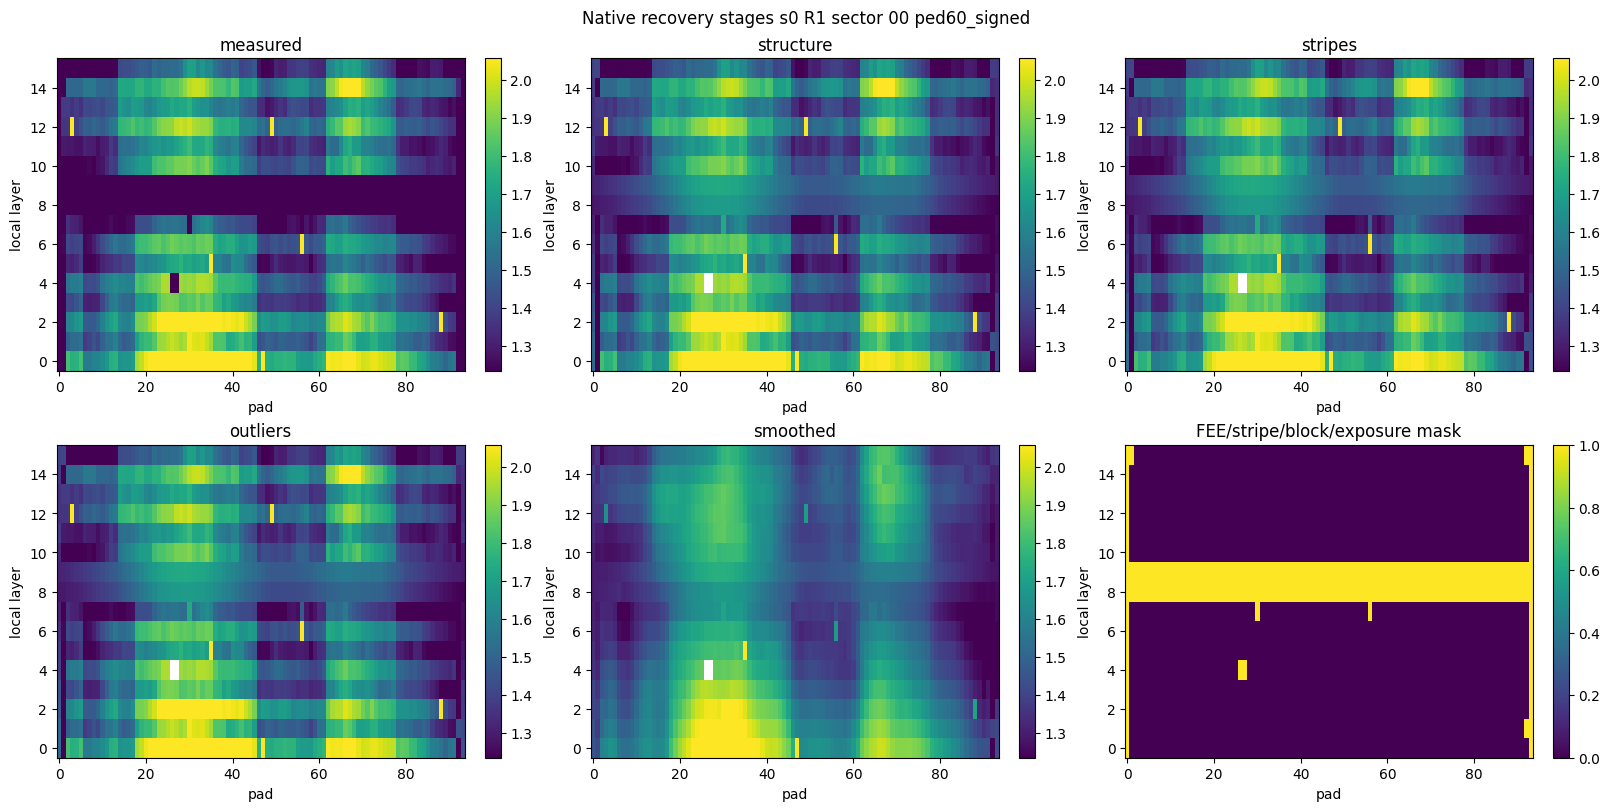

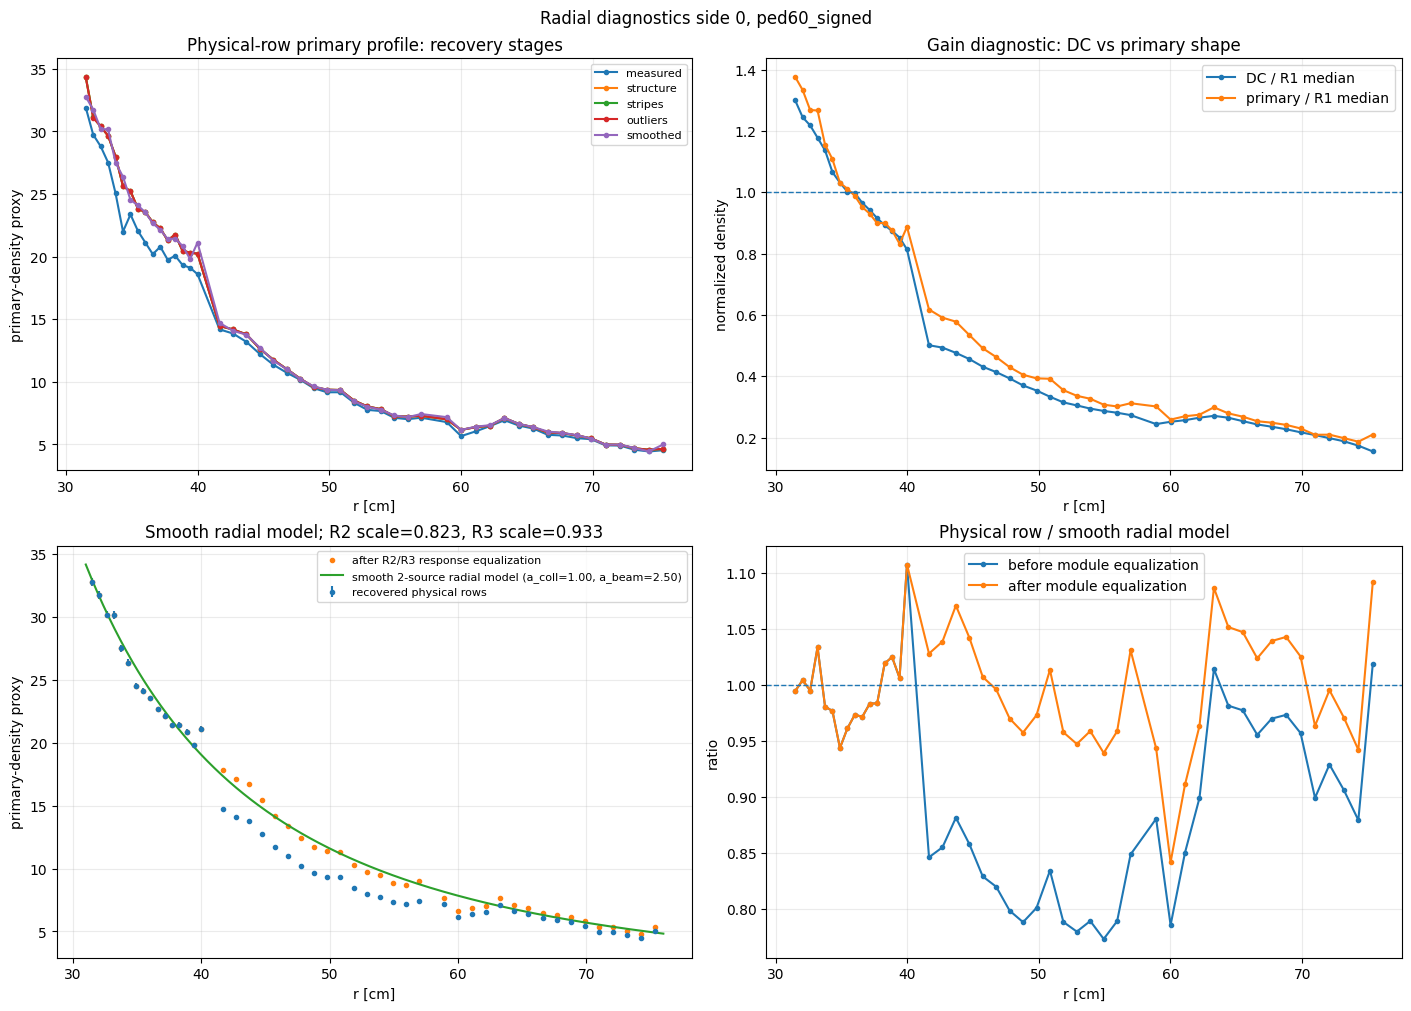

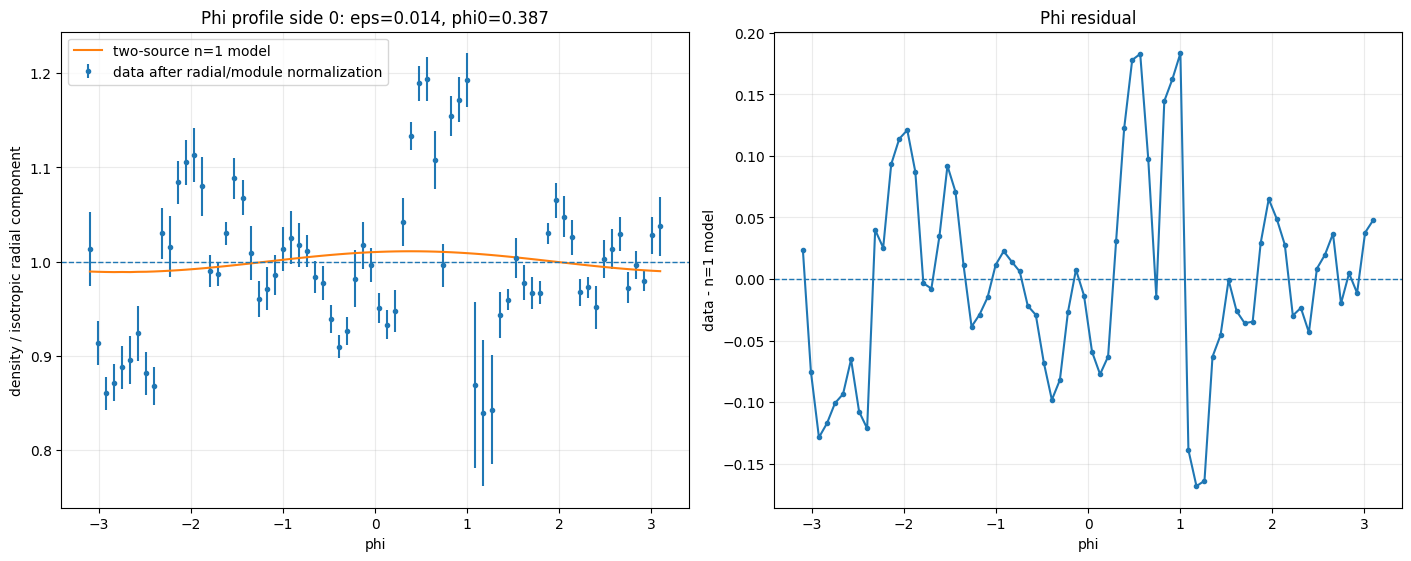

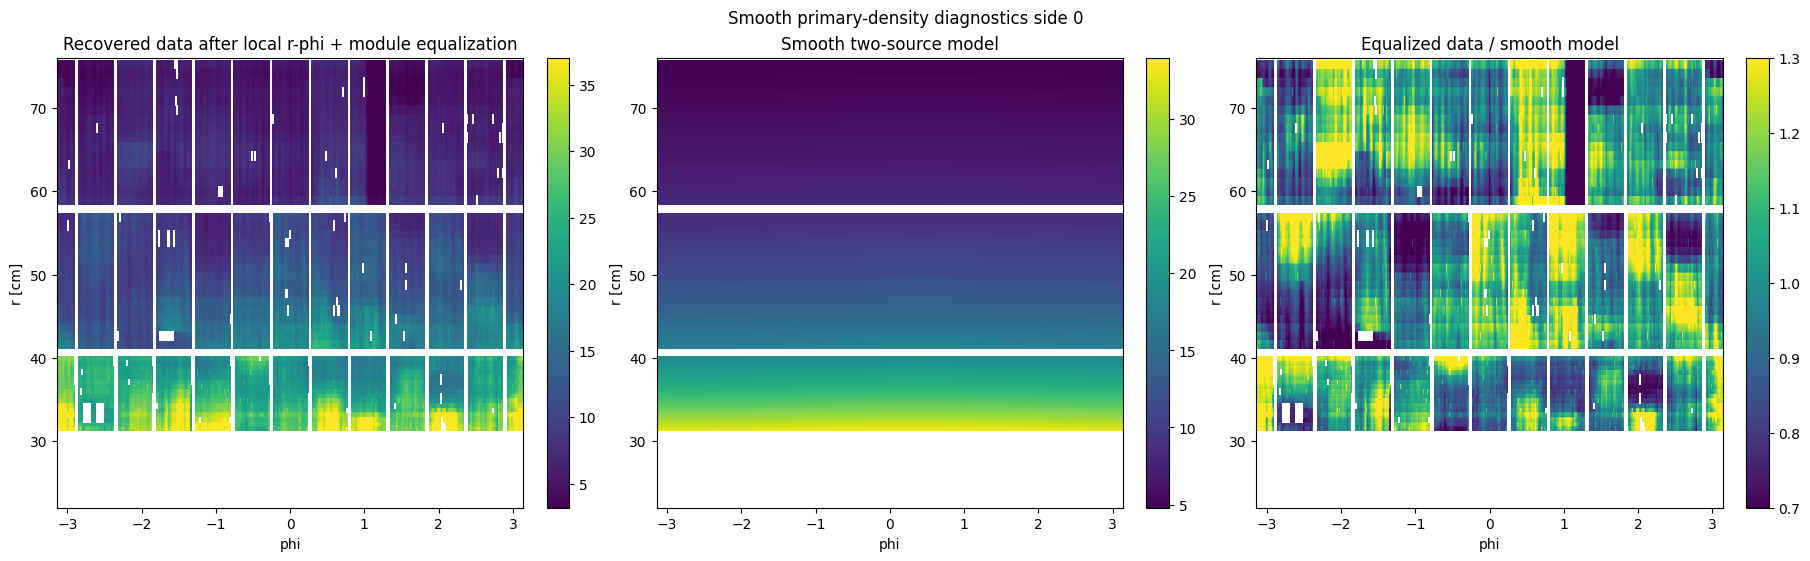

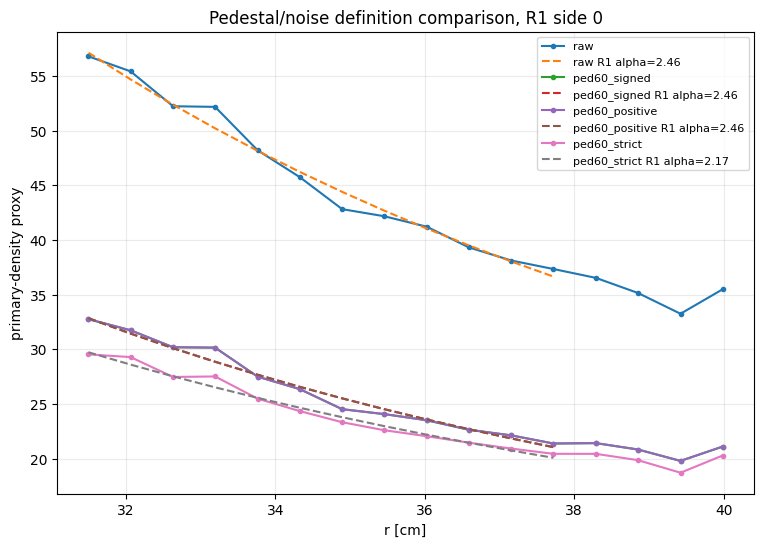

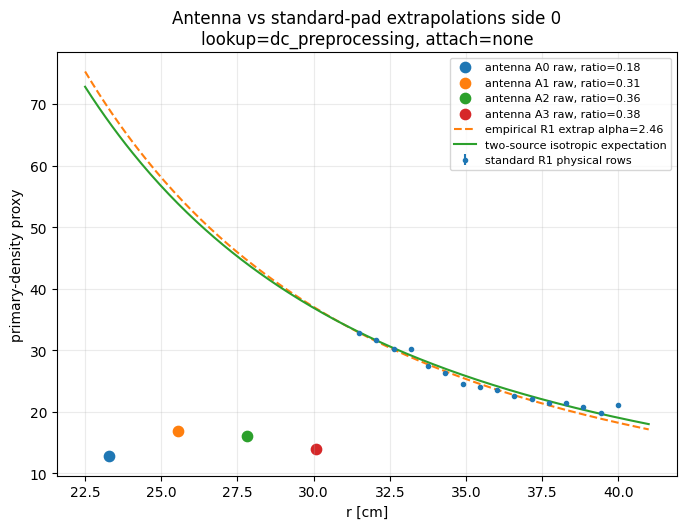

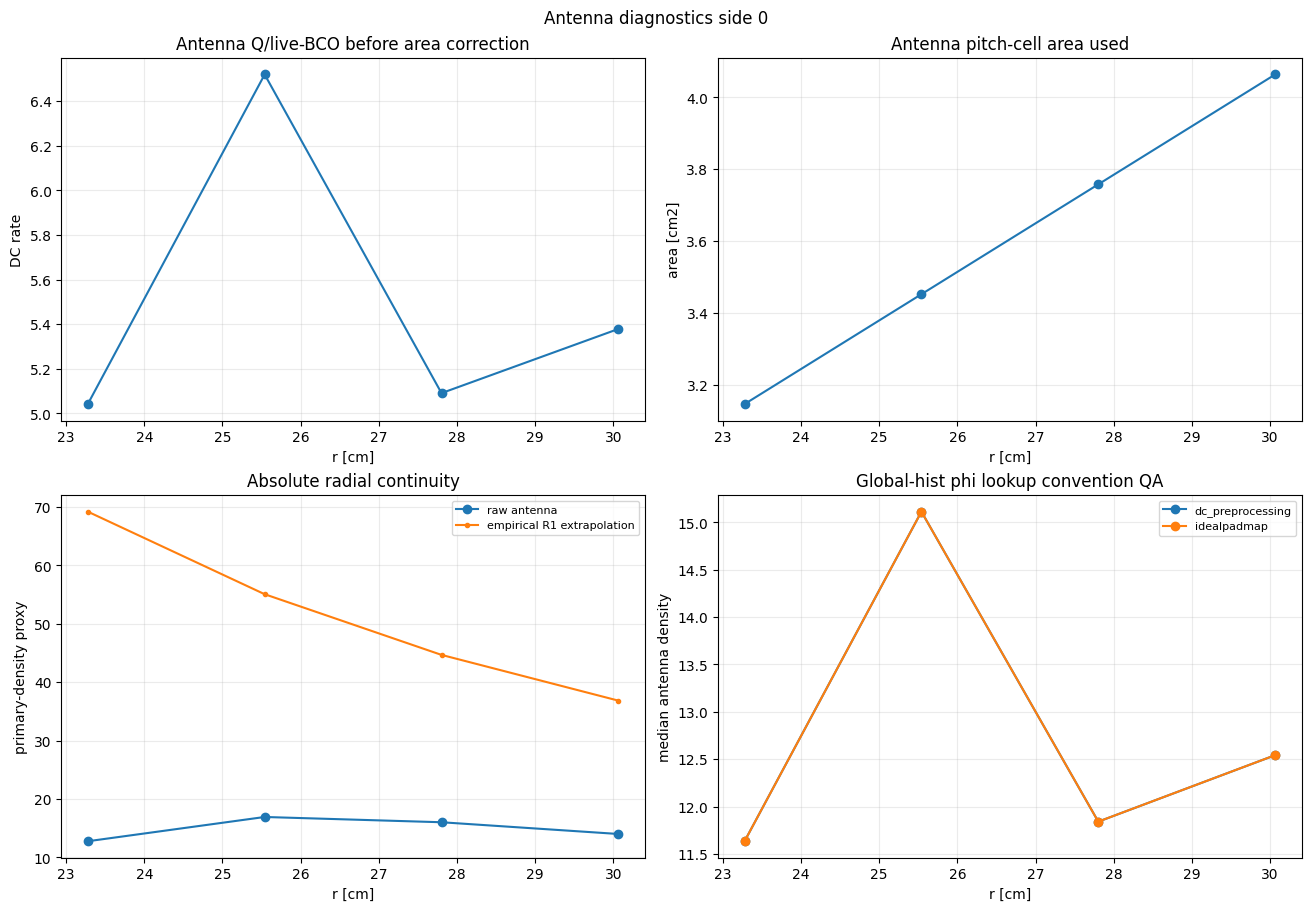

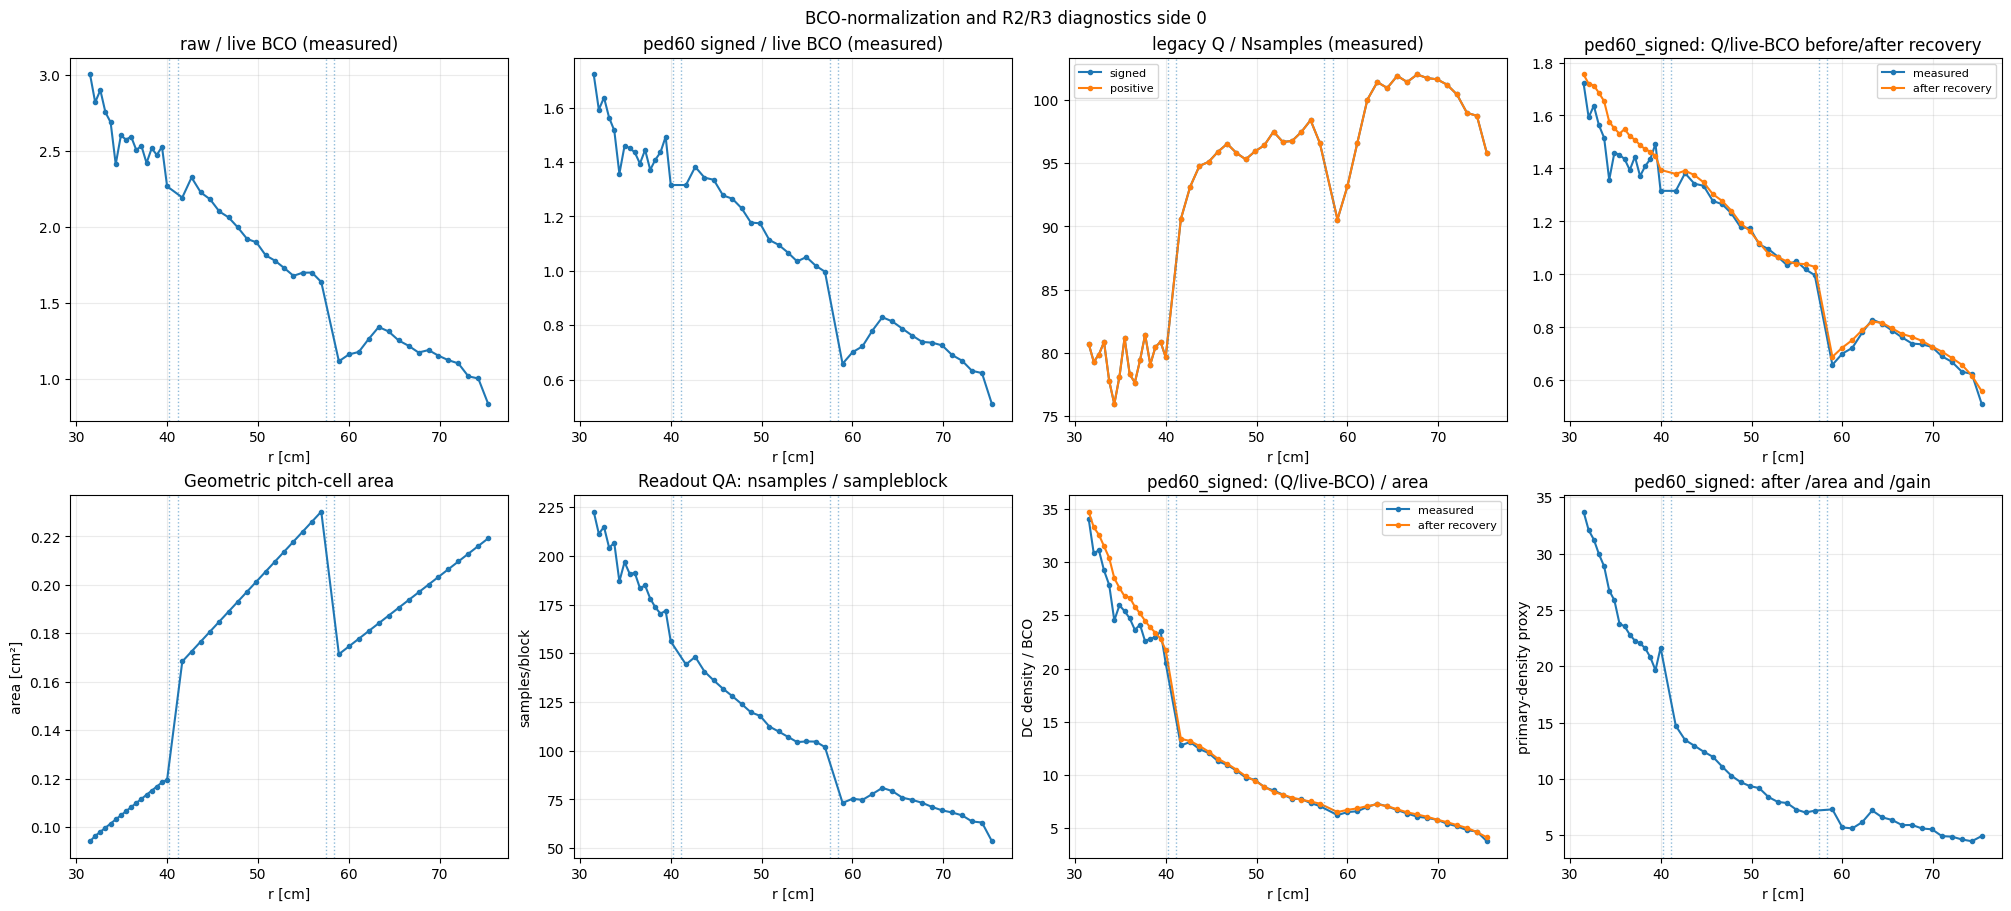

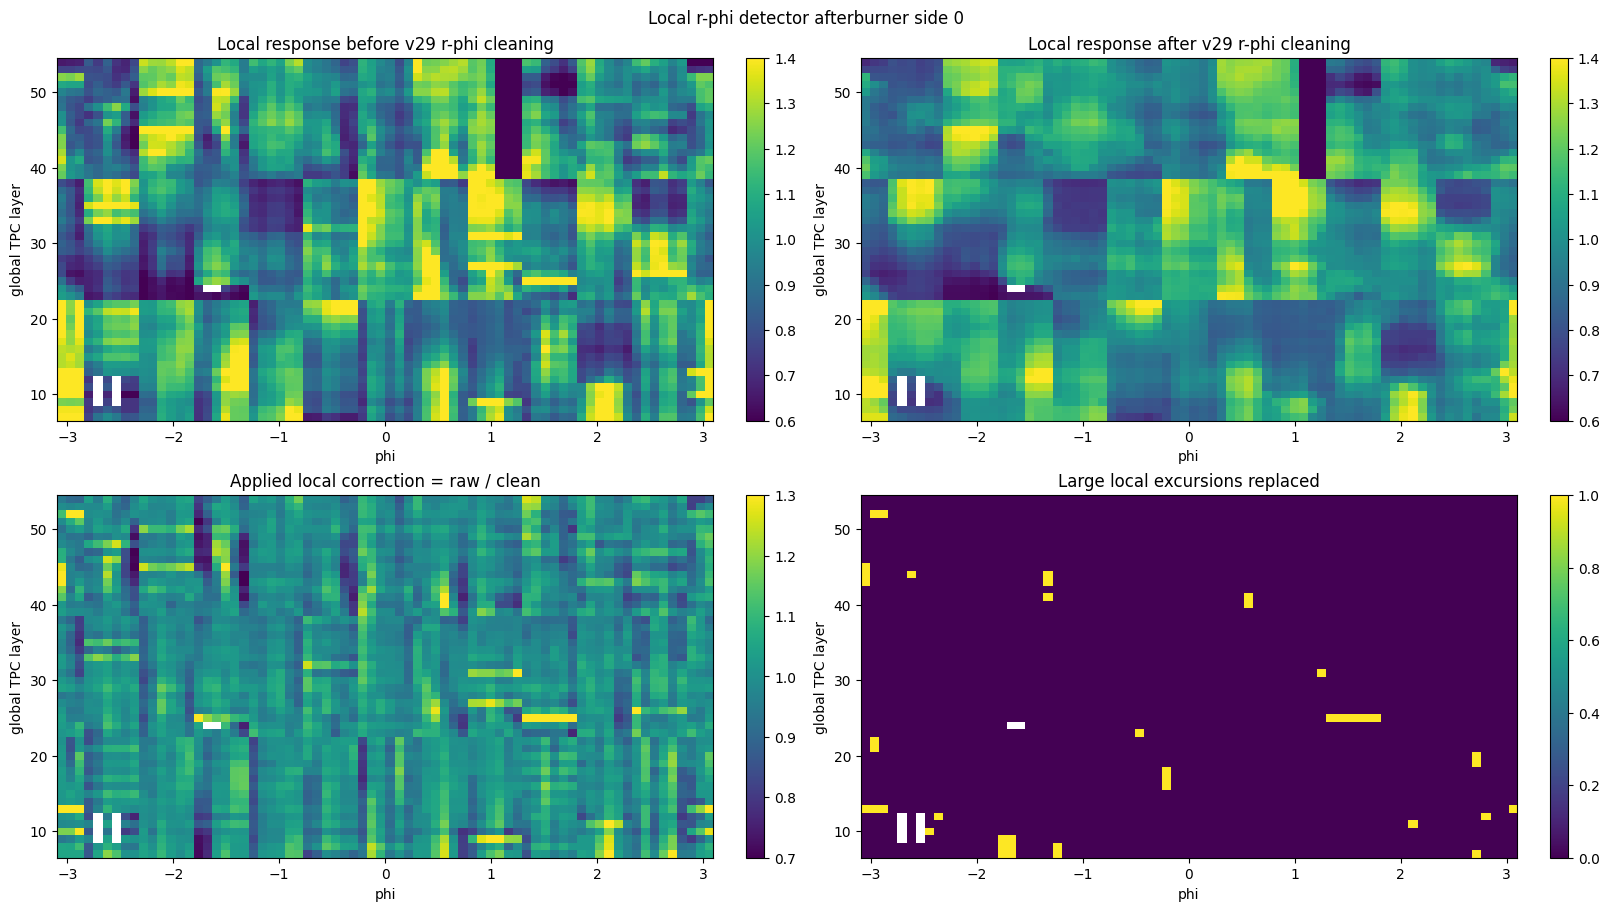

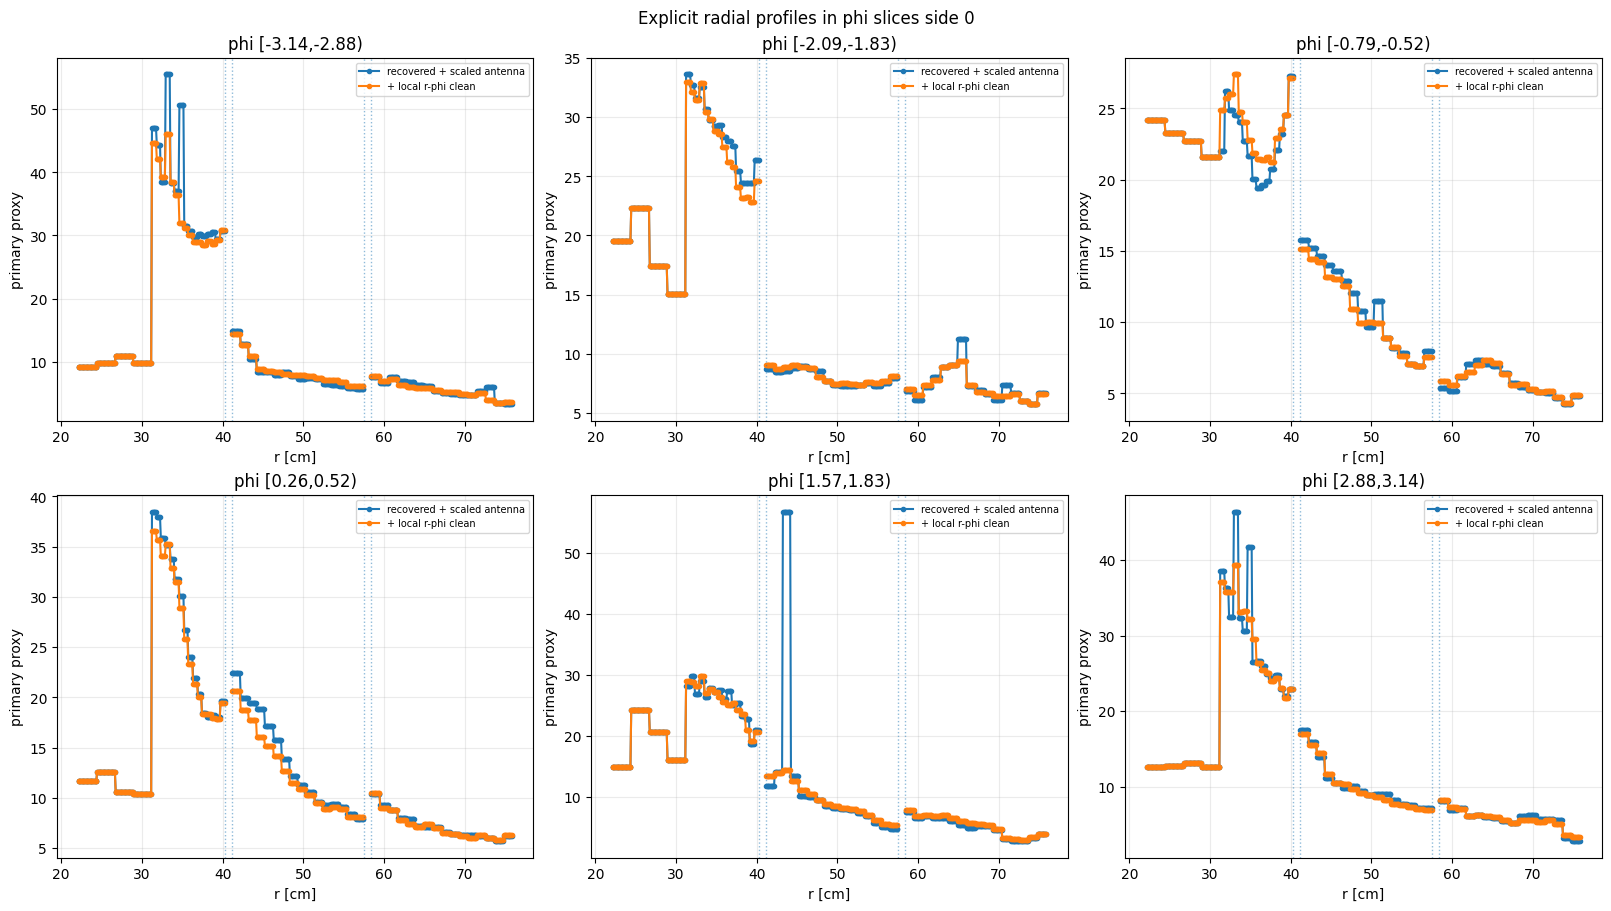

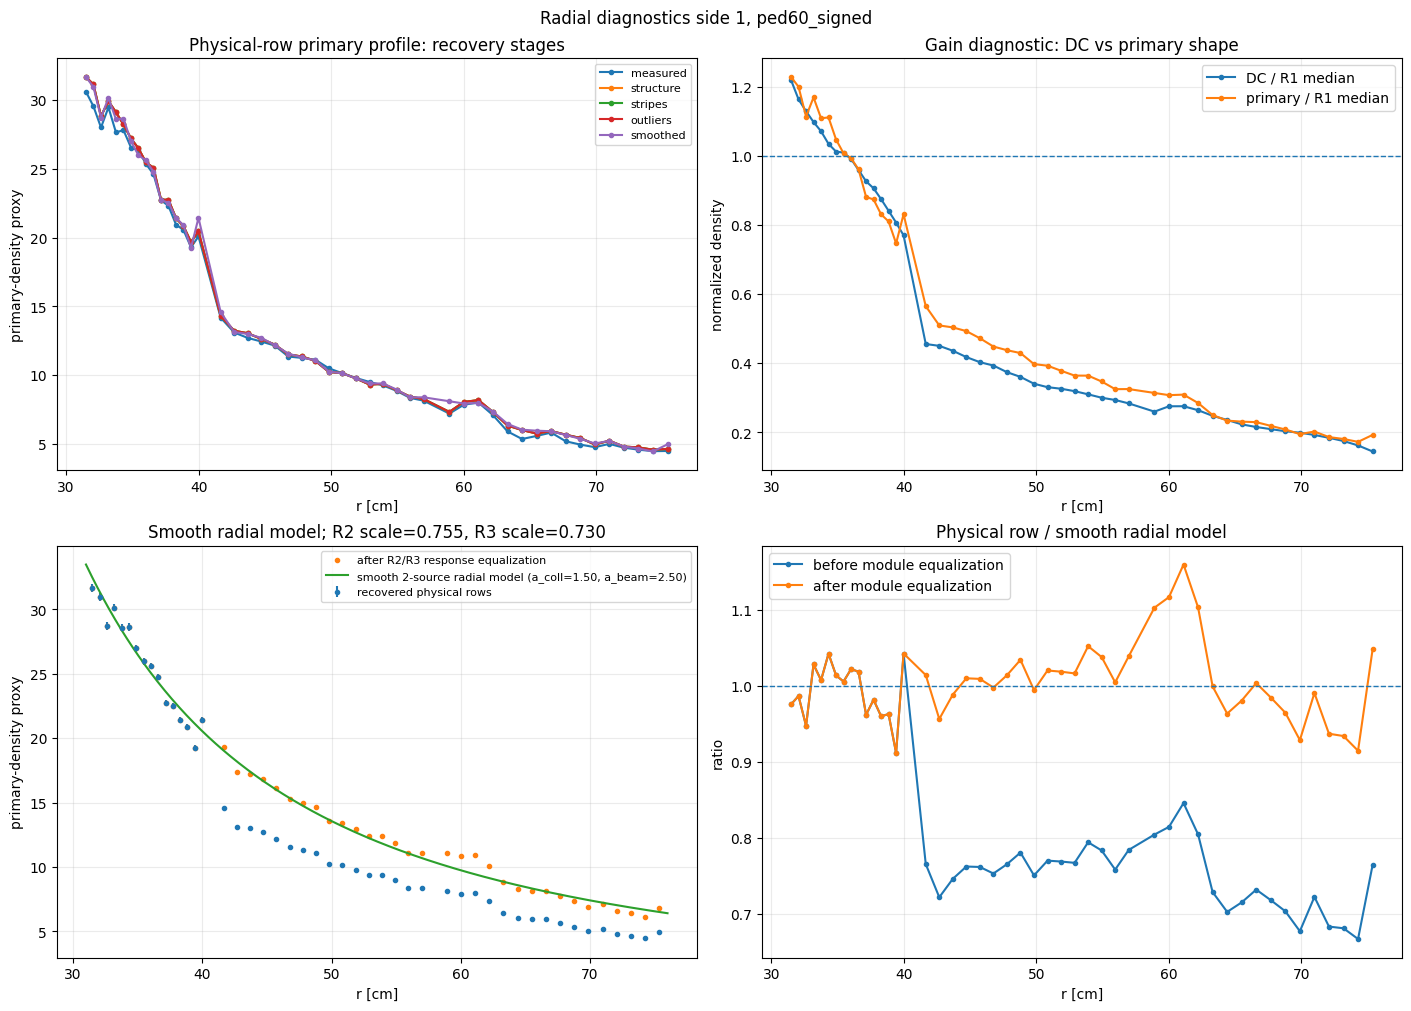

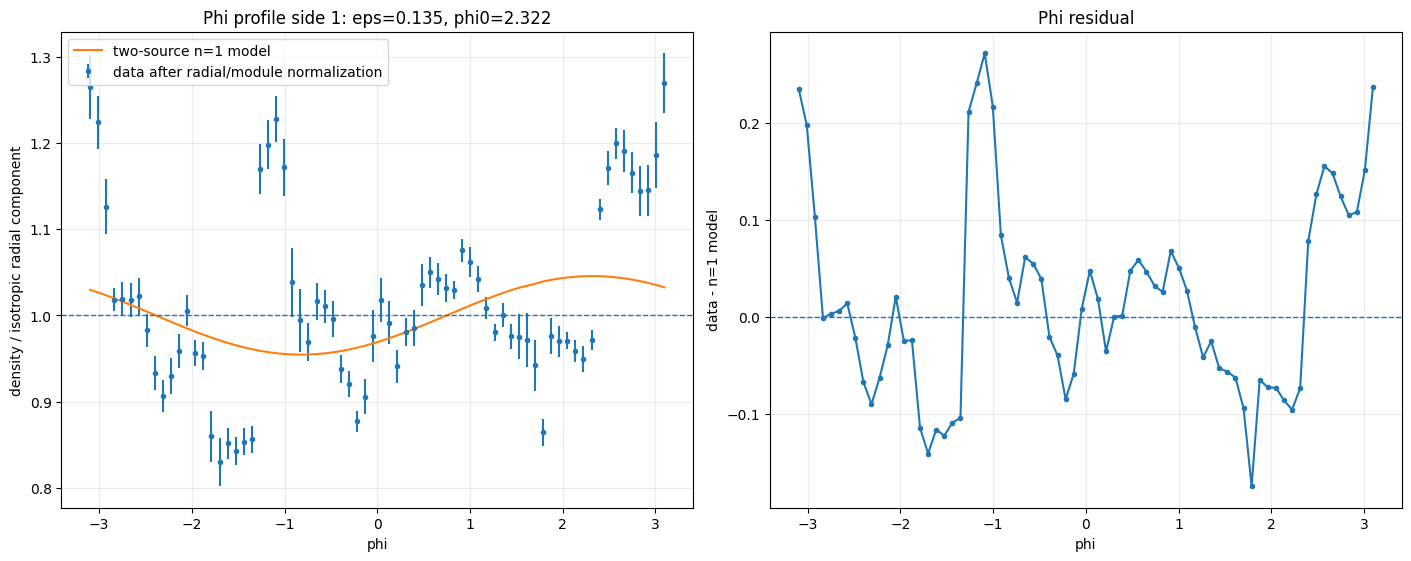

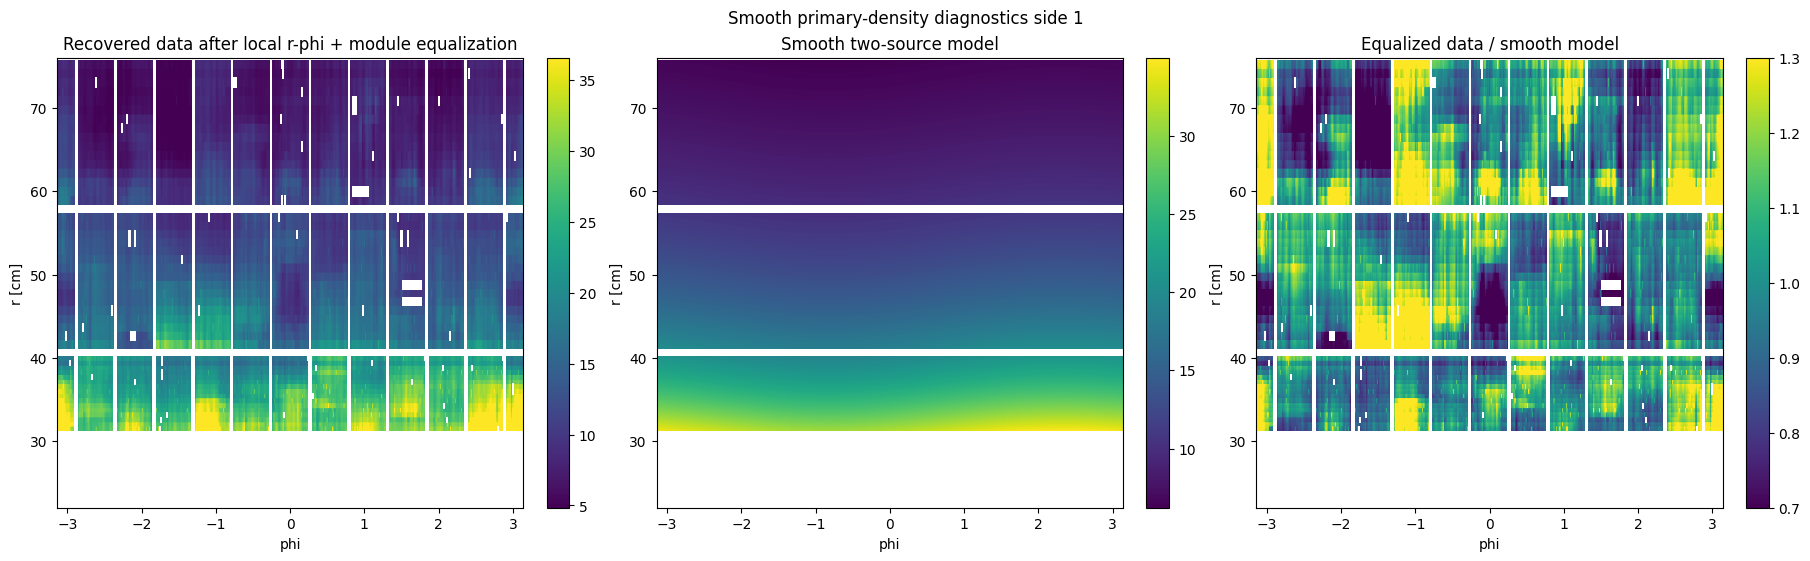

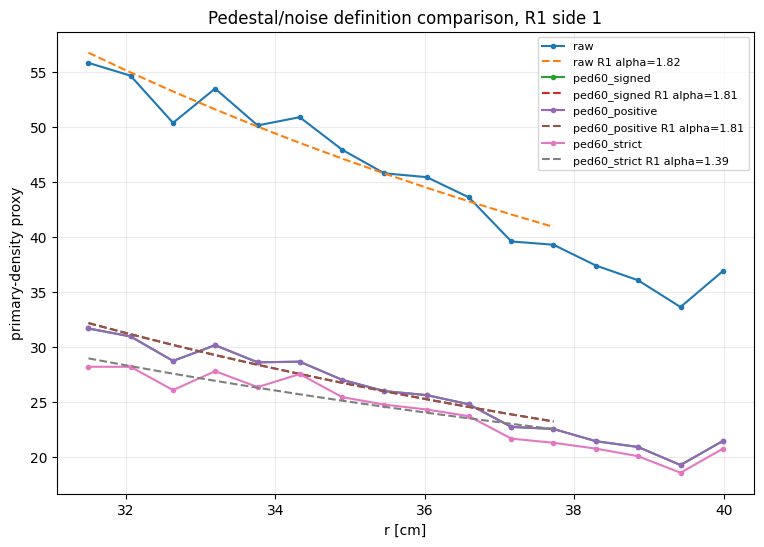

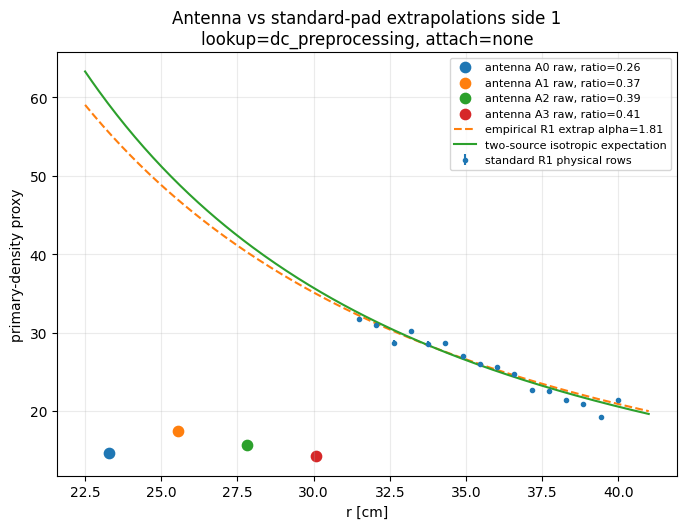

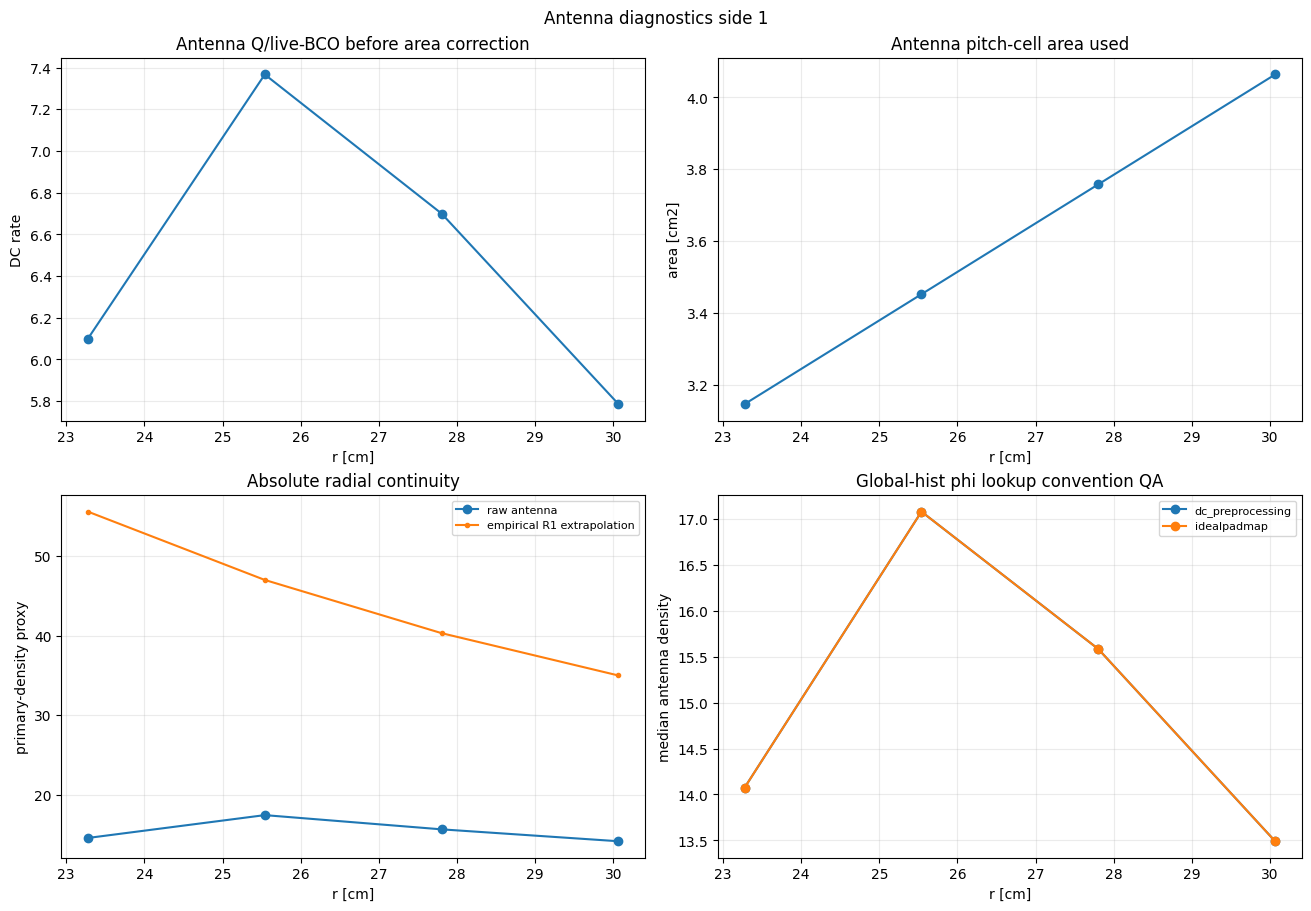

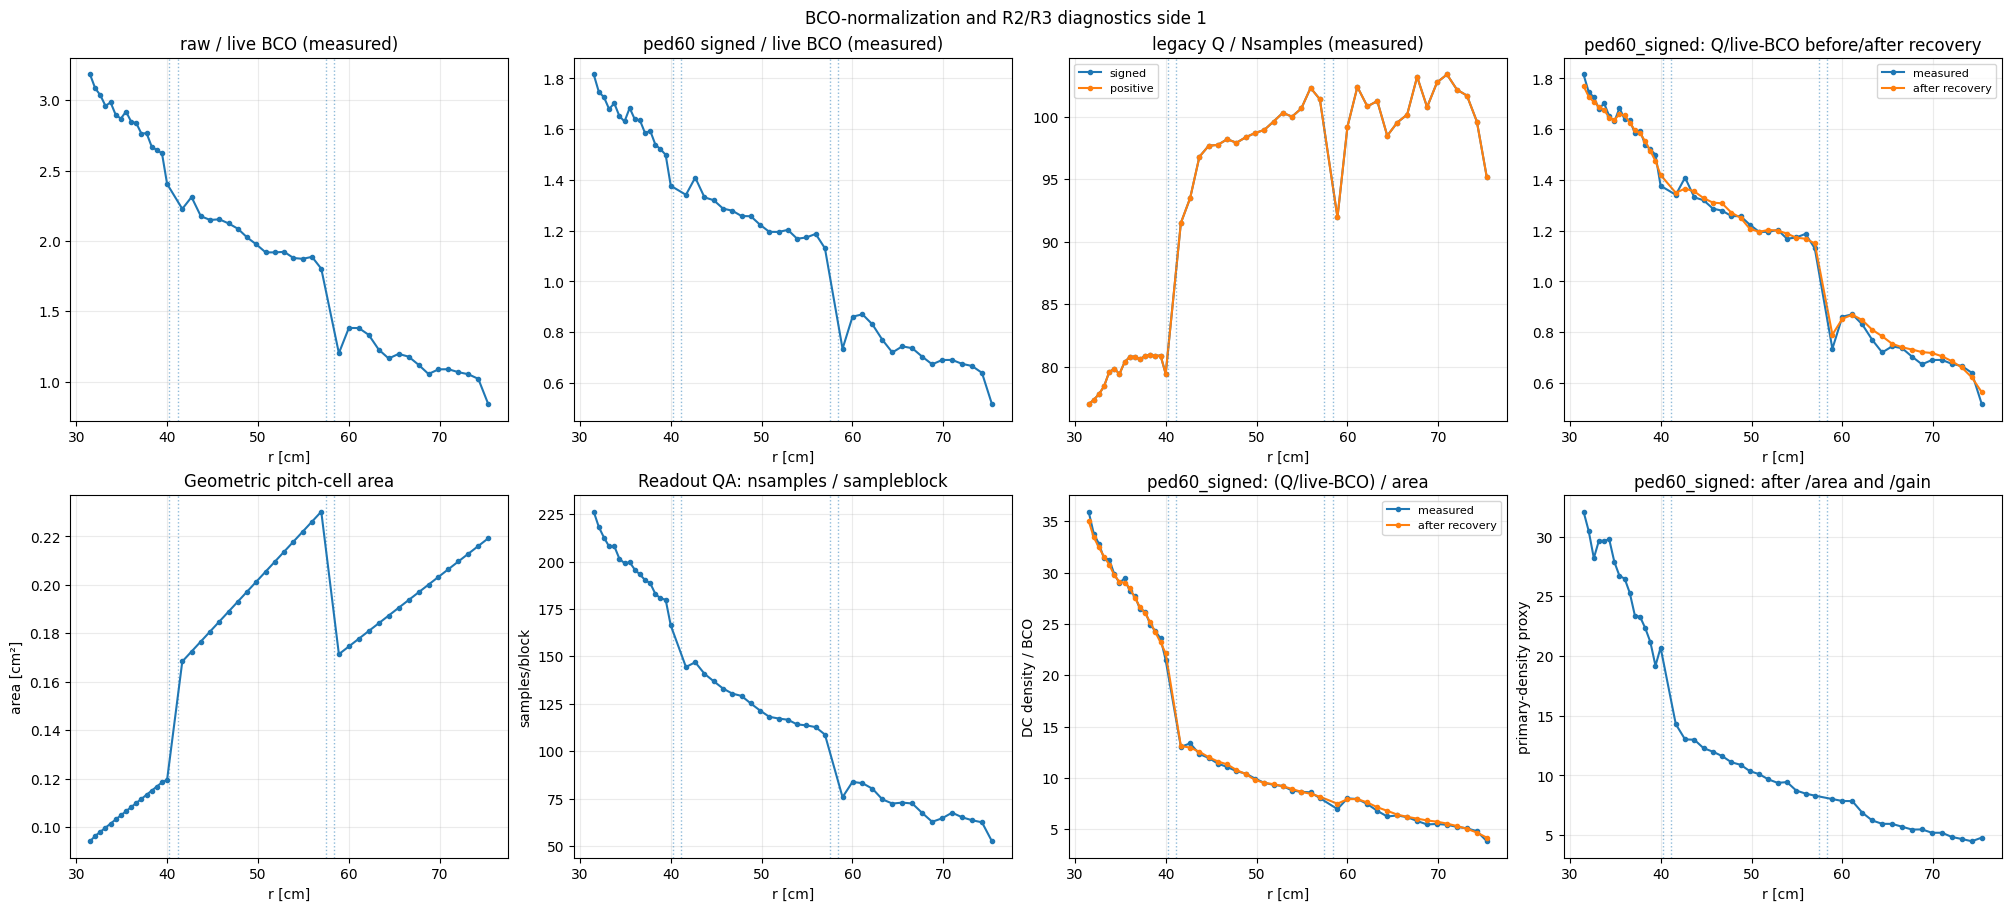

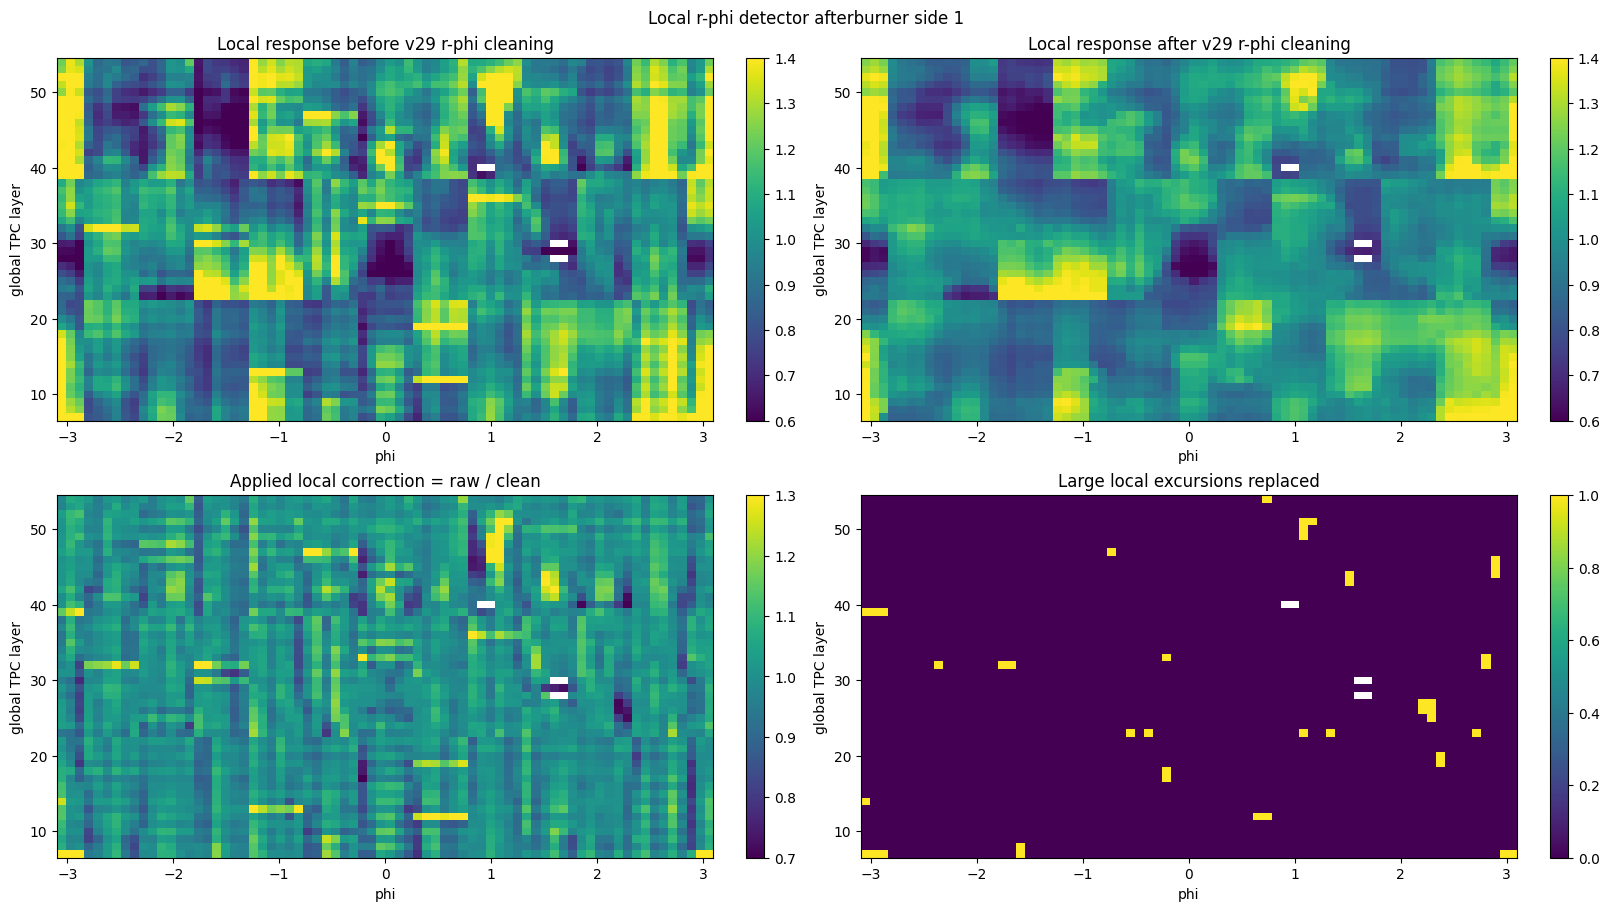

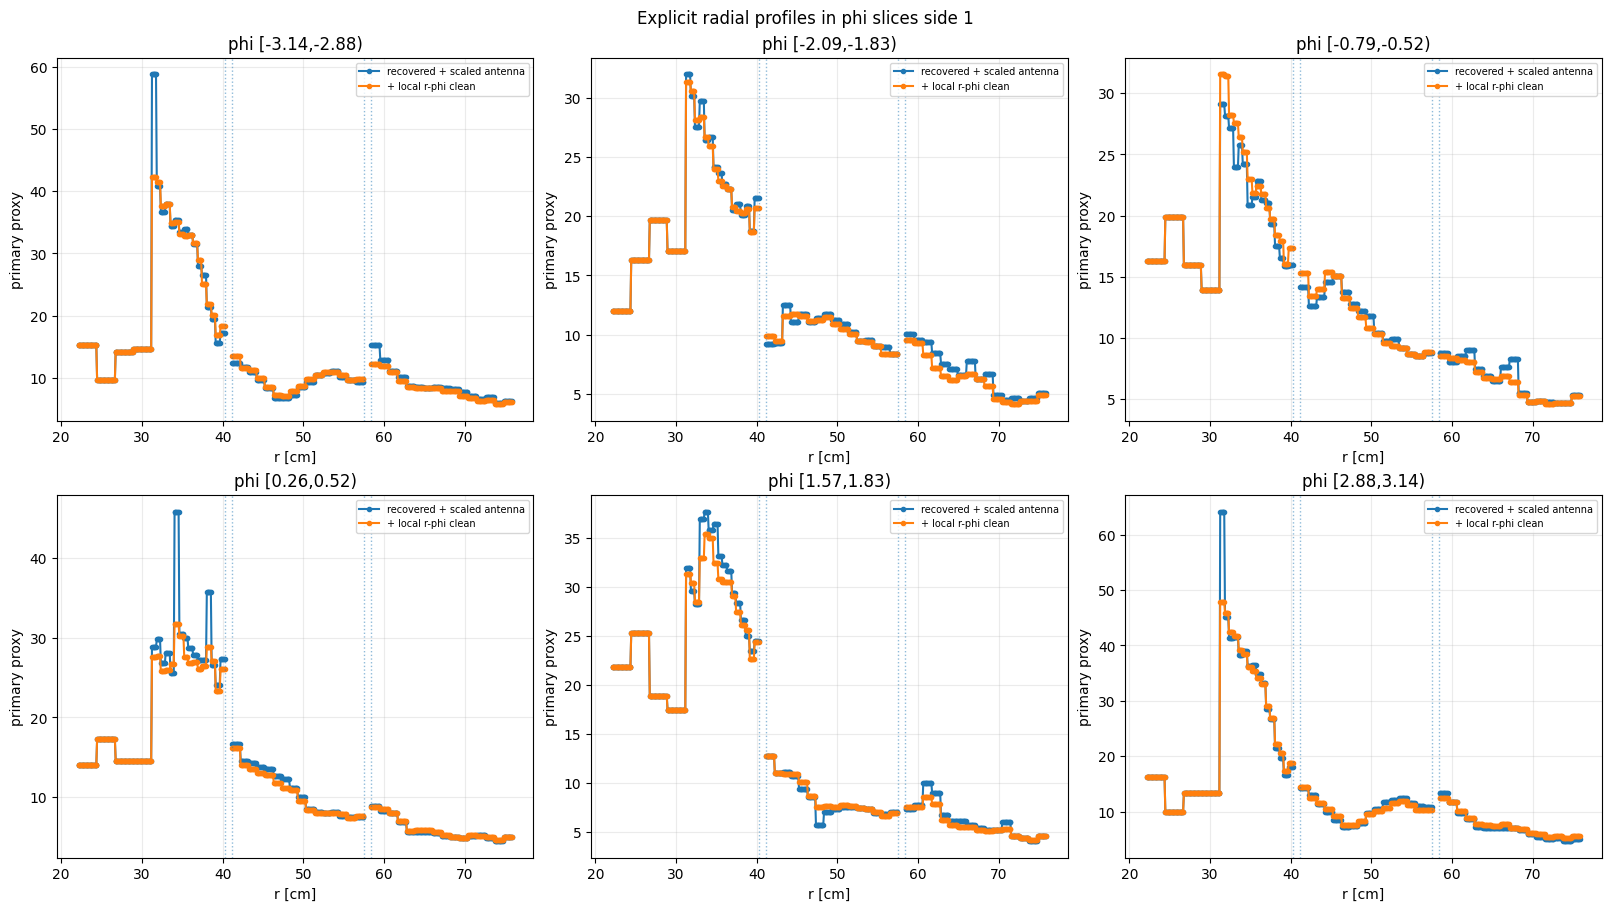

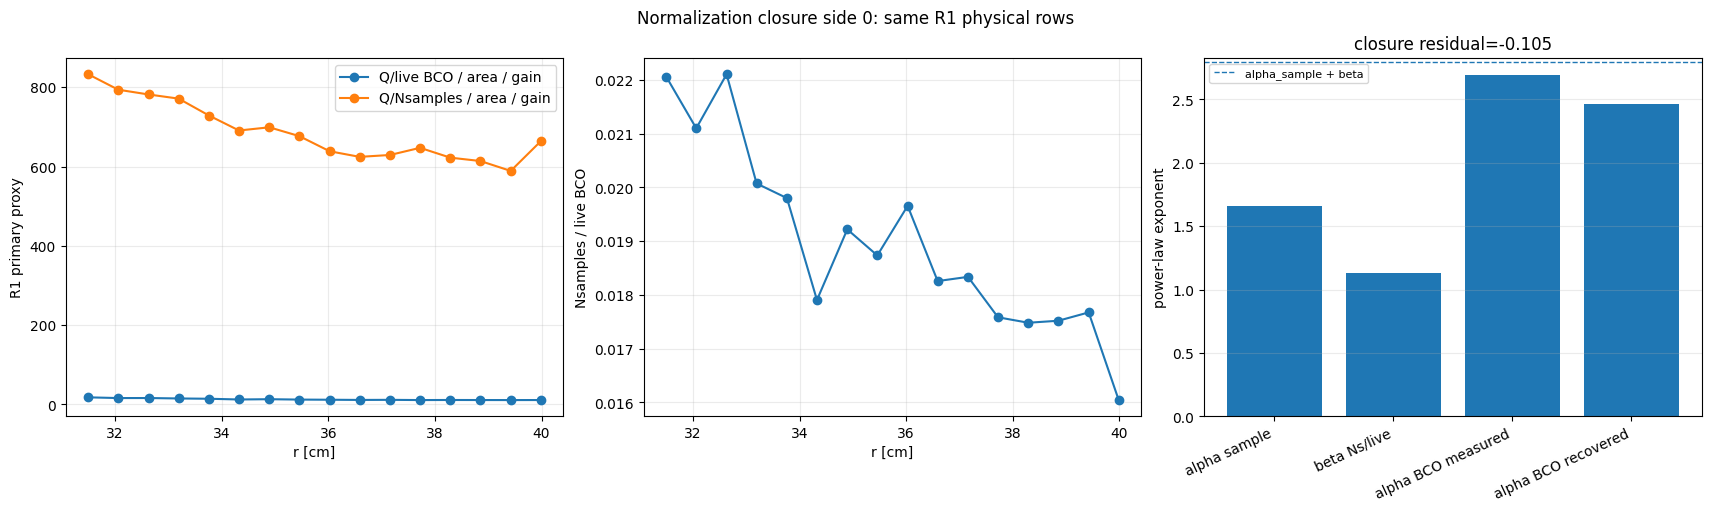

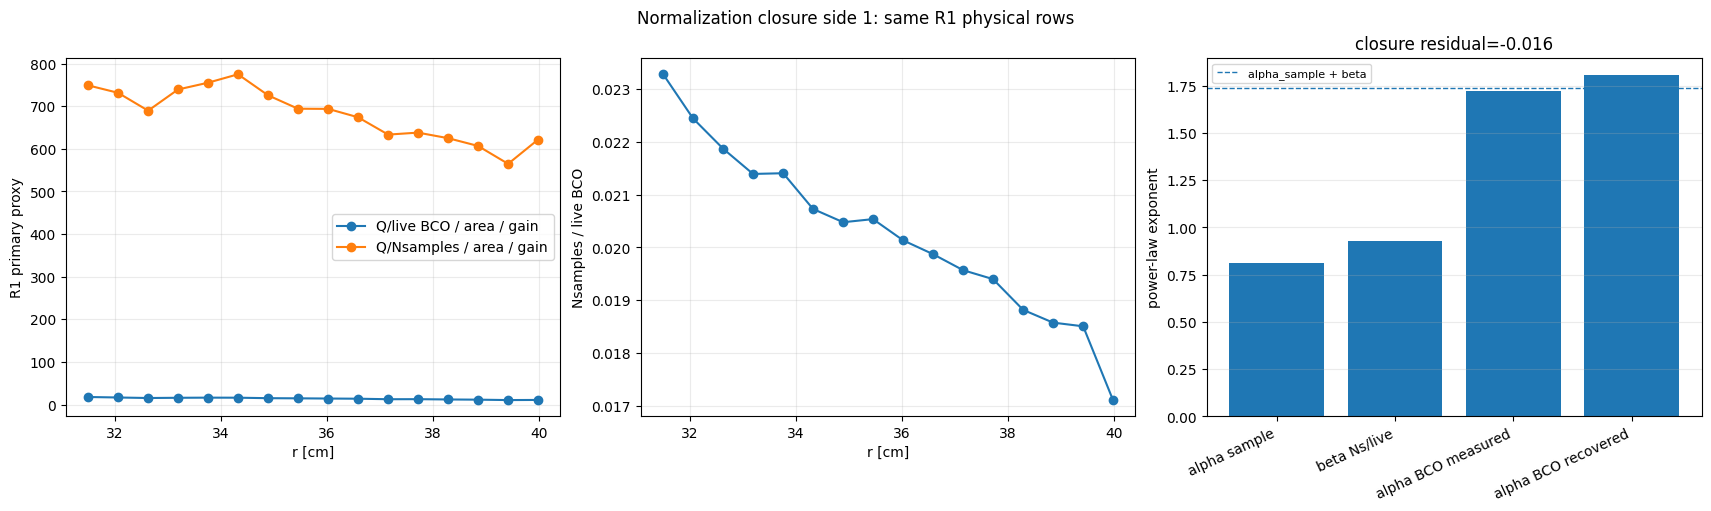

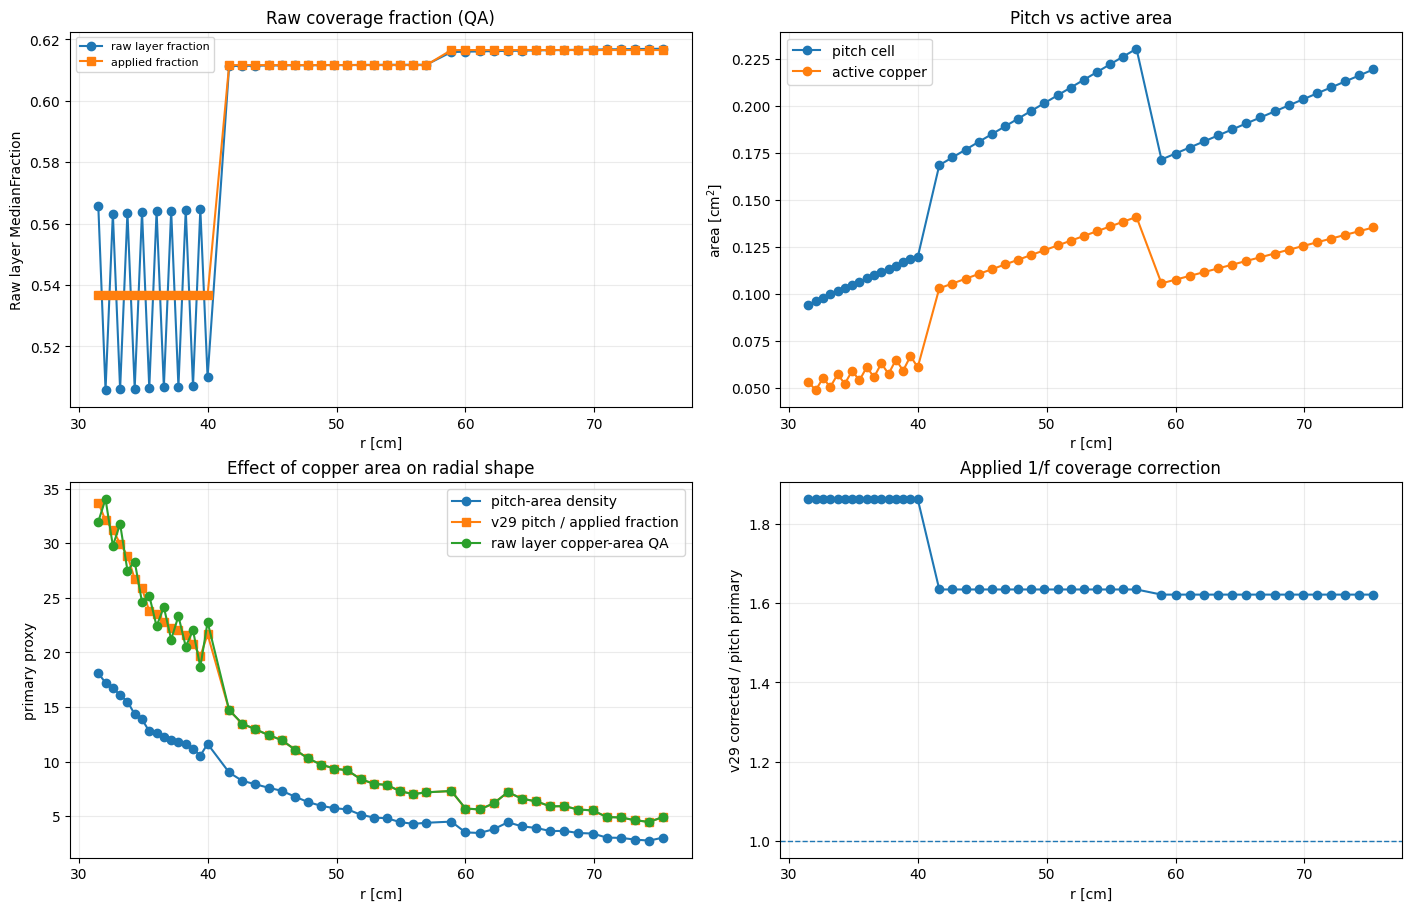

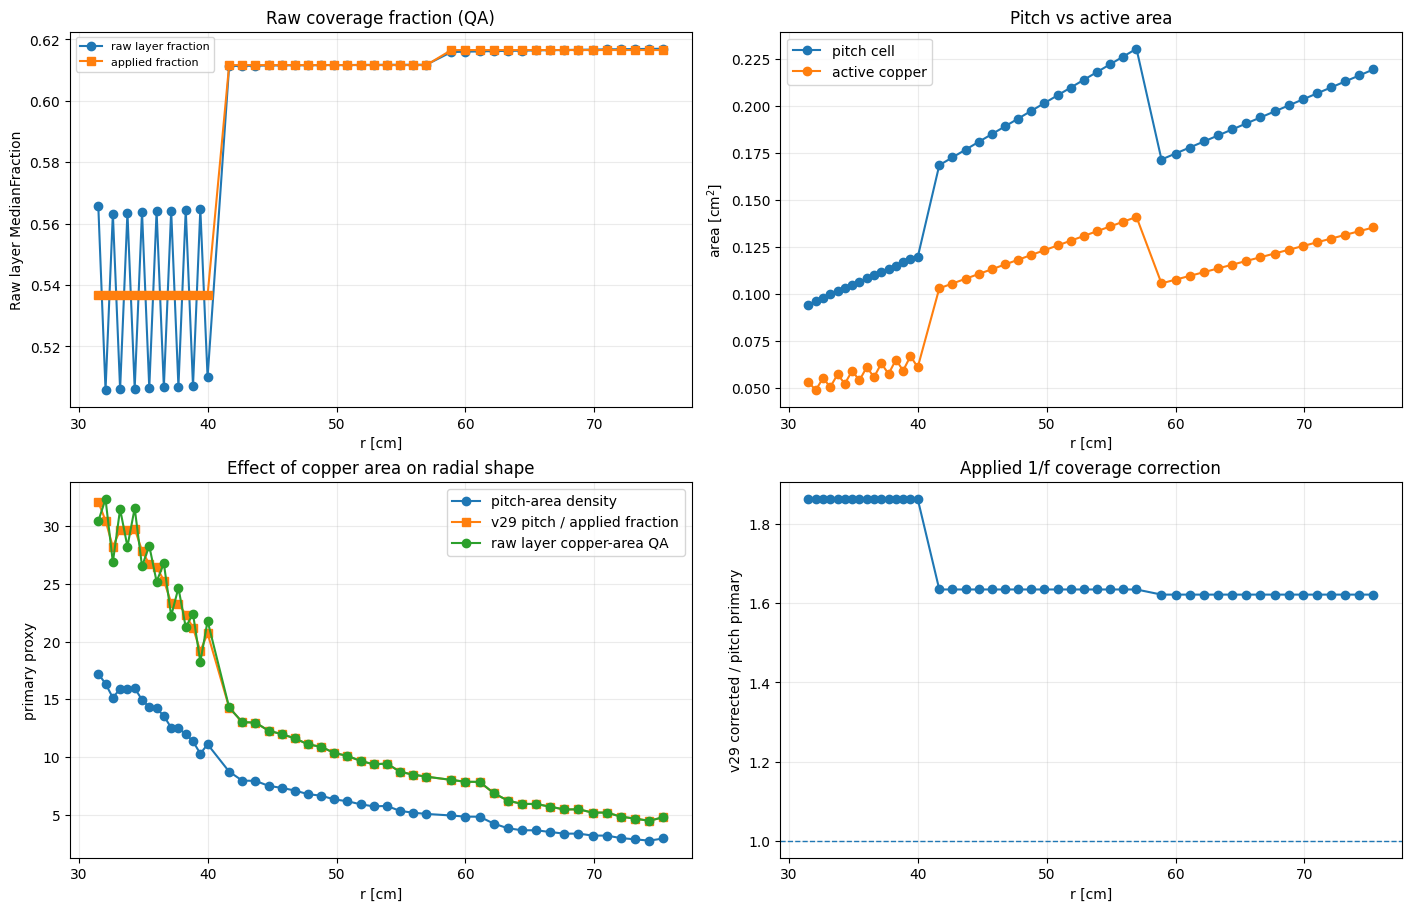

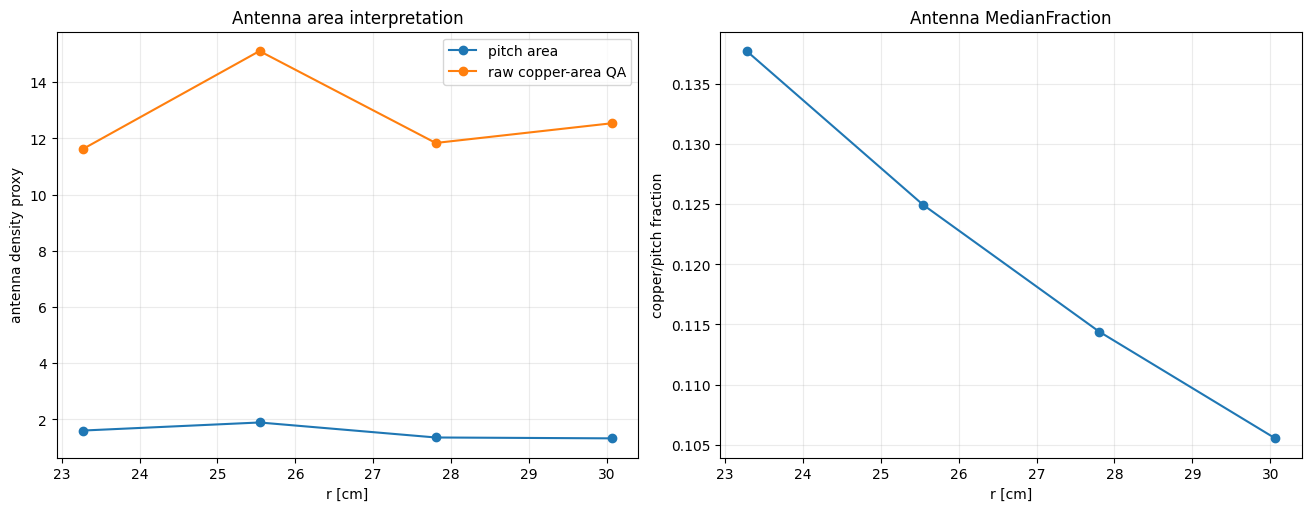

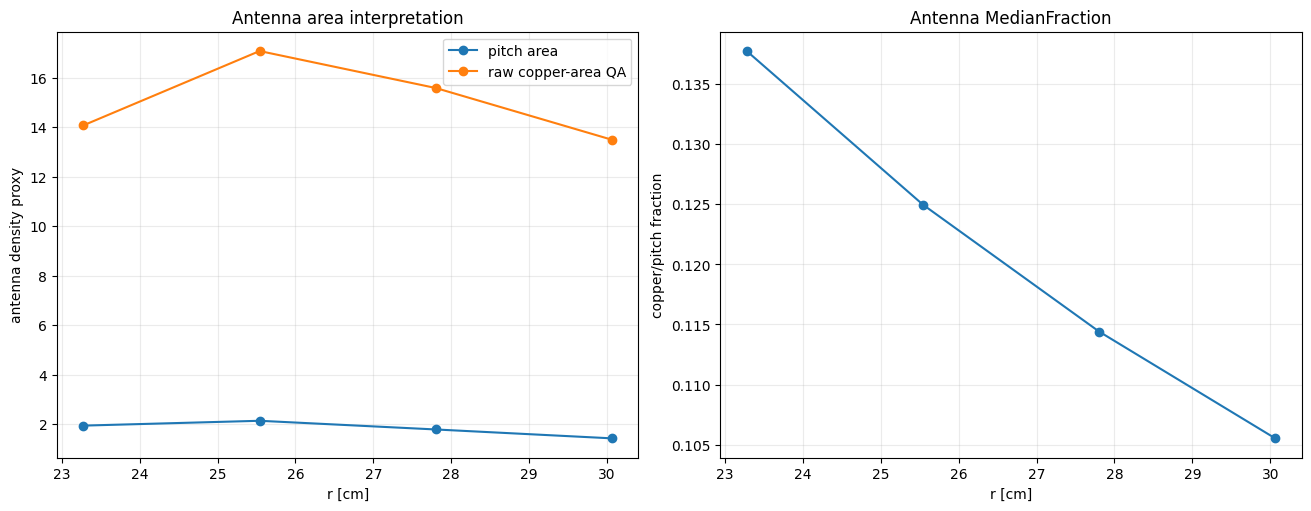

In [12]:

import matplotlib.pyplot as plt

QA_EXAMPLE=(0,0,0)  # side,module,sector

def finite_limits(a,qlo=2,qhi=98):
    v=np.asarray(a,float)
    v=v[np.isfinite(v)]
    if not len(v):
        return None,None
    return tuple(np.percentile(v,[qlo,qhi]))

def plot_native_stages(side,module,sector,variant=MAIN_VARIANT):
    key=(side,module,sector)
    stages=("measured","structure","stripes","outliers","smoothed")
    arrays=[native_stages[variant][s][key] for s in stages]
    m=auto_masks[key]
    mask=(m["fee"]|m["stripe"]|m["block"]|m["low_exposure"]).astype(float)

    lo,hi=finite_limits(arrays[-1])
    fig,ax=plt.subplots(2,3,figsize=(16,8),constrained_layout=True)

    for a,title,axis in zip(arrays,stages,ax.flat[:5]):
        im=axis.imshow(a,aspect="auto",origin="lower",vmin=lo,vmax=hi)
        axis.set_title(title)
        axis.set_xlabel("pad")
        axis.set_ylabel("local layer")
        fig.colorbar(im,ax=axis)

    im=ax.flat[5].imshow(mask,aspect="auto",origin="lower",vmin=0,vmax=1)
    ax.flat[5].set_title("FEE/stripe/block/exposure mask")
    ax.flat[5].set_xlabel("pad")
    ax.flat[5].set_ylabel("local layer")
    fig.colorbar(im,ax=ax.flat[5])

    fig.suptitle(
        f"Native recovery stages s{side} R{module+1} sector {sector:02d} {variant}"
    )
    path=QA_PLOT_DIR/f"native_stages_s{side}_R{module+1}_sec{sector:02d}_{variant}.png"
    fig.savefig(path,dpi=150)
    print("saved",path)
    print(" fee regions:",m["fee_regions"])
    print(" stripe details:",m["stripe_details"])
    print(" block details:",m["block_details"])
    return fig

def plot_radial_diagnostics(side,variant=MAIN_VARIANT):
    fig,ax=plt.subplots(2,2,figsize=(14,10),constrained_layout=True)

    # 1) Every recovery stage, physical primary rows.
    for stage in ("measured","structure","stripes","outliers","smoothed"):
        d=stage_layer_profile_df[
            (stage_layer_profile_df["side"]==side)&
            (stage_layer_profile_df["stage"]==stage)
        ]
        ax[0,0].plot(d["r_cm"],d["primary_density"],".-",label=stage)
    ax[0,0].set_title("Physical-row primary profile: recovery stages")
    ax[0,0].set_xlabel("r [cm]")
    ax[0,0].set_ylabel("primary-density proxy")
    ax[0,0].legend(fontsize=8)
    ax[0,0].grid(True,alpha=0.25)

    # 2) DC vs primary, normalized to their own R1 medians.
    d=layer_profile_df[
        (layer_profile_df["variant"]==variant)&
        (layer_profile_df["mode"]=="recovered")&
        (layer_profile_df["side"]==side)
    ].copy()
    r1=d["module"]==0
    dc0=np.nanmedian(d.loc[r1,"dc_density"])
    pr0=np.nanmedian(d.loc[r1,"primary_density"])
    if np.isfinite(dc0) and dc0!=0:
        ax[0,1].plot(d["r_cm"],d["dc_density"]/dc0,".-",label="DC / R1 median")
    if np.isfinite(pr0) and pr0!=0:
        ax[0,1].plot(d["r_cm"],d["primary_density"]/pr0,".-",label="primary / R1 median")
    ax[0,1].axhline(1.0,ls="--",lw=1)
    ax[0,1].set_title("Gain diagnostic: DC vs primary shape")
    ax[0,1].set_xlabel("r [cm]")
    ax[0,1].set_ylabel("normalized density")
    ax[0,1].legend()
    ax[0,1].grid(True,alpha=0.25)

    # 3) Recovered primary before/after module equalization plus smooth physics model.
    pdx=physics_layer_df[physics_layer_df["side"]==side].copy()
    fit=physics_models[side]
    rr=np.linspace(PHYSICS_MODEL_RMIN_CM,PHYSICS_MODEL_RMAX_CM,400)
    fc,fb=_physics_components(rr,fit["alpha_collision"],fit["alpha_beam"])
    radial_model=fit["A_collision"]*fc+fit["A_beam"]*fb

    ax[1,0].errorbar(
        pdx["r_cm"],pdx["primary_density"],yerr=pdx["primary_err"],
        fmt=".",label="recovered physical rows"
    )
    ax[1,0].plot(
        pdx["r_cm"],pdx["primary_equalized"],".",
        label="after R2/R3 response equalization"
    )
    ax[1,0].plot(
        rr,radial_model,"-",
        label=(
            f"smooth 2-source radial model "
            f"(a_coll={fit['alpha_collision']:.2f}, a_beam={fit['alpha_beam']:.2f})"
        )
    )
    ax[1,0].set_title(
        f"Smooth radial model; R2 scale={fit['module_scale_R2']:.3f}, "
        f"R3 scale={fit['module_scale_R3']:.3f}"
    )
    ax[1,0].set_xlabel("r [cm]")
    ax[1,0].set_ylabel("primary-density proxy")
    ax[1,0].legend(fontsize=8)
    ax[1,0].grid(True,alpha=0.25)

    # 4) Response ratio before and after module equalization.
    ax[1,1].plot(
        pdx["r_cm"],pdx["ratio_before_equalization"],".-",
        label="before module equalization"
    )
    ax[1,1].plot(
        pdx["r_cm"],pdx["ratio_after_equalization"],".-",
        label="after module equalization"
    )
    ax[1,1].axhline(1.0,ls="--",lw=1)
    ax[1,1].set_title("Physical row / smooth radial model")
    ax[1,1].set_xlabel("r [cm]")
    ax[1,1].set_ylabel("ratio")
    ax[1,1].legend()
    ax[1,1].grid(True,alpha=0.25)

    fig.suptitle(f"Radial diagnostics side {side}, {variant}")
    path=QA_PLOT_DIR/f"radial_diagnostics_side{side}_{variant}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

def plot_phi_diagnostics(side):
    d=phi_profile_df[phi_profile_df["side"]==side].sort_values("phi")
    fit=physics_models[side]

    fig,ax=plt.subplots(1,2,figsize=(14,5.5),constrained_layout=True)

    ax[0].errorbar(
        d["phi"],d["ratio_data"],yerr=d["ratio_err"],
        fmt=".",label="data after radial/module normalization"
    )
    ax[0].plot(d["phi"],d["ratio_model"],"-",label="two-source n=1 model")
    ax[0].axhline(1.0,ls="--",lw=1)
    ax[0].set_xlabel("phi")
    ax[0].set_ylabel("density / isotropic radial component")
    ax[0].set_title(
        f"Phi profile side {side}: eps={fit['beam_epsilon']:.3f}, "
        f"phi0={fit['beam_phi0']:.3f}"
    )
    ax[0].legend()
    ax[0].grid(True,alpha=0.25)

    # Residual from n=1 description.
    residual=d["ratio_data"]-d["ratio_model"]
    ax[1].plot(d["phi"],residual,".-")
    ax[1].axhline(0.0,ls="--",lw=1)
    ax[1].set_xlabel("phi")
    ax[1].set_ylabel("data - n=1 model")
    ax[1].set_title("Phi residual")
    ax[1].grid(True,alpha=0.25)

    path=QA_PLOT_DIR/f"phi_diagnostics_side{side}_{MAIN_VARIANT}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

def plot_physics_2d(side):
    p=physics_products[side]
    fig,ax=plt.subplots(1,3,figsize=(18,5.5),constrained_layout=True)

    lo,hi=finite_limits(p["equalized_recovered"])
    im=ax[0].imshow(
        p["equalized_local_phi_cleaned"],origin="lower",aspect="auto",
        extent=[PHI_MIN,PHI_MAX,r_edges[0],r_edges[-1]],
        vmin=lo,vmax=hi
    )
    ax[0].set_title("Recovered data after local r-phi + module equalization")
    ax[0].set_xlabel("phi"); ax[0].set_ylabel("r [cm]")
    fig.colorbar(im,ax=ax[0])

    im=ax[1].imshow(
        p["smooth_model_standard"],origin="lower",aspect="auto",
        extent=[PHI_MIN,PHI_MAX,r_edges[0],r_edges[-1]]
    )
    ax[1].set_title("Smooth two-source model")
    ax[1].set_xlabel("phi"); ax[1].set_ylabel("r [cm]")
    fig.colorbar(im,ax=ax[1])

    im=ax[2].imshow(
        p["ratio_to_model"],origin="lower",aspect="auto",
        extent=[PHI_MIN,PHI_MAX,r_edges[0],r_edges[-1]],
        vmin=0.7,vmax=1.3
    )
    ax[2].set_title("Equalized data / smooth model")
    ax[2].set_xlabel("phi"); ax[2].set_ylabel("r [cm]")
    fig.colorbar(im,ax=ax[2])

    fig.suptitle(f"Smooth primary-density diagnostics side {side}")
    path=QA_PLOT_DIR/f"physics_model_2d_side{side}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

def plot_variant_r1_comparison(side):
    fig,ax=plt.subplots(figsize=(9,6))
    for variant in PROCESS_VARIANTS:
        d=layer_profile_df[
            (layer_profile_df["variant"]==variant)&
            (layer_profile_df["mode"]=="recovered")&
            (layer_profile_df["side"]==side)&
            (layer_profile_df["module"]==0)
        ].sort_values("local_layer")
        fit=layer_fit_cache[(variant,"recovered","primary",side)]
        ax.plot(d["r_cm"],d["primary_density"],".-",label=f"{variant}")
        if np.isfinite(fit["alpha"]):
            ax.plot(
                fit["r"],fit["fit"],"--",
                label=f"{variant} R1 alpha={fit['alpha']:.2f}"
            )
    ax.set_xlabel("r [cm]")
    ax.set_ylabel("primary-density proxy")
    ax.set_title(f"Pedestal/noise definition comparison, R1 side {side}")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8)
    path=QA_PLOT_DIR/f"variant_r1_comparison_side{side}.png"
    fig.savefig(path,dpi=160,bbox_inches="tight")
    print("saved",path)
    return fig

def plot_antenna_extrapolation(side):
    fit,_=standard_r1_prediction(side)
    fig,ax=plt.subplots(figsize=(8,5.5))

    d=layer_profile_df[
        (layer_profile_df["variant"]==MAIN_VARIANT)&
        (layer_profile_df["mode"]=="recovered")&
        (layer_profile_df["side"]==side)&
        (layer_profile_df["module"]==0)
    ].sort_values("local_layer")

    ax.errorbar(
        d["r_cm"],d["primary_density"],yerr=d["primary_err"],
        fmt=".",label="standard R1 physical rows"
    )

    for ring,(rval,med,expected,ratio) in enumerate(antenna_ring_summary[side]):
        ax.scatter([rval],[med],s=55,label=f"antenna A{ring} raw, ratio={ratio:.2f}")
        attached=antenna_ratio_df[
            (antenna_ratio_df["side"]==side)&(antenna_ratio_df["ring"]==ring)
        ]
        if len(attached) and ANTENNA_ATTACH_MODE!="none":
            av=float(attached.iloc[0]["antenna_density_attached"])
            ar=float(attached.iloc[0]["attached_over_r1_extrap"])
            ax.scatter([rval],[av],marker="x",s=65,
                       label=f"A{ring} attached, ratio={ar:.2f}")

    xr=np.linspace(22.5,41,250)
    if np.isfinite(fit["alpha"]):
        yr=fit["rho_ref"]*(fit["r_ref"]/xr)**fit["alpha"]
        ax.plot(xr,yr,"--",label=f"empirical R1 extrap alpha={fit['alpha']:.2f}")

    # Also show the smooth two-source physical extrapolation, but do not use
    # antenna points to constrain it.
    f=physics_models[side]
    fc,fb=_physics_components(xr,f["alpha_collision"],f["alpha_beam"])
    yphys=f["A_collision"]*fc+f["A_beam"]*fb
    ax.plot(xr,yphys,"-",label="two-source isotropic expectation")

    ax.set_xlabel("r [cm]")
    ax.set_ylabel("primary-density proxy")
    ax.set_title(f"Antenna vs standard-pad extrapolations side {side}\nlookup={ANTENNA_GLOBAL_LOOKUP_MODE}, attach={ANTENNA_ATTACH_MODE}")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8)
    path=QA_PLOT_DIR/f"antenna_vs_r1_side{side}.png"
    fig.savefig(path,dpi=150,bbox_inches="tight")
    print("saved",path)
    return fig

def plot_antenna_diagnostics(side):
    d=antenna_ratio_df[antenna_ratio_df["side"]==side].sort_values("ring")
    q=antenna_lookup_qa_df[antenna_lookup_qa_df["side"]==side] if len(antenna_lookup_qa_df) else pd.DataFrame()
    fig,ax=plt.subplots(2,2,figsize=(13,9),constrained_layout=True)

    ax[0,0].plot(d["r_cm"],d["antenna_rate"],"o-")
    ax[0,0].set_title("Antenna Q/live-BCO before area correction")
    ax[0,0].set_xlabel("r [cm]"); ax[0,0].set_ylabel("DC rate")
    ax[0,0].grid(True,alpha=0.25)

    ax[0,1].plot(d["r_cm"],d["area_cm2"],"o-")
    ax[0,1].set_title("Antenna pitch-cell area used")
    ax[0,1].set_xlabel("r [cm]"); ax[0,1].set_ylabel("area [cm2]")
    ax[0,1].grid(True,alpha=0.25)

    ax[1,0].plot(d["r_cm"],d["antenna_density"],"o-",label="raw antenna")
    if ANTENNA_ATTACH_MODE!="none":
        ax[1,0].plot(d["r_cm"],d["antenna_density_attached"],"x--",label="attached antenna")
    ax[1,0].plot(d["r_cm"],d["r1_extrapolated"],".-",label="empirical R1 extrapolation")
    ax[1,0].set_title("Absolute radial continuity")
    ax[1,0].set_xlabel("r [cm]"); ax[1,0].set_ylabel("primary-density proxy")
    ax[1,0].legend(fontsize=8); ax[1,0].grid(True,alpha=0.25)

    if len(q):
        for mode in q["lookup_mode"].unique():
            z=q[q["lookup_mode"]==mode].sort_values("ring")
            ax[1,1].plot(z["r_cm"],z["median_density"],"o-",label=mode)
        ax[1,1].set_ylabel("median antenna density")
        ax[1,1].set_title("Global-hist phi lookup convention QA")
        ax[1,1].legend(fontsize=8)
    else:
        ax[1,1].plot(d["r_cm"],d["antenna_over_r1_extrap"],"o-",label="raw/R1")
        ax[1,1].plot(d["r_cm"],d["attached_over_r1_extrap"],"x--",label="attached/R1")
        ax[1,1].axhline(1.0,ls="--",lw=1)
        ax[1,1].legend(fontsize=8)
    ax[1,1].set_xlabel("r [cm]"); ax[1,1].grid(True,alpha=0.25)

    fig.suptitle(f"Antenna diagnostics side {side}")
    path=QA_PLOT_DIR/f"antenna_diagnostics_side{side}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig


def _module_boundaries(ax):
    for x in (40.249,41.153,57.475,58.367):
        ax.axvline(x,ls=":",lw=1,alpha=0.5)

def plot_prearea_diagnostics(side):
    fig,ax=plt.subplots(2,4,figsize=(20,9),constrained_layout=True)

    def _get(variant,stage="measured"):
        return prearea_layer_df[
            (prearea_layer_df["side"]==side)&
            (prearea_layer_df["variant"]==variant)&
            (prearea_layer_df["stage"]==stage)
        ].sort_values(["module","local_layer"])

    # The first row directly tests the normalization hypothesis.
    draw=_get("raw","measured")
    dsign=_get("ped60_signed","measured")
    dpos=_get("ped60_positive","measured")
    ds=_get(MAIN_VARIANT,"smoothed")

    ax[0,0].plot(draw["r_cm"],draw["bco_rate_before_area"],".-")
    ax[0,0].set_title("raw / live BCO (measured)")
    ax[0,1].plot(dsign["r_cm"],dsign["bco_rate_before_area"],".-")
    ax[0,1].set_title("ped60 signed / live BCO (measured)")
    ax[0,2].plot(dsign["r_cm"],dsign["sample_rate_measured"],".-",label="signed")
    if len(dpos):
        ax[0,2].plot(dpos["r_cm"],dpos["sample_rate_measured"],".-",label="positive")
    ax[0,2].set_title("legacy Q / Nsamples (measured)")
    ax[0,2].legend(fontsize=8)
    ax[0,3].plot(dsign["r_cm"],dsign["bco_rate_before_area"],".-",label="measured")
    ax[0,3].plot(ds["r_cm"],ds["rate_before_area"],".-",label="after recovery")
    ax[0,3].set_title(f"{MAIN_VARIANT}: Q/live-BCO before/after recovery")
    ax[0,3].legend(fontsize=8)

    ax[1,0].plot(ds["r_cm"],ds["pad_area_cm2"],".-")
    ax[1,0].set_title("Geometric pitch-cell area")
    ax[1,0].set_ylabel("area [cm²]")
    ax[1,1].plot(ds["r_cm"],ds["nsamples_per_sampleblock"],".-")
    ax[1,1].set_title("Readout QA: nsamples / sampleblock")
    ax[1,1].set_ylabel("samples/block")
    ax[1,2].plot(dsign["r_cm"],dsign["dc_density_after_area"],".-",label="measured")
    ax[1,2].plot(ds["r_cm"],ds["dc_density_after_area"],".-",label="after recovery")
    ax[1,2].set_title(f"{MAIN_VARIANT}: (Q/live-BCO) / area")
    ax[1,2].set_ylabel("DC density / BCO")
    ax[1,2].legend(fontsize=8)
    ax[1,3].plot(ds["r_cm"],ds["primary_after_gain"],".-")
    ax[1,3].set_title(f"{MAIN_VARIANT}: after /area and /gain")
    ax[1,3].set_ylabel("primary-density proxy")

    for axis in ax.flat:
        axis.set_xlabel("r [cm]")
        axis.grid(True,alpha=0.25)
        _module_boundaries(axis)

    fig.suptitle(f"BCO-normalization and R2/R3 diagnostics side {side}")
    path=QA_PLOT_DIR/f"prearea_module_step_side{side}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

def _layer_phi_matrix(df,value_col):
    phis=np.array(sorted(df["phi"].unique()),float)
    layers=np.array(sorted(df["global_layer"].unique()),int)
    mat=np.full((len(layers),len(phis)),np.nan,float)
    li={int(v):i for i,v in enumerate(layers)}
    pi={float(v):i for i,v in enumerate(phis)}
    for _,r in df.iterrows():
        v=r.get(value_col,np.nan)
        if np.isfinite(v):
            mat[li[int(r["global_layer"])],pi[float(r["phi"])]]=float(v)
    return layers,phis,mat

def plot_local_rphi_diagnostics(side):
    d=layer_phi_clean_df[side]
    layers,phis,rawm=_layer_phi_matrix(d,"local_ratio_raw")
    _,_,cleanm=_layer_phi_matrix(d,"local_ratio_clean")
    _,_,corrm=_layer_phi_matrix(d,"local_correction")
    _,_,flagm=_layer_phi_matrix(d,"local_outlier")
    fig,ax=plt.subplots(2,2,figsize=(16,9),constrained_layout=True)
    extent=[phis[0],phis[-1],layers[0]-0.5,layers[-1]+0.5]

    im=ax[0,0].imshow(rawm,origin="lower",aspect="auto",extent=extent,vmin=0.6,vmax=1.4)
    ax[0,0].set_title("Local response before v29 r-phi cleaning")
    fig.colorbar(im,ax=ax[0,0])

    im=ax[0,1].imshow(cleanm,origin="lower",aspect="auto",extent=extent,vmin=0.6,vmax=1.4)
    ax[0,1].set_title("Local response after v29 r-phi cleaning")
    fig.colorbar(im,ax=ax[0,1])

    im=ax[1,0].imshow(corrm,origin="lower",aspect="auto",extent=extent,vmin=0.7,vmax=1.3)
    ax[1,0].set_title("Applied local correction = raw / clean")
    fig.colorbar(im,ax=ax[1,0])

    im=ax[1,1].imshow(flagm,origin="lower",aspect="auto",extent=extent,vmin=0,vmax=1)
    ax[1,1].set_title("Large local excursions replaced")
    fig.colorbar(im,ax=ax[1,1])

    for a in ax.flat:
        a.set_xlabel("phi")
        a.set_ylabel("global TPC layer")
    fig.suptitle(f"Local r-phi detector afterburner side {side}")
    path=QA_PLOT_DIR/f"local_rphi_cleaning_side{side}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

def robust_phi_slice_profile(values,phi_lo,phi_hi,min_valid=PHI_SLICE_MIN_VALID_BINS):
    """Robust median radial profile over one global-phi slice."""
    # Handle a slice that wraps across +/-pi.
    pc=phi_centers
    if phi_lo>=PHI_MIN and phi_hi<=PHI_MAX:
        pmask=(pc>=phi_lo)&(pc<phi_hi)
    else:
        plo=float(wrap_phi(phi_lo))
        phi=float(wrap_phi(phi_hi))
        pmask=(pc>=plo)|(pc<phi) if plo>phi else (pc>=plo)&(pc<phi)

    out=np.full(len(r_centers),np.nan,float)
    n=np.zeros(len(r_centers),int)
    for ir in range(len(r_centers)):
        v=np.asarray(values[ir,pmask],float)
        v=v[np.isfinite(v)]
        if len(v)>=min_valid:
            out[ir]=float(np.nanmedian(v))
            n[ir]=len(v)
    return out,n

def plot_phi_slice_examples(side):
    """Show representative r profiles in phi slices, including antenna."""
    edges=np.linspace(PHI_MIN,PHI_MAX,PHI_SLICE_COUNT+1)
    pick=np.linspace(0,PHI_SLICE_COUNT-1,6,dtype=int)
    fig,ax=plt.subplots(2,3,figsize=(16,9),constrained_layout=True)
    before=primary_continuous_map[side]
    after=primary_continuous_local_clean_map[side]
    for axis,i in zip(ax.flat,pick):
        p0,n0=robust_phi_slice_profile(before,edges[i],edges[i+1])
        p1,n1=robust_phi_slice_profile(after,edges[i],edges[i+1])
        axis.plot(r_centers,p0,".-",label="recovered + scaled antenna")
        axis.plot(r_centers,p1,".-",label="+ local r-phi clean")
        axis.set_title(f"phi [{edges[i]:.2f},{edges[i+1]:.2f})")
        axis.set_xlabel("r [cm]"); axis.set_ylabel("primary proxy")
        axis.grid(True,alpha=0.25); _module_boundaries(axis)
        axis.legend(fontsize=7)
    fig.suptitle(f"Explicit radial profiles in phi slices side {side}")
    path=QA_PLOT_DIR/f"phi_slice_radial_profiles_side{side}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

if not IS_BATCH_CHILD:
    plot_native_stages(*QA_EXAMPLE)
    for _side in range(2):
        plot_radial_diagnostics(_side)
        plot_phi_diagnostics(_side)
        plot_physics_2d(_side)
        plot_variant_r1_comparison(_side)
        plot_antenna_extrapolation(_side)
        plot_antenna_diagnostics(_side)
        plot_prearea_diagnostics(_side)
        plot_local_rphi_diagnostics(_side)
        plot_phi_slice_examples(_side)


# v29: direct normalization closure, independent of the two-source model.
def plot_normalization_closure(side):
    d=prearea_layer_df[(prearea_layer_df["side"]==side)&
                       (prearea_layer_df["variant"]==MAIN_VARIANT)&
                       (prearea_layer_df["stage"]=="measured")].copy()
    d["primary_bco"]=d["bco_rate_before_area"]/d["pad_area_cm2"]/d["median_gain"]
    d["primary_sample"]=d["sample_rate_measured"]/d["pad_area_cm2"]/d["median_gain"]
    r1=d["module"]==0
    fig,ax=plt.subplots(1,3,figsize=(17,5),constrained_layout=True)
    ax[0].plot(d.loc[r1,"r_cm"],d.loc[r1,"primary_bco"],"o-",label="Q/live BCO / area / gain")
    ax[0].plot(d.loc[r1,"r_cm"],d.loc[r1,"primary_sample"],"o-",label="Q/Nsamples / area / gain")
    ax[0].set_xlabel("r [cm]"); ax[0].set_ylabel("R1 primary proxy"); ax[0].legend(); ax[0].grid(True,alpha=.25)
    ax[1].plot(d.loc[r1,"r_cm"],d.loc[r1,"nsamples_per_live_bco"],"o-")
    ax[1].set_xlabel("r [cm]"); ax[1].set_ylabel("Nsamples / live BCO"); ax[1].grid(True,alpha=.25)
    row=norm_closure_df[norm_closure_df["side"]==side].iloc[0]
    vals=[row["alpha_sample_measured"],row["beta_nsamples_over_live"],
          row["alpha_bco_measured"],row["alpha_bco_recovered"]]
    labs=["alpha sample","beta Ns/live","alpha BCO measured","alpha BCO recovered"]
    ax[2].bar(np.arange(4),vals)
    ax[2].set_xticks(np.arange(4),labs,rotation=25,ha="right")
    ax[2].axhline(row["alpha_sample_measured"]+row["beta_nsamples_over_live"],ls="--",lw=1,
                  label="alpha_sample + beta")
    ax[2].set_ylabel("power-law exponent")
    ax[2].set_title(f"closure residual={row['closure_residual']:+.3f}")
    ax[2].legend(fontsize=8); ax[2].grid(True,axis="y",alpha=.25)
    fig.suptitle(f"Normalization closure side {side}: same R1 physical rows")
    p=QA_PLOT_DIR/f"normalization_closure_side{side}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)
    return fig

for _side in range(2):
    plot_normalization_closure(_side)


# ============================================================
# v29 copper-coverage / active-area QA
# ============================================================
if not IS_BATCH_CHILD:
    for side in range(2):
        d=prearea_layer_df[(prearea_layer_df["variant"]==MAIN_VARIANT)&
                           (prearea_layer_df["side"]==side)&
                           (prearea_layer_df["stage"]=="smoothed")].sort_values("global_layer")
        if len(d):
            fig,ax=plt.subplots(2,2,figsize=(14,9),constrained_layout=True)
            ax[0,0].plot(d["r_cm"],d["copper_fraction_raw"],"o-",label="raw layer fraction")
            ax[0,0].plot(d["r_cm"],d["coverage_fraction_applied"],"s-",label="applied fraction")
            ax[0,0].legend(fontsize=8)
            ax[0,0].set_ylabel("Raw layer MedianFraction")
            ax[0,0].set_title("Raw coverage fraction (QA)")
            ax[0,1].plot(d["r_cm"],d["pitch_area_cm2"],"o-",label="pitch cell")
            ax[0,1].plot(d["r_cm"],d["active_area_cm2"],"o-",label="active copper")
            ax[0,1].set_ylabel("area [cm$^2$]"); ax[0,1].set_title("Pitch vs active area"); ax[0,1].legend()
            ax[1,0].plot(d["r_cm"],d["primary_pitch"],"o-",label="pitch-area density")
            ax[1,0].plot(d["r_cm"],d["primary_after_gain"],"s-",label="v29 pitch / applied fraction")
            ax[1,0].plot(d["r_cm"],d["primary_active"],"o-",label="raw layer copper-area QA")
            ax[1,0].set_ylabel("primary proxy"); ax[1,0].set_title("Effect of copper area on radial shape"); ax[1,0].legend()
            ratio=np.divide(d["primary_after_gain"],d["primary_pitch"],out=np.full(len(d),np.nan),where=np.asarray(d["primary_pitch"])!=0)
            ax[1,1].plot(d["r_cm"],ratio,"o-")
            ax[1,1].axhline(1.0,ls="--",lw=1)
            ax[1,1].set_ylabel("v29 corrected / pitch primary")
            ax[1,1].set_title("Applied 1/f coverage correction")
            for a in ax.flat:
                a.set_xlabel("r [cm]"); a.grid(True,alpha=.25)
            p=QA_PLOT_DIR/f"copper_area_diagnostics_side{side}.png"
            fig.savefig(p,dpi=170,bbox_inches="tight"); print("saved",p)

    # Antenna-specific effect: pitch-cell vs active-copper density, before any empirical attachment.
    for side in range(2):
        ad=antenna_df[side].copy()
        if len(ad):
            fig,ax=plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
            rings=[]; pitch=[]; active=[]; frac=[]
            for ring in range(4):
                q=ad[ad["ring"]==ring]
                rr=float(np.nanmedian(q["r_cm"]))
                rate=float(np.nanmedian(q[f"{MAIN_VARIANT}_rate"]))
                pa=float(np.nanmedian(q["pitch_area_cm2"]))
                aa=float(np.nanmedian(q["active_area_cm2"]))
                rings.append(rr); pitch.append(rate/pa if pa>0 else np.nan); active.append(rate/aa if aa>0 else np.nan)
                frac.append(float(np.nanmedian(q["coverage_fraction_applied"])))
            ax[0].plot(rings,pitch,"o-",label="pitch area")
            ax[0].plot(rings,active,"o-",label="raw copper-area QA")
            ax[0].set_xlabel("r [cm]"); ax[0].set_ylabel("antenna density proxy"); ax[0].set_title("Antenna area interpretation"); ax[0].legend(); ax[0].grid(True,alpha=.25)
            ax[1].plot(rings,frac,"o-"); ax[1].set_xlabel("r [cm]"); ax[1].set_ylabel("copper/pitch fraction"); ax[1].set_title("Antenna MedianFraction"); ax[1].grid(True,alpha=.25)
            p=QA_PLOT_DIR/f"antenna_copper_area_side{side}.png"
            fig.savefig(p,dpi=170,bbox_inches="tight"); print("saved",p)


## 11. Save ROOT and CSV products

The ROOT file keeps the data-like products, all recovery stages for the main pedestal choice, and the smooth-model products separately.

CSV files are also written for:
- scalar run/window summary;
- physical-layer radial profile;
- all recovery-stage layer profiles;
- normalized phi profile.

These lightweight CSVs are what the cross-run analysis uses, so the 57 ROOT files do not need to be reopened for every GEM-current plot.


In [13]:

def array_to_th2(name,title,a):
    h=root.TH2D(
        name,title,
        len(phi_edges)-1,array("d",phi_edges),
        len(r_edges)-1,array("d",r_edges)
    )
    h.SetDirectory(0)
    for ir in range(a.shape[0]):
        for ip in range(a.shape[1]):
            v=a[ir,ip]
            h.SetBinContent(ip+1,ir+1,float(v) if np.isfinite(v) else 0.0)
    h.SetEntries(float(np.count_nonzero(np.isfinite(a))))
    return h

def profile_to_th1(name,title,p,e=None):
    h=root.TH1D(name,title,len(r_edges)-1,array("d",r_edges))
    h.SetDirectory(0)
    for ir,v in enumerate(p):
        if np.isfinite(v):
            h.SetBinContent(ir+1,float(v))
            if e is not None and np.isfinite(e[ir]):
                h.SetBinError(ir+1,float(e[ir]))
    h.SetEntries(float(np.count_nonzero(np.isfinite(p))))
    return h

def slice_profile_to_th1(name,title,values,phi_lo,phi_hi,min_valid=PHI_SLICE_MIN_VALID_BINS):
    """Write a robust radial profile for one phi slice as a real TH1D."""
    p,n=robust_phi_slice_profile(values,phi_lo,phi_hi,min_valid)
    h=root.TH1D(name,title,len(r_edges)-1,array("d",r_edges))
    h.SetDirectory(0)
    for ir,v in enumerate(p):
        if np.isfinite(v):
            h.SetBinContent(ir+1,float(v))
            # Store number of contributing fine phi bins as error-free metadata
            # in a companion histogram written separately below.
    return h,p,n


def finite_profile_to_graph(name,title,profile,error=None):
    p=np.asarray(profile,float)
    e=np.zeros_like(p) if error is None else np.asarray(error,float)
    good=np.isfinite(p)
    x=r_centers[good]
    y=p[good]
    ee=np.where(np.isfinite(e[good]),e[good],0.0)
    g=root.TGraphErrors(len(x))
    g.SetName(name); g.SetTitle(title)
    for i,(xx,yy,er) in enumerate(zip(x,y,ee)):
        g.SetPoint(i,float(xx),float(yy))
        g.SetPointError(i,0.0,float(er))
    return g

def layer_profile_to_graph(name,title,d,ycol,ecol):
    dd=d[np.isfinite(d[ycol])].sort_values("r_cm")
    g=root.TGraphErrors(len(dd))
    g.SetName(name)
    g.SetTitle(title)
    for i,(_,row) in enumerate(dd.iterrows()):
        y=float(row[ycol])
        e=float(row[ecol]) if np.isfinite(row[ecol]) else 0.0
        g.SetPoint(i,float(row["r_cm"]),y)
        g.SetPointError(i,0.0,e)
    return g

fout=root.TFile(str(OUTPUT_ROOT),"RECREATE")

# ------------------------------------------------------------
# All variants: measured + recovered
# ------------------------------------------------------------
for variant in PROCESS_VARIANTS:
    for mode in ("measured","recovered"):
        for side in range(2):
            item=combined_maps[variant][mode][side]

            for quantity in ("dc","primary"):
                array_to_th2(
                    f"h_{quantity}_density_{mode}_rphi_{variant}_side{side}",
                    f"{quantity} density {mode} {variant} side {side};#phi;r [cm]",
                    item[quantity]
                ).Write()

                p,e,n=profile_cache[(variant,mode,quantity,side)]
                profile_to_th1(
                    f"h_{quantity}_profile_r_{mode}_{variant}_side{side}",
                    f"{quantity} fine-grid robust radial profile {mode} {variant} side {side};r [cm];median over covered #phi",
                    p,e
                ).Write()

                ld=layer_profile_df[
                    (layer_profile_df["variant"]==variant)&
                    (layer_profile_df["mode"]==mode)&
                    (layer_profile_df["side"]==side)
                ]
                layer_profile_to_graph(
                    f"g_{quantity}_physical_layer_profile_{mode}_{variant}_side{side}",
                    f"{quantity} physical-layer profile {mode} {variant} side {side};r [cm];density",
                    ld,f"{quantity}_density",f"{quantity}_err"
                ).Write()

            array_to_th2(
                f"h_coverage_{mode}_{variant}_side{side}",
                f"coverage {mode} {variant} side {side};#phi;r [cm]",
                item["coverage"]
            ).Write()

            if mode=="recovered":
                array_to_th2(
                    f"h_repair_fraction_rphi_{variant}_side{side}",
                    f"repair fraction {variant} side {side};#phi;r [cm]",
                    item["repair_fraction"]
                ).Write()
                array_to_th2(
                    f"h_unstable_fraction_rphi_{variant}_side{side}",
                    f"unstable fraction {variant} side {side};#phi;r [cm]",
                    item["unstable_fraction"]
                ).Write()
                array_to_th2(
                    f"h_antenna_mask_rphi_{variant}_side{side}",
                    f"antenna coverage {variant} side {side};#phi;r [cm]",
                    item["antenna_mask"].astype(float)
                ).Write()

# ------------------------------------------------------------
# Pre-area physical-row diagnostics (ROOT-friendly)
# ------------------------------------------------------------
for variant in PROCESS_VARIANTS:
    for side in range(2):
        for stage in ("measured","smoothed"):
            d=prearea_layer_df[
                (prearea_layer_df["variant"]==variant)&
                (prearea_layer_df["side"]==side)&
                (prearea_layer_df["stage"]==stage)
            ]
            layer_profile_to_graph(
                f"g_dc_rate_before_area_{variant}_{stage}_side{side}",
                f"Per-channel DC rate before pad-area division {variant} {stage} side {side};r [cm];Q/live BCO",
                d,"rate_before_area","rate_err"
            ).Write()
            if variant==MAIN_VARIANT and stage=="smoothed":
                layer_profile_to_graph(
                    f"g_pad_area_physical_rows_side{side}",
                    f"Base pitch-cell area per physical row side {side};r [cm];area [cm^2]",
                    d,"pad_area_cm2","pad_area_err"
                ).Write()
                layer_profile_to_graph(
                    f"g_pitch_area_physical_rows_side{side}",
                    f"Pitch-cell area per physical row side {side};r [cm];area [cm^2]",
                    d,"pitch_area_cm2","pitch_area_err"
                ).Write()
                layer_profile_to_graph(
                    f"g_active_copper_area_physical_rows_side{side}",
                    f"Active copper area per physical row side {side};r [cm];area [cm^2]",
                    d,"active_area_cm2","active_area_err"
                ).Write()
                layer_profile_to_graph(
                    f"g_applied_coverage_fraction_side{side}",
                    f"Applied coverage fraction per physical row side {side};r [cm];fraction",
                    d,"coverage_fraction_applied","coverage_fraction_err"
                ).Write()
                layer_profile_to_graph(
                    f"g_nsamples_per_sampleblock_side{side}",
                    f"Median nsamples/sampleblock per physical row side {side};r [cm];samples/block",
                    d,"nsamples_per_sampleblock","nsamples_per_sampleblock_err"
                ).Write()

# ------------------------------------------------------------
# Every intermediate recovery step for MAIN_VARIANT
# ------------------------------------------------------------
for stage in ("measured","exposure","structure","stripes","outliers","smoothed"):
    for side in range(2):
        item=main_stage_standard_maps[stage][side]
        for quantity in ("dc","primary"):
            array_to_th2(
                f"h_{quantity}_stage_{stage}_rphi_{MAIN_VARIANT}_side{side}",
                f"{quantity} stage {stage} {MAIN_VARIANT} side {side};#phi;r [cm]",
                item[quantity]
            ).Write()

# ------------------------------------------------------------
# Smooth/equalized model products
# ------------------------------------------------------------
for side in range(2):
    p=physics_products[side]
    array_to_th2(
        f"h_primary_equalized_recovered_rphi_side{side}",
        f"Recovered primary after R2/R3 response equalization side {side};#phi;r [cm]",
        p["equalized_recovered"]
    ).Write()
    array_to_th2(
        f"h_primary_local_rphi_cleaned_rphi_side{side}",
        f"Recovered primary after local r-phi cleaning, before module equalization side {side};#phi;r [cm]",
        p["local_phi_cleaned_recovered"]
    ).Write()
    array_to_th2(
        f"h_primary_local_rphi_correction_side{side}",
        f"Local r-phi correction raw/clean side {side};#phi;r [cm]",
        p["local_phi_correction"]
    ).Write()
    array_to_th2(
        f"h_primary_local_rphi_correction_valid_side{side}",
        f"Local r-phi correction valid mask side {side};#phi;r [cm]",
        p["local_phi_correction_valid"]
    ).Write()
    array_to_th2(
        f"h_primary_equalized_local_rphi_cleaned_side{side}",
        f"Recovered primary after local r-phi and module equalization side {side};#phi;r [cm]",
        p["equalized_local_phi_cleaned"]
    ).Write()
    array_to_th2(
        f"h_primary_smooth_two_source_rphi_side{side}",
        f"Smooth two-source primary model side {side};#phi;r [cm]",
        p["smooth_model_standard"]
    ).Write()
    array_to_th2(
        f"h_primary_two_source_extrapolated_rphi_side{side}",
        f"Two-source primary model extrapolated inward side {side};#phi;r [cm]",
        p["smooth_model_extrapolated"]
    ).Write()
    array_to_th2(
        f"h_primary_equalized_over_model_rphi_side{side}",
        f"Equalized recovered / smooth model side {side};#phi;r [cm]",
        p["ratio_to_model"]
    ).Write()
    array_to_th2(
        f"h_primary_equalized_minus_model_rphi_side{side}",
        f"Equalized recovered - smooth model side {side};#phi;r [cm]",
        p["residual_to_model"]
    ).Write()

# Backward-friendly aliases remain DATA-LIKE recovered maps.
for side in range(2):
    main=combined_maps[MAIN_VARIANT]["recovered"][side]
    array_to_th2(
        f"h_dc_density_clean_rphi_side{side}",
        f"Recovered DC density side {side};#phi;r [cm]",
        main["dc"]
    ).Write()
    array_to_th2(
        f"h_primary_density_clean_rphi_side{side}",
        f"Recovered primary-density proxy side {side};#phi;r [cm]",
        main["primary"]
    ).Write()

# ------------------------------------------------------------
# Antenna raw/attached products. Raw is NEVER overwritten.
# ------------------------------------------------------------
for side in range(2):
    raw_grid,_,_=antenna_values_to_grid(
        side,antenna_products[MAIN_VARIANT][side]["recovered"]
    )
    smooth_grid,_,_=antenna_values_to_grid(
        side,antenna_products[MAIN_VARIANT][side]["smoothed"]
    )
    array_to_th2(
        f"h_antenna_primary_recovered_raw_rphi_side{side}",
        f"Recovered antenna before phi smoothing/attachment side {side};#phi;r [cm]",
        raw_grid
    ).Write()
    array_to_th2(
        f"h_antenna_primary_phi_smoothed_rphi_side{side}",
        f"Recovered antenna after circular phi smoothing before attachment side {side};#phi;r [cm]",
        smooth_grid
    ).Write()
    array_to_th2(
        f"h_antenna_primary_attached_rphi_side{side}",
        f"Antenna primary after one common response attachment side {side};#phi;r [cm]",
        antenna_attached_grid[side]
    ).Write()
    array_to_th2(
        f"h_primary_density_continuous_rphi_side{side}",
        f"Recovered primary with configured antenna attachment side {side};#phi;r [cm]",
        primary_continuous_map[side]
    ).Write()
    array_to_th2(
        f"h_primary_density_continuous_localclean_rphi_side{side}",
        f"Recovered primary with local r-phi cleaning and configured antenna attachment side {side};#phi;r [cm]",
        primary_continuous_local_clean_map[side]
    ).Write()
    array_to_th2(
        f"h_primary_density_final_rphi_side{side}",
        f"FINAL v29 primary: BCO normalized, recovered, local-clean, antenna-attached side {side};#phi;r [cm]",
        primary_continuous_local_clean_map[side]
    ).Write()
    array_to_th2(
        f"h_primary_density_final_standardTPC_rphi_side{side}",
        f"FINAL v29 standard TPC only before antenna insertion side {side};#phi;r [cm]",
        physics_products[side]["local_phi_cleaned_recovered"]
    ).Write()

    # Explicit ROOT-friendly radial profiles in phi slices. These include the
    # scaled antenna region by construction and avoid TH2 ProjectionY issues.
    pedges=np.linspace(PHI_MIN,PHI_MAX,PHI_SLICE_COUNT+1)
    for islice in range(PHI_SLICE_COUNT):
        plo=float(pedges[islice]); phi=float(pedges[islice+1])
        h0,p0,n0=slice_profile_to_th1(
            f"h_primary_r_phiSlice{islice:02d}_recovered_side{side}",
            f"Primary radial profile phi slice {islice:02d} recovered side {side};r [cm];primary proxy",
            primary_continuous_map[side],plo,phi
        )
        h0.Write()
        h1,p1,n1=slice_profile_to_th1(
            f"h_primary_r_phiSlice{islice:02d}_localclean_side{side}",
            f"Primary radial profile phi slice {islice:02d} local-clean side {side};r [cm];primary proxy",
            primary_continuous_local_clean_map[side],plo,phi
        )
        h1.Write()
        finite_profile_to_graph(
            f"g_primary_r_phiSlice{islice:02d}_recovered_side{side}",
            f"Primary radial profile phi slice {islice:02d} recovered side {side};r [cm];primary proxy",
            p0
        ).Write()
        finite_profile_to_graph(
            f"g_primary_r_phiSlice{islice:02d}_localclean_side{side}",
            f"Primary radial profile phi slice {islice:02d} local-clean side {side};r [cm];primary proxy",
            p1
        ).Write()
        hc=root.TH1D(
            f"h_primary_r_phiSlice{islice:02d}_coverage_side{side}",
            f"Valid fine-phi bins in radial profile phi slice {islice:02d} side {side};r [cm];N valid phi bins",
            len(r_edges)-1,array("d",r_edges)
        )
        hc.SetDirectory(0)
        for ir,nv in enumerate(n1):
            hc.SetBinContent(ir+1,float(nv))
        hc.Write()

    # Explicit model profiles so ROOT users never need to project the dense
    # model TH2 to inspect its radial or phi behavior.
    f=physics_models[side]
    rr=np.asarray(r_centers,float)
    fc,fb=_physics_components(rr,f["alpha_collision"],f["alpha_beam"])
    model_r=f["A_collision"]*fc+f["A_beam"]*fb
    profile_to_th1(
        f"h_primary_model_radial_side{side}",
        f"Two-source phi-averaged radial model side {side};r [cm];primary proxy",
        model_r
    ).Write()

    hphi=root.TH1D(
        f"h_primary_model_phi_at_Rref_side{side}",
        f"Two-source phi model at Rref={PHYSICS_MODEL_RREF_CM:.1f} cm side {side};#phi;primary proxy",
        len(phi_edges)-1,array("d",phi_edges)
    )
    hphi.SetDirectory(0)
    vals=evaluate_two_source_model(
        np.full_like(phi_centers,PHYSICS_MODEL_RREF_CM,dtype=float),
        phi_centers,f,include_module_scale=False
    )
    for ip,v in enumerate(vals):
        if np.isfinite(v):
            hphi.SetBinContent(ip+1,float(v))
    hphi.Write()

# ------------------------------------------------------------
# Run metadata
# ------------------------------------------------------------
hgem=root.TH1D("h_gem_current","R1 GEM current/load;side;load current",2,-0.5,1.5)
hgem.GetXaxis().SetBinLabel(1,"South")
hgem.GetXaxis().SetBinLabel(2,"North")
for s in range(2):
    hgem.SetBinContent(s+1,float(RUN_GEM_CURRENT[s]))
hgem.Write()

hexp=root.TH1D("h_live_frame_slots","Synchronized DC live exposure;side;frame slots",2,-0.5,1.5)
for s in range(2):
    hexp.SetBinContent(s+1,float(LIVE_FRAME_SLOTS[s]))
hexp.Write()

hmodel=root.TH2D(
    "h_two_source_model_summary",
    "two-source model summary;side;parameter",
    2,-0.5,1.5,12,-0.5,11.5
)
for iy,label in enumerate((
    "A_collision","A_beam",
    "alpha_collision","alpha_collision_err",
    "alpha_beam","alpha_beam_err",
    "beam_epsilon","beam_phi0",
    "R2_scale","R3_scale","cost_ndf","n_points"
),1):
    hmodel.GetYaxis().SetBinLabel(iy,label)

for side in range(2):
    f=physics_models[side]
    vals=(
        f["A_collision"],f["A_beam"],
        f["alpha_collision"],f["alpha_collision_err"],
        f["alpha_beam"],f["alpha_beam_err"],
        f["beam_epsilon"],f["beam_phi0"],
        f["module_scale_R2"],f["module_scale_R3"],f["cost_ndf"],f["n"]
    )
    for iy,v in enumerate(vals,1):
        hmodel.SetBinContent(side+1,iy,float(v) if np.isfinite(v) else 0.0)
hmodel.Write()

# Empirical R1 alpha summary
halpha=root.TH2D(
    "h_alpha_summary",
    "R1 alpha summary from physical rows;side;variant index",
    2,-0.5,1.5,len(PROCESS_VARIANTS),-0.5,len(PROCESS_VARIANTS)-0.5
)
for iv,v in enumerate(PROCESS_VARIANTS):
    halpha.GetYaxis().SetBinLabel(iv+1,v)
    for side in range(2):
        sel=alpha_df[
            (alpha_df["variant"]==v)&
            (alpha_df["mode"]=="recovered")&
            (alpha_df["quantity"]=="primary")&
            (alpha_df["side"]==side)
        ]
        if len(sel)==0:
            continue
        row=sel.iloc[0]
        halpha.SetBinContent(side+1,iv+1,float(row["alpha"]))
        if np.isfinite(row["alpha_err"]):
            halpha.SetBinError(
                halpha.GetBin(side+1,iv+1),
                float(row["alpha_err"])
            )
halpha.Write()

# Antenna / empirical-R1 response
har=root.TH2D(
    "h_antenna_over_r1_extrap",
    "Antenna / empirical standard-R1 extrapolation;side;antenna ring",
    2,-0.5,1.5,4,-0.5,3.5
)
for side in range(2):
    for ring in range(4):
        rr=antenna_ratio_df[
            (antenna_ratio_df["side"]==side)&
            (antenna_ratio_df["ring"]==ring)
        ]
        if len(rr):
            har.SetBinContent(
                side+1,ring+1,
                float(rr.iloc[0]["antenna_over_r1_extrap"])
            )
har.Write()

hattach=root.TH1D(
    "h_antenna_attach_factor",
    "Common antenna response attachment factor;side;factor",
    2,-0.5,1.5
)
for side in range(2):
    hattach.SetBinContent(side+1,float(antenna_attach_factor[side]))
hattach.Write()

root.TNamed("dc_main_variant",MAIN_VARIANT).Write()
root.TNamed("dc_defect_variant",DEFECT_VARIANT).Write()
root.TNamed(
    "dc_geometry_definition",
    "v29: standard R1/R2/R3 radial pitch derived separately within each module; "
    "antenna radial pitch derived separately; antenna GLOBAL-HIST lookup uses the configured DC-preprocessing convention while output phi uses canonical IdealPadMap transform."
).Write()
root.TNamed(
    "dc_profile_definition",
    "Empirical alpha fits use physical TPC rows. Fine 0.1-cm grid profiles are display-only. "
    "v29 also writes explicit robust TH1D radial profiles in fixed phi slices, including attached antenna."
).Write()
root.TNamed(
    "dc_local_rphi_definition",
    f"module-local physical-row x phi cleaning: layer_radius={LOCAL_RPHI_LAYER_RADIUS}, "
    f"phi_radius={LOCAL_RPHI_PHI_RADIUS}, local_nsigma={LOCAL_RPHI_OUTLIER_NSIGMA}, "
    f"row_nsigma={LOCAL_RPHI_ROW_OUTLIER_NSIGMA}, blend={LOCAL_RPHI_SMOOTH_BLEND}; "
    "each physical-row median is preserved"
).Write()
root.TNamed(
    "dc_antenna_lookup_definition",
    f"lookup_mode={ANTENNA_GLOBAL_LOOKUP_MODE}; output phi remains canonical IdealPadMap-style"
).Write()
root.TNamed(
    "dc_antenna_attach_definition",
    f"attach_mode={ANTENNA_ATTACH_MODE}; one common multiplicative response factor per side; raw antenna always saved"
).Write()

root.TNamed(
    "dc_smooth_model_definition",
    f"rho=A_collision*(Rref/r)^alpha_collision + A_beam*(Rref/r)^alpha_beam*[1+epsilon*cos(phi-phi0)]; "
    f"alpha_collision fit in {COLLISION_ALPHA_BOUNDS} from {COLLISION_ALPHA_INITIAL}; "
    f"alpha_beam fit in {BEAM_ALPHA_BOUNDS} from {BEAM_ALPHA_INITIAL}; "
    "R2/R3 detector-response scales are fitted as explicit nuisance parameters."
).Write()

fout.Close()

# ------------------------------------------------------------
# CSV products used for cross-run analysis
# ------------------------------------------------------------
physics_layer_df.to_csv(OUTPUT_LAYER_PROFILE,index=False)
stage_layer_profile_df.to_csv(OUTPUT_STAGE_LAYER_PROFILE,index=False)
phi_profile_df.to_csv(OUTPUT_PHI_PROFILE,index=False)
prearea_layer_df.to_csv(OUTPUT_PREAREA_LAYER_PROFILE,index=False)
local_rphi_profile_df.to_csv(OUTPUT_LOCAL_RPHI_PROFILE,index=False)
norm_closure_df.to_csv(OUTPUT_NORM_CLOSURE,index=False)
phi_stage_profile_df.to_csv(OUTPUT_PHI_STAGE_PROFILE,index=False)

def _boundary_ratio(df,value_col,n_edge=3):
    q=df[np.isfinite(df[value_col])].copy()
    r2=q[q["module"]==1].sort_values("local_layer").tail(n_edge)
    r3=q[q["module"]==2].sort_values("local_layer").head(n_edge)
    if len(r2)==0 or len(r3)==0:
        return np.nan
    a=float(np.nanmedian(r2[value_col]))
    b=float(np.nanmedian(r3[value_col]))
    return b/a if np.isfinite(a) and a!=0 and np.isfinite(b) else np.nan

summary_rows=[]
for side in range(2):
    model=physics_models[side]
    for variant in PROCESS_VARIANTS:
        sel=alpha_df[
            (alpha_df["variant"]==variant)&
            (alpha_df["mode"]=="recovered")&
            (alpha_df["quantity"]=="primary")&
            (alpha_df["side"]==side)
        ]
        if len(sel)==0:
            continue
        ar=sel.iloc[0]

        # Stable DC metric from the 48 physical standard rows.
        ld=layer_profile_df[
            (layer_profile_df["variant"]==variant)&
            (layer_profile_df["mode"]=="recovered")&
            (layer_profile_df["side"]==side)
        ]
        dc_metric=float(np.nanmedian(ld["dc_density"])) if len(ld) else np.nan

        row={
            "run":RUN_NUMBER,
            "window":WINDOW_NUMBER,
            "side":side,
            "variant":variant,
            "gem_current":RUN_GEM_CURRENT[side],
            "live_frame_slots":LIVE_FRAME_SLOTS[side],
            "dc_density_metric":dc_metric,
            "alpha_primary":float(ar["alpha"]),
            "alpha_primary_err":float(ar["alpha_err"]),
        }

        pdg_meas=prearea_layer_df[
            (prearea_layer_df["side"]==side)&
            (prearea_layer_df["variant"]==variant)&
            (prearea_layer_df["stage"]=="measured")
        ]
        pdg=prearea_layer_df[
            (prearea_layer_df["side"]==side)&
            (prearea_layer_df["variant"]==variant)&
            (prearea_layer_df["stage"]=="smoothed")
        ]
        row["R3overR2_rate_before_area_measured"]=_boundary_ratio(pdg_meas,"rate_before_area")
        row["R3overR2_rate_before_area"]=_boundary_ratio(pdg,"rate_before_area")
        row["R3overR2_density_after_area"]=_boundary_ratio(pdg,"dc_density_after_area")
        row["R3overR2_primary_after_gain"]=_boundary_ratio(pdg,"primary_after_gain")
        row["R3overR2_pad_area"]=_boundary_ratio(pdg,"pad_area_cm2")
        row["R3overR2_nsamples_per_block"]=_boundary_ratio(pdg,"nsamples_per_sampleblock")

        if variant==MAIN_VARIANT:
            row.update({
                "model_A_collision":model["A_collision"],
                "model_A_beam":model["A_beam"],
                "model_alpha_collision":model["alpha_collision"],
                "model_alpha_collision_err":model["alpha_collision_err"],
                "model_alpha_beam":model["alpha_beam"],
                "model_alpha_beam_err":model["alpha_beam_err"],
                "model_alpha_collision_at_bound":model.get("collision_alpha_at_bound",False),
                "model_alpha_beam_at_bound":model.get("beam_alpha_at_bound",False),
                "model_beam_epsilon":model["beam_epsilon"],
                "model_beam_phi0":model["beam_phi0"],
                "model_R2_scale":model["module_scale_R2"],
                "model_R3_scale":model["module_scale_R3"],
                "model_cost_ndf":model["cost_ndf"],
                "local_rphi_outlier_fraction":float(np.nanmean(
                    layer_phi_clean_df[side]["local_outlier"].astype(float)
                )) if len(layer_phi_clean_df[side]) else np.nan,
                "local_rphi_median_abs_correction":float(np.nanmedian(
                    np.abs(layer_phi_clean_df[side]["local_correction"].to_numpy(float)-1.0)
                )) if len(layer_phi_clean_df[side]) else np.nan,
            })
        else:
            row.update({
                "model_A_collision":np.nan,
                "model_A_beam":np.nan,
                "model_alpha_collision":np.nan,
                "model_alpha_collision_err":np.nan,
                "model_alpha_beam":np.nan,
                "model_alpha_beam_err":np.nan,
                "model_alpha_collision_at_bound":np.nan,
                "model_alpha_beam_at_bound":np.nan,
                "model_beam_epsilon":np.nan,
                "model_beam_phi0":np.nan,
                "model_R2_scale":np.nan,
                "model_R3_scale":np.nan,
                "model_cost_ndf":np.nan,
                "local_rphi_outlier_fraction":np.nan,
                "local_rphi_median_abs_correction":np.nan,
            })

        for ring in range(4):
            rr=antenna_ratio_df[
                (antenna_ratio_df["side"]==side)&
                (antenna_ratio_df["ring"]==ring)
            ]
            row[f"antenna_ratio_A{ring}"]=(
                float(rr.iloc[0]["antenna_over_r1_extrap"])
                if len(rr) else np.nan
            )
            row[f"antenna_attached_ratio_A{ring}"]=(
                float(rr.iloc[0]["attached_over_r1_extrap"])
                if len(rr) else np.nan
            )
        row["antenna_attach_factor"]=float(antenna_attach_factor[side])
        row["antenna_lookup_mode"]=ANTENNA_GLOBAL_LOOKUP_MODE
        row["antenna_attach_mode"]=ANTENNA_ATTACH_MODE

        summary_rows.append(row)

summary_df=pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_SUMMARY,index=False)

print("Wrote",OUTPUT_ROOT)
print("Wrote",OUTPUT_SUMMARY)
print("Wrote",OUTPUT_LAYER_PROFILE)
print("Wrote",OUTPUT_STAGE_LAYER_PROFILE)
print("Wrote",OUTPUT_PHI_PROFILE)
print("Wrote",OUTPUT_PREAREA_LAYER_PROFILE)
print("Wrote",OUTPUT_LOCAL_RPHI_PROFILE)
print("Wrote",OUTPUT_NORM_CLOSURE)
print("Wrote",OUTPUT_PHI_STAGE_PROFILE)

Wrote output_dc/TPC_DC_primary_density_v29_run80858_win00.root
Wrote output_dc/TPC_DC_summary_v29_run80858_win00.csv
Wrote output_dc/TPC_DC_layer_profile_v29_run80858_win00.csv
Wrote output_dc/TPC_DC_layer_stages_v29_run80858_win00.csv
Wrote output_dc/TPC_DC_phi_profile_v29_run80858_win00.csv
Wrote output_dc/TPC_DC_prearea_layers_v29_run80858_win00.csv
Wrote output_dc/TPC_DC_local_rphi_v29_run80858_win00.csv
Wrote output_dc/TPC_DC_norm_closure_v29_run80858_win00.csv
Wrote output_dc/TPC_DC_phi_stages_v29_run80858_win00.csv


Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasin

## 12. Parallel processing of all Takao windows

The local input is discovered with:

```text
/media/yoren/T7_Shield/sPHENIX/tracking/dc/dc_run*.root
```

This is expected to find the 57 early/middle/late window files.

Each file is a separate batch item and output tags include **both run and window**, so parallel workers cannot overwrite one another.

`ThreadPoolExecutor` orchestrates independent `jupyter nbconvert` subprocesses. The heavy ROOT/Python analysis is therefore process-parallel across files, not multithreaded inside one file. `BATCH_MAX_WORKERS=6` remains the conservative default for the external SSD.

v29 also defaults to `TPC_DC_BATCH_FAST=1`: batch children process `raw`, `ped60_signed`, and the defect-detection variant (`ped60_positive` by default), while the legacy `ped60_strict` branch is skipped. Set `TPC_DC_BATCH_FAST=0` for the full four-variant batch.


In [14]:

def discover_batch_inputs(pattern=BATCH_INPUT_GLOB,all_windows=False):
    """
    Discover source DC ROOT files.

    Default v29 behavior keeps only one representative window per run for the
    expensive spatial reconstruction. Set all_windows=True to reproduce the
    old 57-file behavior. The lightweight GEM-current study below always reads
    all windows directly and does not use this filter.
    """
    files=sorted(glob.glob(str(pattern)))
    files=[str(Path(p).resolve()) for p in files]
    if all_windows or not SPATIAL_BATCH_ONE_WINDOW_PER_RUN:
        return files

    byrun={}
    for p in files:
        byrun.setdefault(infer_run(p),[]).append(p)
    chosen=[]
    for run,ff in sorted(byrun.items()):
        exact=[p for p in ff if infer_window(p)==SPATIAL_BATCH_WINDOW]
        if exact:
            chosen.append(exact[0])
        else:
            # fallback: window closest to requested middle window
            chosen.append(sorted(ff,key=lambda p:abs(infer_window(p)-SPATIAL_BATCH_WINDOW))[0])
    return chosen

def describe_batch_inputs(input_files):
    rows=[]
    for p in input_files:
        rows.append({
            "file":p,
            "run":infer_run(p),
            "window":infer_window(p),
        })
    d=pd.DataFrame(rows)
    if len(d):
        print(f"Found {len(d)} ROOT files, {d['run'].nunique()} runs")
        print(d.groupby("run")["window"].apply(list).to_string())
    return d

def run_batch(input_files=None, notebook=NOTEBOOK_FILE, max_workers=BATCH_MAX_WORKERS):
    if IS_BATCH_CHILD:
        print("Batch child: production-only execution")
        return []

    if input_files is None:
        input_files=discover_batch_inputs()

    if not input_files:
        print("No batch inputs found with:",BATCH_INPUT_GLOB)
        return []

    describe_batch_inputs(input_files)

    notebook=Path(notebook).resolve()
    if not notebook.exists():
        raise FileNotFoundError(
            f"Notebook not found: {notebook}. "
            "Set TPC_DC_NOTEBOOK if the filename/path differs."
        )

    print(f"Launching {len(input_files)} spatial files with max_workers={max_workers}")

    def run_one(infile):
        infile=Path(infile).resolve()
        run=infer_run(infile)
        window=infer_window(infile)

        if run>0 and window>=0:
            tag=f"run{run}_win{window:02d}"
        elif run>0:
            tag=f"run{run}"
        else:
            tag=infile.stem

        env=os.environ.copy()
        env["TPC_DC_INPUT"]=str(infile)
        env["TPC_DC_TAG"]=tag
        env["TPC_DC_BATCH_CHILD"]="1"
        env["TPC_DC_NOTEBOOK"]=str(notebook)

        executed=(OUTPUT_DIR/f"executed_v29_{tag}.ipynb").resolve()
        cmd=[
            "jupyter","nbconvert","--to","notebook","--execute",str(notebook),
            "--output",executed.name,
            "--output-dir",str(executed.parent),
            "--ExecutePreprocessor.timeout=-1",
        ]

        print(f"[START] {tag}: {infile}")
        result=subprocess.run(cmd,env=env,text=True,capture_output=True)
        if result.returncode:
            raise RuntimeError(
                f"{tag} failed (exit {result.returncode})\n"
                f"STDOUT:\n{result.stdout}\nSTDERR:\n{result.stderr}"
            )
        print(f"[DONE ] {tag}")
        return {"run":run,"window":window,"tag":tag,"file":str(infile)}

    produced=[]
    failures=[]
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures={pool.submit(run_one,f):f for f in input_files}
        for future in as_completed(futures):
            try:
                produced.append(future.result())
            except Exception as exc:
                failures.append((futures[future],str(exc)))
                print("[FAIL]",futures[future],exc)

    produced=sorted(produced,key=lambda x:(x["run"],x["window"]))
    print(f"Finished {len(produced)}/{len(input_files)} files")
    if failures:
        print(f"Failures: {len(failures)}")
        for f,msg in failures:
            print(" ",f,":",msg[:500])
    else:
        print("All batch files finished successfully.")

    return produced

# First inspect what will run:
# batch_files = discover_batch_inputs()
# describe_batch_inputs(batch_files)
#
# Default: launch one representative window per run (usually 19 files):
# produced_files = run_batch(batch_files)
# To force all windows: run_batch(discover_batch_inputs(all_windows=True))


## 13. Cross-run GEM-current and response study

After the 57 first-pass files are processed, this section works only from their small CSV summaries.

It produces:

- recovered DC density vs GEM current using every window plus run-averaged points;
- empirical R1 alpha vs GEM current;
- fitted R2/R3 response scale vs GEM current;
- collision and beam-background amplitudes vs GEM current;
- beam \(n=1\) amplitude and preferred direction vs GEM current;
- antenna/R1 response vs GEM current;
- run/reference DC-density ratios;
- a cross-run static layer-response diagnostic.

The layer-response correction removes only repeatable high-frequency layer structure after the broad radial model and R2/R3 module scales have been removed. It is written to `TPC_DC_layer_response_v29.csv` but **is not applied automatically on the first pass**.


In [15]:

def load_batch_summaries():
    paths=sorted(OUTPUT_DIR.glob("TPC_DC_summary_v29_run*_win*.csv"))
    frames=[]
    for p in paths:
        try:
            frames.append(pd.read_csv(p))
        except Exception as exc:
            print("Skipping",p,exc)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames,ignore_index=True).sort_values(
        ["run","window","side","variant"]
    )

def load_batch_layer_profiles():
    paths=sorted(OUTPUT_DIR.glob("TPC_DC_layer_profile_v29_run*_win*.csv"))
    frames=[]
    for p in paths:
        try:
            frames.append(pd.read_csv(p))
        except Exception as exc:
            print("Skipping",p,exc)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames,ignore_index=True).sort_values(
        ["run","window","side","global_layer"]
    )

def fit_line(x,y):
    x=np.asarray(x,float)
    y=np.asarray(y,float)
    good=np.isfinite(x)&np.isfinite(y)
    if np.count_nonzero(good)<2:
        return np.nan,np.nan
    p=np.polyfit(x[good],y[good],1)
    return float(p[0]),float(p[1])

def add_linear_trend(ax,x,y,label):
    x=np.asarray(x,float)
    y=np.asarray(y,float)
    good=np.isfinite(x)&np.isfinite(y)
    if np.count_nonzero(good)<2:
        return
    slope,intercept=fit_line(x[good],y[good])
    xx=np.linspace(np.min(x[good]),np.max(x[good]),100)
    ax.plot(xx,intercept+slope*xx,"--",label=f"{label} slope={slope:.4g}")

def run_average_table(d):
    numeric=[
        "gem_current","dc_density_metric","alpha_primary",
        "model_A_collision","model_A_beam",
        "model_alpha_collision","model_alpha_collision_err",
        "model_alpha_beam","model_alpha_beam_err",
        "model_beam_epsilon",
        "model_beam_phi0","model_R2_scale","model_R3_scale",
        "model_cost_ndf",
        "local_rphi_outlier_fraction","local_rphi_median_abs_correction",
        "antenna_ratio_A0","antenna_ratio_A1","antenna_ratio_A2","antenna_ratio_A3",
        "antenna_attach_factor",
        "R3overR2_rate_before_area_measured","R3overR2_rate_before_area","R3overR2_density_after_area",
        "R3overR2_primary_after_gain","R3overR2_pad_area",
        "R3overR2_nsamples_per_block",
    ]
    agg={}
    for c in numeric:
        if c in d.columns:
            agg[c]=["mean","std","count"]
    if not agg:
        return pd.DataFrame()
    out=d.groupby(["run","side"]).agg(agg)
    out.columns=["_".join(x) for x in out.columns]
    return out.reset_index()

def run_comparisons(variant=MAIN_VARIANT):
    df=load_batch_summaries()
    if df.empty:
        print("No v29 batch summaries found in",OUTPUT_DIR)
        return None

    d=df[df["variant"]==variant].copy()
    outcsv=OUTPUT_DIR/f"TPC_DC_crossrun_v29_{variant}.csv"
    d.to_csv(outcsv,index=False)
    print("Wrote",outcsv)
    print(
        f"Cross-run sample: {len(d)//2} files, "
        f"{d['run'].nunique()} runs, {sorted(d['window'].dropna().unique())} windows"
    )

    ravg=run_average_table(d)
    ravg.to_csv(
        OUTPUT_DIR/f"TPC_DC_crossrun_runavg_v29_{variant}.csv",
        index=False
    )

    # --------------------------------------------------------
    # 1) Stable DC/ADC-density proxy vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(8.5,6.2))
    for side in range(2):
        s=d[d["side"]==side]
        ax.plot(
            s["gem_current"],s["dc_density_metric"],"o",
            label=f"side {side}: all windows"
        )
        add_linear_trend(
            ax,s["gem_current"],s["dc_density_metric"],f"side {side}"
        )

        a=ravg[ravg["side"]==side]
        if len(a):
            ax.errorbar(
                a["gem_current_mean"],a["dc_density_metric_mean"],
                fmt="s",ms=7,label=f"side {side}: run average"
            )

    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("recovered BCO-normalized DC density proxy")
    ax.set_title(f"Spatial DC-density QA vs GEM current ({variant}); no run-spread error bars")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8)
    p=OUTPUT_DIR/f"dc_density_vs_gem_current_v29_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 2) Empirical R1 alpha vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(8.5,6.2))
    for side in range(2):
        s=d[d["side"]==side]
        ax.errorbar(
            s["gem_current"],s["alpha_primary"],
            yerr=s["alpha_primary_err"],
            fmt="o",label=f"side {side}"
        )
    ax.axhspan(COLLISION_ALPHA_BOUNDS[0],COLLISION_ALPHA_BOUNDS[1],alpha=0.08,
               label=f"collision fit range {COLLISION_ALPHA_BOUNDS}")
    ax.axhspan(BEAM_ALPHA_BOUNDS[0],BEAM_ALPHA_BOUNDS[1],alpha=0.05,
               label=f"beam fit range {BEAM_ALPHA_BOUNDS}")
    ax.axhline(COLLISION_ALPHA_INITIAL,ls="--",lw=1,label=f"collision start={COLLISION_ALPHA_INITIAL}")
    ax.axhline(BEAM_ALPHA_INITIAL,ls=":",lw=1,label=f"beam start={BEAM_ALPHA_INITIAL}")
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("empirical standard-R1 alpha")
    ax.set_title(f"R1 alpha vs GEM current ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8)
    p=OUTPUT_DIR/f"alpha_vs_gem_current_v29_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 3) Fitted two-source alpha values vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(8.5,6.2))
    for side in range(2):
        q=d[d["side"]==side]
        ax.errorbar(q["gem_current"],q["model_alpha_collision"],
                    yerr=q["model_alpha_collision_err"],fmt="o",
                    label=f"side {side} collision")
        ax.errorbar(q["gem_current"],q["model_alpha_beam"],
                    yerr=q["model_alpha_beam_err"],fmt="s",
                    label=f"side {side} beam")
    ax.axhspan(COLLISION_ALPHA_BOUNDS[0],COLLISION_ALPHA_BOUNDS[1],alpha=0.08)
    ax.axhspan(BEAM_ALPHA_BOUNDS[0],BEAM_ALPHA_BOUNDS[1],alpha=0.05)
    ax.axhline(COLLISION_ALPHA_INITIAL,ls="--",lw=1)
    ax.axhline(BEAM_ALPHA_INITIAL,ls=":",lw=1)
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("fitted radial exponent")
    ax.set_title(f"Two-source fitted alpha values vs GEM current ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8,ncol=2)
    p=OUTPUT_DIR/f"model_alphas_vs_gem_current_v29_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 4) Where does the R2->R3 step appear?
    # --------------------------------------------------------
    step_cols=[
        ("R3overR2_rate_before_area_measured","rate before area: measured"),
        ("R3overR2_rate_before_area","rate before area: after recovery"),
        ("R3overR2_density_after_area","after /area"),
        ("R3overR2_primary_after_gain","after /gain"),
        ("R3overR2_nsamples_per_block","nsamples/sampleblock"),
    ]
    fig,ax=plt.subplots(2,3,figsize=(18,10),constrained_layout=True)
    for axis,(col,label) in zip(ax.flat,step_cols):
        if col not in d.columns:
            continue
        for side in range(2):
            s=d[d["side"]==side]
            axis.plot(s["gem_current"],s[col],"o",label=f"side {side}")
        axis.axhline(1.0,ls="--",lw=1)
        axis.set_xlabel("R1 GEM current/load")
        axis.set_ylabel("R3 first 3 / R2 last 3")
        axis.set_title(label)
        axis.grid(True,alpha=0.25)
        axis.legend(fontsize=8)
    for axis in ax.flat[len(step_cols):]:
        axis.axis("off")
    p=OUTPUT_DIR/f"r3_r2_step_origin_vs_gem_v29_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 5) R2/R3 response scale vs GEM current
    #    This is the main diagnostic for the radial discontinuities.
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(8.5,6.2))
    for side in range(2):
        s=d[d["side"]==side]
        ax.plot(s["gem_current"],s["model_R2_scale"],"o",
                label=f"side {side} R2/R1")
        ax.plot(s["gem_current"],s["model_R3_scale"],"s",
                label=f"side {side} R3/R1")
    ax.axhline(1.0,ls="--",lw=1)
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("fitted module response scale")
    ax.set_title("Module response scales vs GEM current")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8,ncol=2)
    p=OUTPUT_DIR/f"module_scales_vs_gem_current_v29_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 4) Smooth model component amplitudes vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(8.5,6.2))
    for side in range(2):
        s=d[d["side"]==side]
        ax.plot(s["gem_current"],s["model_A_collision"],"o",
                label=f"side {side} collision")
        ax.plot(s["gem_current"],s["model_A_beam"],"s",
                label=f"side {side} beam")
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("two-source amplitude at Rref")
    ax.set_title("Smooth radial-source amplitudes vs GEM current")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8,ncol=2)
    p=OUTPUT_DIR/f"source_amplitudes_vs_gem_current_v29_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 5) Beam n=1 phi amplitude and direction vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(1,2,figsize=(14,5.8),constrained_layout=True)
    for side in range(2):
        s=d[d["side"]==side]
        ax[0].plot(s["gem_current"],s["model_beam_epsilon"],"o",
                   label=f"side {side}")
        ax[1].plot(s["gem_current"],s["model_beam_phi0"],"o",
                   label=f"side {side}")
    ax[0].axhline(0.0,ls="--",lw=1)
    ax[0].set_xlabel("R1 GEM current/load")
    ax[0].set_ylabel("beam n=1 epsilon")
    ax[0].set_title("Beam-background phi modulation")
    ax[0].grid(True,alpha=0.25)
    ax[0].legend()

    ax[1].axhline(0.0,ls="--",lw=1)
    ax[1].set_xlabel("R1 GEM current/load")
    ax[1].set_ylabel("preferred direction phi0 [rad]")
    ax[1].set_title("Beam-background preferred direction")
    ax[1].grid(True,alpha=0.25)
    ax[1].legend()

    p=OUTPUT_DIR/f"beam_phi_vs_gem_current_v29_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 6) Local r-phi afterburner strength vs GEM current
    # --------------------------------------------------------
    if "local_rphi_outlier_fraction" in d.columns:
        fig,ax=plt.subplots(1,2,figsize=(14,5.8),constrained_layout=True)
        for side in range(2):
            s=d[d["side"]==side]
            ax[0].plot(s["gem_current"],s["local_rphi_outlier_fraction"],"o",label=f"side {side}")
            ax[1].plot(s["gem_current"],s["local_rphi_median_abs_correction"],"o",label=f"side {side}")
        ax[0].set_xlabel("R1 GEM current/load")
        ax[0].set_ylabel("fraction of coarse r-phi cells flagged")
        ax[0].set_title("Local outlier fraction")
        ax[1].set_xlabel("R1 GEM current/load")
        ax[1].set_ylabel("median |correction-1|")
        ax[1].set_title("Typical local r-phi correction")
        for a in ax:
            a.grid(True,alpha=0.25); a.legend()
        p=OUTPUT_DIR/f"local_rphi_strength_vs_gem_v29_{variant}.png"
        fig.savefig(p,dpi=170,bbox_inches="tight")
        print("saved",p)

    # --------------------------------------------------------
    # 7) Antenna / empirical-R1 response vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(9,6.2))
    for side in range(2):
        s=d[d["side"]==side]
        for ring in range(4):
            col=f"antenna_ratio_A{ring}"
            ax.plot(
                s["gem_current"],s[col],"o",
                label=f"s{side} A{ring}"
            )
    ax.axhline(1.0,ls="--",lw=1)
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("antenna / empirical standard-R1 extrapolation")
    ax.set_title(f"Antenna response vs GEM current ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend(ncol=2,fontsize=8)
    p=OUTPUT_DIR/f"antenna_ratio_vs_gem_current_v29_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 7) DC density ratio to the reference run
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(9,6.2))
    for side in range(2):
        s=d[d["side"]==side].copy()
        ref=s[s["run"]==REFERENCE_RUN]
        if ref.empty:
            print(f"Reference run {REFERENCE_RUN} missing for side {side}")
            continue
        refv=float(np.nanmedian(ref["dc_density_metric"]))
        ratio=s["dc_density_metric"]/refv
        ax.plot(s["run"]+0.05*s["window"],ratio,"o",label=f"side {side}")
    ax.axhline(1.0,ls="--",lw=1)
    ax.set_xlabel("run + small window offset")
    ax.set_ylabel(f"DC density / run {REFERENCE_RUN}")
    ax.set_title(f"Run/reference DC-density ratio ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend()
    p=OUTPUT_DIR/f"dc_density_ratio_to_{REFERENCE_RUN}_v29_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    return d

def derive_crossrun_layer_response():
    """
    Derive a STATIC per-layer response correction from all windows.

    We first remove the fitted R2/R3 module scale and broad two-source radial
    trend for every file. The remaining median layer ratio is then divided by
    a smooth within-module baseline. Therefore this correction targets stable
    layer-to-layer structure, not the broad physical radial dependence.
    """
    d=load_batch_layer_profiles()
    if d.empty:
        print("No v29 layer-profile CSV files found.")
        return None

    rows=[]
    for side in range(2):
        for module in range(3):
            s=d[(d["side"]==side)&(d["module"]==module)].copy()
            if s.empty:
                continue

            # One robust cross-file ratio per physical layer.
            layer=[]
            for gl in sorted(s["global_layer"].unique()):
                q=s[s["global_layer"]==gl]
                vals=q["ratio_after_equalization"].to_numpy(float)
                vals=vals[np.isfinite(vals)&(vals>0)]
                if not len(vals):
                    continue
                med=np.median(vals)
                mad=1.4826*np.median(np.abs(vals-med))
                first=q.iloc[0]
                layer.append({
                    "side":side,
                    "module":module,
                    "local_layer":int(first["local_layer"]),
                    "global_layer":int(gl),
                    "r_cm":float(first["r_cm"]),
                    "median_ratio":float(med),
                    "scatter":float(mad),
                    "n_files":int(len(vals)),
                })

            if not layer:
                continue

            ld=pd.DataFrame(layer).sort_values("local_layer")
            v=ld["median_ratio"].to_numpy(float)

            # Smooth baseline within each module. Only the high-frequency,
            # repeatable layer structure is turned into a calibration factor.
            smooth=ndimage.gaussian_filter1d(v,sigma=2.0,mode="nearest")
            correction=np.divide(
                v,smooth,
                out=np.ones_like(v),
                where=np.isfinite(smooth)&(smooth>0)
            )
            correction/=np.nanmedian(correction)

            ld["smooth_baseline"]=smooth
            ld["correction"]=correction
            rows.extend(ld.to_dict("records"))

    corr=pd.DataFrame(rows).sort_values(["side","global_layer"])
    LAYER_RESPONSE_FILE.parent.mkdir(parents=True,exist_ok=True)
    corr.to_csv(LAYER_RESPONSE_FILE,index=False)
    print("Wrote",LAYER_RESPONSE_FILE)

    fig,ax=plt.subplots(2,1,figsize=(11,8),constrained_layout=True)
    for side in range(2):
        s=corr[corr["side"]==side]
        ax[0].errorbar(
            s["r_cm"],s["median_ratio"],yerr=s["scatter"],
            fmt=".",label=f"side {side}"
        )
        ax[1].plot(
            s["r_cm"],s["correction"],".-",
            label=f"side {side}"
        )
    ax[0].axhline(1.0,ls="--",lw=1)
    ax[0].set_xlabel("r [cm]")
    ax[0].set_ylabel("cross-file layer/model ratio")
    ax[0].set_title("Persistent physical-layer response before high-frequency correction")
    ax[0].grid(True,alpha=0.25)
    ax[0].legend()

    ax[1].axhline(1.0,ls="--",lw=1)
    ax[1].set_xlabel("r [cm]")
    ax[1].set_ylabel("recommended layer response correction")
    ax[1].set_title("Static layer-to-layer correction (median=1 within each module)")
    ax[1].grid(True,alpha=0.25)
    ax[1].legend()

    p=OUTPUT_DIR/"crossrun_layer_response_v29.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    return corr

def run_all_dc_files(max_workers=BATCH_MAX_WORKERS):
    """
    One-call first pass:
      1. discover all 57 window files;
      2. process them in parallel;
      3. make GEM-current dependence plots;
      4. derive the static layer-response correction.

    After inspecting the correction, a second pass can apply it by setting:
      TPC_DC_APPLY_LAYER_CORRECTION=1
    """
    files=discover_batch_inputs()
    describe_batch_inputs(files)
    produced=run_batch(files,max_workers=max_workers)
    comparison=run_comparisons(MAIN_VARIANT)
    correction=derive_crossrun_layer_response()
    return produced,comparison,correction

# Recommended first-pass command after validating one file:
# produced_files, comparison_df, layer_response_df = run_all_dc_files()
#
# To compare positive clipping as a cross-check:
# comparison_df_positive = run_comparisons("ped60_positive")


## Recommended workflow

1. **Validate one file first** with the default `DC_TIME_NORMALIZATION="live_bco"`. Inspect:
   - `prearea_module_step_side0/1.png` to compare `Q/live BCO` with the legacy `Q/Nsamples`;
   - `local_rphi_cleaning_side0/1.png`;
   - `phi_slice_radial_profiles_side0/1.png`;
   - antenna raw/attached QA.
2. For spatial run-to-run shape QA, use `discover_batch_inputs()` and `run_batch()`. v29 defaults to **one middle window per run**, so the expensive pass is about 19 files rather than 57.
3. For the GEM-current dependence, do **not** run the full notebook on all windows. Use the fast section below: it reads all original DC ROOT files directly, reconstructs dead R1 regions, sums pedestal-subtracted R1 charge, and divides by the synchronized live-BCO exposure.
4. Compare observed, simple coverage-corrected, and detailed dead-FEE-recovered R1 current. The reference-normalized `DC/DC_ref` vs `I_GEM/I_GEM_ref` plot is the direct analogue of the old streaming-data plot.
5. Treat the two-source `alpha/epsilon` fit as QA until the detector-local phi response is stable and the fit parameters stop sitting on their bounds.


### v29 stability workflow

After validating one file, run the default spatial batch. It uses one middle window per run (about 19 files), not all 57. Then run:

```python
radial_ratio_df, phi_ratio_df, alpha_stage_df, closure_crossrun_df = run_shape_stability_tests()
```

The resulting heatmaps are direct distribution ratios. A flat band at 1 means the radial or phi **shape** is stable even while GEM current changes. The fast GEM-current closure at the end should still use all 57 source windows.

### v29 copper-area and direct run/reference checks

`AREA_MODE="copper"` is now the default.  The original pitch-cell density is still
kept in the pre-area CSV/QA so the effect is directly visible.  For antenna pads,
the copper fraction is only ~0.106-0.138, while R1 zig-zags are ~0.506-0.566 and
R2/R3 are ~0.612/0.617.  The empirical antenna attachment is therefore **off by
default** in v29; turn `TPC_DC_ANTENNA_ATTACH_MODE=outer_ring` back on only as a
separate QA after inspecting the physical copper-area correction.

After the one-window-per-run spatial batch, **run this cell explicitly**:

```python
radial_ratio_df, phi_ratio_df, alpha_stage_df, closure_crossrun_df = run_shape_stability_tests()
```

It now writes both heatmaps **and direct curves** for `distribution(run) /
distribution(reference)` in r and phi, including every intermediate recovery stage.


## 14. Cross-run shape stability without relying on fitted source parameters

This section is the main v29 stability test.  The spatial batch still uses one representative window per run by default, so it is much lighter than the old 57-notebook workflow.

For every intermediate stage we compare **distributions directly**:

- radial shape: each run is normalized by its own R1 median and divided bin-by-bin by the reference-run shape;
- phi shape: every physical row is first normalized by its own phi median, rows are robustly combined, and the resulting phi distribution is divided bin-by-bin by the reference run;
- alpha closure: compare `Q/live BCO`, legacy `Q/Nsamples`, and the measured radial slope of `Nsamples/live BCO` on the same R1 rows.

Thus a flat ratio at 1 means that the shape is stable even if the overall DC amplitude changes strongly with GEM current. No two-source fit is needed for these ratio tests.

In [16]:
# ============================================================
# v29 cross-run direct shape-ratio tests
# ============================================================
def _load_csv_glob(pattern):
    frames=[]
    for p in sorted(glob.glob(str(OUTPUT_DIR/pattern))):
        try:
            frames.append(pd.read_csv(p))
        except Exception as e:
            print("skip",p,e)
    return pd.concat(frames,ignore_index=True) if frames else pd.DataFrame()

def load_shape_stability_products():
    layers=_load_csv_glob("TPC_DC_layer_stages_v29_run*_win*.csv")
    phis=_load_csv_glob("TPC_DC_phi_stages_v29_run*_win*.csv")
    closure=_load_csv_glob("TPC_DC_norm_closure_v29_run*_win*.csv")
    summaries=_load_csv_glob("TPC_DC_summary_v29_run*_win*.csv")
    return layers,phis,closure,summaries

def _reference_run_or_first(df,requested=SHAPE_REFERENCE_RUN):
    runs=sorted(pd.Series(df["run"].dropna().unique()).astype(int).tolist()) if len(df) else []
    if not runs: return None
    return requested if requested in runs else runs[0]

def build_radial_shape_ratios(layer_all,reference_run=SHAPE_REFERENCE_RUN):
    rows=[]
    if layer_all.empty: return pd.DataFrame()
    ref_run=_reference_run_or_first(layer_all,reference_run)
    for side in sorted(layer_all["side"].unique()):
        for stage in SHAPE_RATIO_STAGES:
            q=layer_all[(layer_all["side"]==side)&(layer_all["stage"]==stage)].copy()
            if q.empty: continue
            profiles={}
            for run,s in q.groupby("run"):
                s=s.sort_values("global_layer").copy()
                r1=s[s["module"]==0]["primary_density"].to_numpy(float)
                norm=float(np.nanmedian(r1))
                s["shape"]=s["primary_density"]/norm if np.isfinite(norm) and norm!=0 else np.nan
                profiles[int(run)]=s
            if ref_run not in profiles: continue
            ref=profiles[ref_run][["global_layer","shape"]].rename(columns={"shape":"ref_shape"})
            for run,s in profiles.items():
                m=s.merge(ref,on="global_layer",how="inner")
                m["shape_ratio"]=m["shape"]/m["ref_shape"]
                m["run"]=run; m["side"]=side; m["stage"]=stage; m["reference_run"]=ref_run
                rows.append(m[["run","side","stage","reference_run","global_layer","r_cm","module","shape","ref_shape","shape_ratio"]])
    return pd.concat(rows,ignore_index=True) if rows else pd.DataFrame()

def build_phi_shape_ratios(phi_all,reference_run=SHAPE_REFERENCE_RUN):
    rows=[]
    if phi_all.empty: return pd.DataFrame()
    ref_run=_reference_run_or_first(phi_all,reference_run)
    for side in sorted(phi_all["side"].unique()):
        for stage in list(SHAPE_RATIO_STAGES)+["localclean"]:
            q=phi_all[(phi_all["side"]==side)&(phi_all["stage"]==stage)].copy()
            if q.empty: continue
            ref=q[q["run"]==ref_run][["phi","shape"]].rename(columns={"shape":"ref_shape"})
            if ref.empty: continue
            m=q.merge(ref,on="phi",how="inner")
            m["shape_ratio"]=m["shape"]/m["ref_shape"]
            m["reference_run"]=ref_run
            rows.append(m)
    return pd.concat(rows,ignore_index=True) if rows else pd.DataFrame()

def _ratio_rms(x):
    x=np.asarray(x,float); x=x[np.isfinite(x)&(x>0)]
    return float(np.sqrt(np.mean((x-1.0)**2))) if len(x) else np.nan

def plot_shape_ratio_heatmaps(radial_ratio,phi_ratio,summary_all=None):
    if radial_ratio.empty or phi_ratio.empty:
        print("Need v29 spatial batch products first: produced_files = run_batch(discover_batch_inputs())")
        return
    for side in (0,1):
        # Radial: five intermediate recovery stages.
        fig,axs=plt.subplots(2,3,figsize=(18,9),constrained_layout=True)
        for ax,stage in zip(axs.flat,SHAPE_RATIO_STAGES):
            q=radial_ratio[(radial_ratio["side"]==side)&(radial_ratio["stage"]==stage)].copy()
            piv=q.pivot_table(index="run",columns="global_layer",values="shape_ratio",aggfunc="median").sort_index()
            im=ax.imshow(piv.to_numpy(float),aspect="auto",origin="lower",vmin=.8,vmax=1.2,
                         extent=[piv.columns.min()-.5,piv.columns.max()+.5,0,len(piv.index)])
            ax.set_title(stage); ax.set_xlabel("global TPC layer")
            ax.set_yticks(np.arange(len(piv.index))+.5,piv.index.astype(int),fontsize=7)
            ax.set_ylabel("run")
            fig.colorbar(im,ax=ax,label="run/reference normalized radial shape")
        axs.flat[-1].axis("off")
        p=OUTPUT_DIR/f"radial_shape_runref_heatmaps_v29_side{side}.png"
        fig.savefig(p,dpi=170,bbox_inches="tight"); print("saved",p)

        # Phi: same concept, including local-clean afterburner.
        stages=list(SHAPE_RATIO_STAGES)+["localclean"]
        fig,axs=plt.subplots(2,3,figsize=(18,9),constrained_layout=True)
        for ax,stage in zip(axs.flat,stages):
            q=phi_ratio[(phi_ratio["side"]==side)&(phi_ratio["stage"]==stage)].copy()
            piv=q.pivot_table(index="run",columns="phi",values="shape_ratio",aggfunc="median").sort_index()
            im=ax.imshow(piv.to_numpy(float),aspect="auto",origin="lower",vmin=.8,vmax=1.2,
                         extent=[float(piv.columns.min()),float(piv.columns.max()),0,len(piv.index)])
            ax.set_title(stage); ax.set_xlabel("phi")
            ax.set_yticks(np.arange(len(piv.index))+.5,piv.index.astype(int),fontsize=7)
            ax.set_ylabel("run")
            fig.colorbar(im,ax=ax,label="run/reference phi-shape ratio")
        p=OUTPUT_DIR/f"phi_shape_runref_heatmaps_v29_side{side}.png"
        fig.savefig(p,dpi=170,bbox_inches="tight"); print("saved",p)

def build_stage_alpha_table(layer_all,summary_all=None):
    rows=[]
    if layer_all.empty: return pd.DataFrame()
    gemmap={}
    if summary_all is not None and len(summary_all):
        ss=summary_all[summary_all["variant"]==MAIN_VARIANT]
        gemmap={(int(r.run),int(r.side)):float(r.gem_current) for _,r in ss.iterrows()}
    for (run,side,stage),d in layer_all.groupby(["run","side","stage"]):
        f=fit_powerlaw_column(d,"primary_density","primary_err",alpha_bounds=ALPHA_BOUNDS,alpha_initial=2.0)
        rows.append({"run":int(run),"side":int(side),"stage":stage,
                     "gem_current":gemmap.get((int(run),int(side)),np.nan),
                     "alpha":f["alpha"],"alpha_err":f["alpha_err"]})
    return pd.DataFrame(rows)

def plot_crossrun_stability_metrics(radial_ratio,phi_ratio,alpha_stage,closure_all):
    # Direct ratio RMS versus GEM current. Fits are not required for the observable.
    gem={}
    if len(alpha_stage):
        for _,r in alpha_stage.dropna(subset=["gem_current"]).iterrows():
            gem[(int(r.run),int(r.side))]=float(r.gem_current)
    fig,ax=plt.subplots(1,2,figsize=(15,5.8),constrained_layout=True)
    for side in (0,1):
        for stage in ("measured","smoothed"):
            q=radial_ratio[(radial_ratio["side"]==side)&(radial_ratio["stage"]==stage)]
            rr=q.groupby("run")["shape_ratio"].apply(_ratio_rms).reset_index(name="rms")
            rr["gem"]=[gem.get((int(x),side),np.nan) for x in rr["run"]]
            ax[0].plot(rr["gem"],rr["rms"],"o-",label=f"s{side} {stage}")
        for stage in ("measured","localclean"):
            q=phi_ratio[(phi_ratio["side"]==side)&(phi_ratio["stage"]==stage)]
            pp=q.groupby("run")["shape_ratio"].apply(_ratio_rms).reset_index(name="rms")
            pp["gem"]=[gem.get((int(x),side),np.nan) for x in pp["run"]]
            ax[1].plot(pp["gem"],pp["rms"],"o-",label=f"s{side} {stage}")
    ax[0].set_xlabel("R1 GEM current/load"); ax[0].set_ylabel("RMS(run/reference radial ratio - 1)")
    ax[0].set_title("Radial-shape stability without a source fit"); ax[0].grid(True,alpha=.25); ax[0].legend(fontsize=8)
    ax[1].set_xlabel("R1 GEM current/load"); ax[1].set_ylabel("RMS(run/reference phi ratio - 1)")
    ax[1].set_title("Phi-shape stability without a source fit"); ax[1].grid(True,alpha=.25); ax[1].legend(fontsize=8)
    p=OUTPUT_DIR/"direct_shape_stability_vs_gem_v29.png"
    fig.savefig(p,dpi=170,bbox_inches="tight"); print("saved",p)

    # Alpha at every intermediate step, plus ratio to the reference alpha.
    ref_run=_reference_run_or_first(alpha_stage,SHAPE_REFERENCE_RUN)
    fig,ax=plt.subplots(1,2,figsize=(15,5.8),constrained_layout=True)
    for side in (0,1):
        for stage in SHAPE_RATIO_STAGES:
            q=alpha_stage[(alpha_stage["side"]==side)&(alpha_stage["stage"]==stage)].sort_values("gem_current")
            if q.empty: continue
            ax[0].plot(q["gem_current"],q["alpha"],"o-",label=f"s{side} {stage}")
            ref=q[q["run"]==ref_run]
            if len(ref) and np.isfinite(ref.iloc[0]["alpha"]) and ref.iloc[0]["alpha"]!=0:
                ax[1].plot(q["gem_current"],q["alpha"]/float(ref.iloc[0]["alpha"]),"o-",label=f"s{side} {stage}")
    ax[0].set_xlabel("R1 GEM current/load"); ax[0].set_ylabel("R1 alpha")
    ax[0].set_title("Alpha through recovery stages"); ax[0].grid(True,alpha=.25); ax[0].legend(fontsize=7,ncol=2)
    ax[1].axhline(1.0,ls="--",lw=1); ax[1].set_xlabel("R1 GEM current/load"); ax[1].set_ylabel(f"alpha / alpha(run {ref_run})")
    ax[1].set_title("Direct alpha stability relative to reference"); ax[1].grid(True,alpha=.25); ax[1].legend(fontsize=7,ncol=2)
    p=OUTPUT_DIR/"alpha_stage_stability_v29.png"
    fig.savefig(p,dpi=170,bbox_inches="tight"); print("saved",p)

    if closure_all is not None and len(closure_all):
        fig,ax=plt.subplots(1,2,figsize=(15,5.8),constrained_layout=True)
        for side in (0,1):
            q=closure_all[closure_all["side"]==side].sort_values("gem_current")
            ax[0].plot(q["gem_current"],q["alpha_sample_measured"],"o-",label=f"s{side} alpha Q/Ns")
            ax[0].plot(q["gem_current"],q["beta_nsamples_over_live"],"s-",label=f"s{side} beta Ns/live")
            ax[0].plot(q["gem_current"],q["alpha_bco_measured"],"^-",label=f"s{side} alpha Q/live")
            ax[1].plot(q["gem_current"],q["closure_residual"],"o-",label=f"side {side}")
        ax[0].set_xlabel("R1 GEM current/load"); ax[0].set_ylabel("exponent")
        ax[0].set_title("Normalization-slope closure run by run"); ax[0].grid(True,alpha=.25); ax[0].legend(fontsize=8)
        ax[1].axhline(0,ls="--",lw=1); ax[1].set_xlabel("R1 GEM current/load"); ax[1].set_ylabel("alpha_BCO - alpha_sample - beta")
        ax[1].set_title("Closure residual"); ax[1].grid(True,alpha=.25); ax[1].legend()
        p=OUTPUT_DIR/"normalization_alpha_closure_crossrun_v29.png"
        fig.savefig(p,dpi=170,bbox_inches="tight"); print("saved",p)



def plot_shape_ratio_overlays(radial_ratio,phi_ratio,alpha_stage):
    """Direct run/reference distributions, not only fitted alpha/epsilon."""
    gem={}
    if alpha_stage is not None and len(alpha_stage):
        for _,r in alpha_stage.dropna(subset=["gem_current"]).iterrows():
            gem[(int(r.run),int(r.side))]=float(r.gem_current)
    for side in (0,1):
        fig,ax=plt.subplots(2,2,figsize=(16,10),constrained_layout=True)
        # Final radial shape and direct ratio.
        q=radial_ratio[(radial_ratio["side"]==side)&(radial_ratio["stage"]=="smoothed")].copy()
        for run,d in q.groupby("run"):
            d=d.sort_values("r_cm")
            lab=f"{int(run)} I={gem.get((int(run),side),np.nan):.2f}"
            ax[0,0].plot(d["r_cm"],d["shape"],alpha=.55,label=lab)
            ax[0,1].plot(d["r_cm"],d["shape_ratio"],alpha=.55,label=lab)
        ax[0,0].set_title("Normalized radial distributions")
        ax[0,1].set_title("Radial distribution / reference")
        ax[0,1].axhline(1.0,ls="--",lw=1)
        # Final phi shape and direct ratio after local r-phi cleaning.
        q=phi_ratio[(phi_ratio["side"]==side)&(phi_ratio["stage"]=="localclean")].copy()
        for run,d in q.groupby("run"):
            d=d.sort_values("phi")
            lab=f"{int(run)} I={gem.get((int(run),side),np.nan):.2f}"
            ax[1,0].plot(d["phi"],d["shape"],alpha=.55,label=lab)
            ax[1,1].plot(d["phi"],d["shape_ratio"],alpha=.55,label=lab)
        ax[1,0].set_title("Normalized phi distributions")
        ax[1,1].set_title("Phi distribution / reference")
        ax[1,1].axhline(1.0,ls="--",lw=1)
        for a in ax.flat:
            a.grid(True,alpha=.25)
        ax[0,0].set_xlabel("r [cm]"); ax[0,1].set_xlabel("r [cm]")
        ax[1,0].set_xlabel("phi"); ax[1,1].set_xlabel("phi")
        # One compact legend is enough; all run labels are retained.
        if len(q.groupby("run"))<=20:
            ax[0,0].legend(fontsize=6,ncol=2)
        p=OUTPUT_DIR/f"direct_runref_shape_overlays_v29_side{side}.png"
        fig.savefig(p,dpi=170,bbox_inches="tight"); print("saved",p)

        # Intermediate stages: direct radial and phi ratios as curves, not only heatmaps.
        fig,axs=plt.subplots(2,3,figsize=(18,9),constrained_layout=True)
        for a,stage in zip(axs.flat,SHAPE_RATIO_STAGES):
            qr=radial_ratio[(radial_ratio["side"]==side)&(radial_ratio["stage"]==stage)]
            for run,d in qr.groupby("run"):
                d=d.sort_values("r_cm"); a.plot(d["r_cm"],d["shape_ratio"],alpha=.35)
            a.axhline(1.0,ls="--",lw=1); a.set_title(f"radial {stage}"); a.set_xlabel("r [cm]"); a.grid(True,alpha=.2)
        axs.flat[-1].axis("off")
        p=OUTPUT_DIR/f"radial_runref_ratios_by_stage_v29_side{side}.png"
        fig.savefig(p,dpi=170,bbox_inches="tight"); print("saved",p)

        pstages=list(SHAPE_RATIO_STAGES)+["localclean"]
        fig,axs=plt.subplots(2,3,figsize=(18,9),constrained_layout=True)
        for a,stage in zip(axs.flat,pstages):
            qp=phi_ratio[(phi_ratio["side"]==side)&(phi_ratio["stage"]==stage)]
            for run,d in qp.groupby("run"):
                d=d.sort_values("phi"); a.plot(d["phi"],d["shape_ratio"],alpha=.35)
            a.axhline(1.0,ls="--",lw=1); a.set_title(f"phi {stage}"); a.set_xlabel("phi"); a.grid(True,alpha=.2)
        p=OUTPUT_DIR/f"phi_runref_ratios_by_stage_v29_side{side}.png"
        fig.savefig(p,dpi=170,bbox_inches="tight"); print("saved",p)

def run_shape_stability_tests(reference_run=SHAPE_REFERENCE_RUN):
    layers,phis,closure,summaries=load_shape_stability_products()
    print(f"shape products: layers={len(layers)}, phi={len(phis)}, closure={len(closure)}, summaries={len(summaries)}")
    if layers.empty or phis.empty:
        print("Run the v29 spatial batch first (one middle window/run is enough).")
        return None,None,None,closure
    rr=build_radial_shape_ratios(layers,reference_run)
    pr=build_phi_shape_ratios(phis,reference_run)
    aa=build_stage_alpha_table(layers,summaries)
    rr.to_csv(OUTPUT_DIR/"TPC_DC_radial_shape_runref_v29.csv",index=False)
    pr.to_csv(OUTPUT_DIR/"TPC_DC_phi_shape_runref_v29.csv",index=False)
    aa.to_csv(OUTPUT_DIR/"TPC_DC_alpha_stages_crossrun_v29.csv",index=False)
    plot_shape_ratio_heatmaps(rr,pr,summaries)
    plot_shape_ratio_overlays(rr,pr,aa)
    plot_crossrun_stability_metrics(rr,pr,aa,closure)
    return rr,pr,aa,closure

# After the ~19-file spatial batch finishes:
# radial_ratio_df, phi_ratio_df, alpha_stage_df, closure_crossrun_df = run_shape_stability_tests()


shape products: layers=576, phi=864, closure=2, summaries=8
saved output_dc/radial_shape_runref_heatmaps_v29_side0.png
saved output_dc/phi_shape_runref_heatmaps_v29_side0.png
saved output_dc/radial_shape_runref_heatmaps_v29_side1.png
saved output_dc/phi_shape_runref_heatmaps_v29_side1.png
saved output_dc/direct_runref_shape_overlays_v29_side0.png
saved output_dc/radial_runref_ratios_by_stage_v29_side0.png
saved output_dc/phi_runref_ratios_by_stage_v29_side0.png
saved output_dc/direct_runref_shape_overlays_v29_side1.png
saved output_dc/radial_runref_ratios_by_stage_v29_side1.png
saved output_dc/phi_runref_ratios_by_stage_v29_side1.png
saved output_dc/direct_shape_stability_vs_gem_v29.png
saved output_dc/alpha_stage_stability_v29.png
saved output_dc/normalization_alpha_closure_crossrun_v29.png


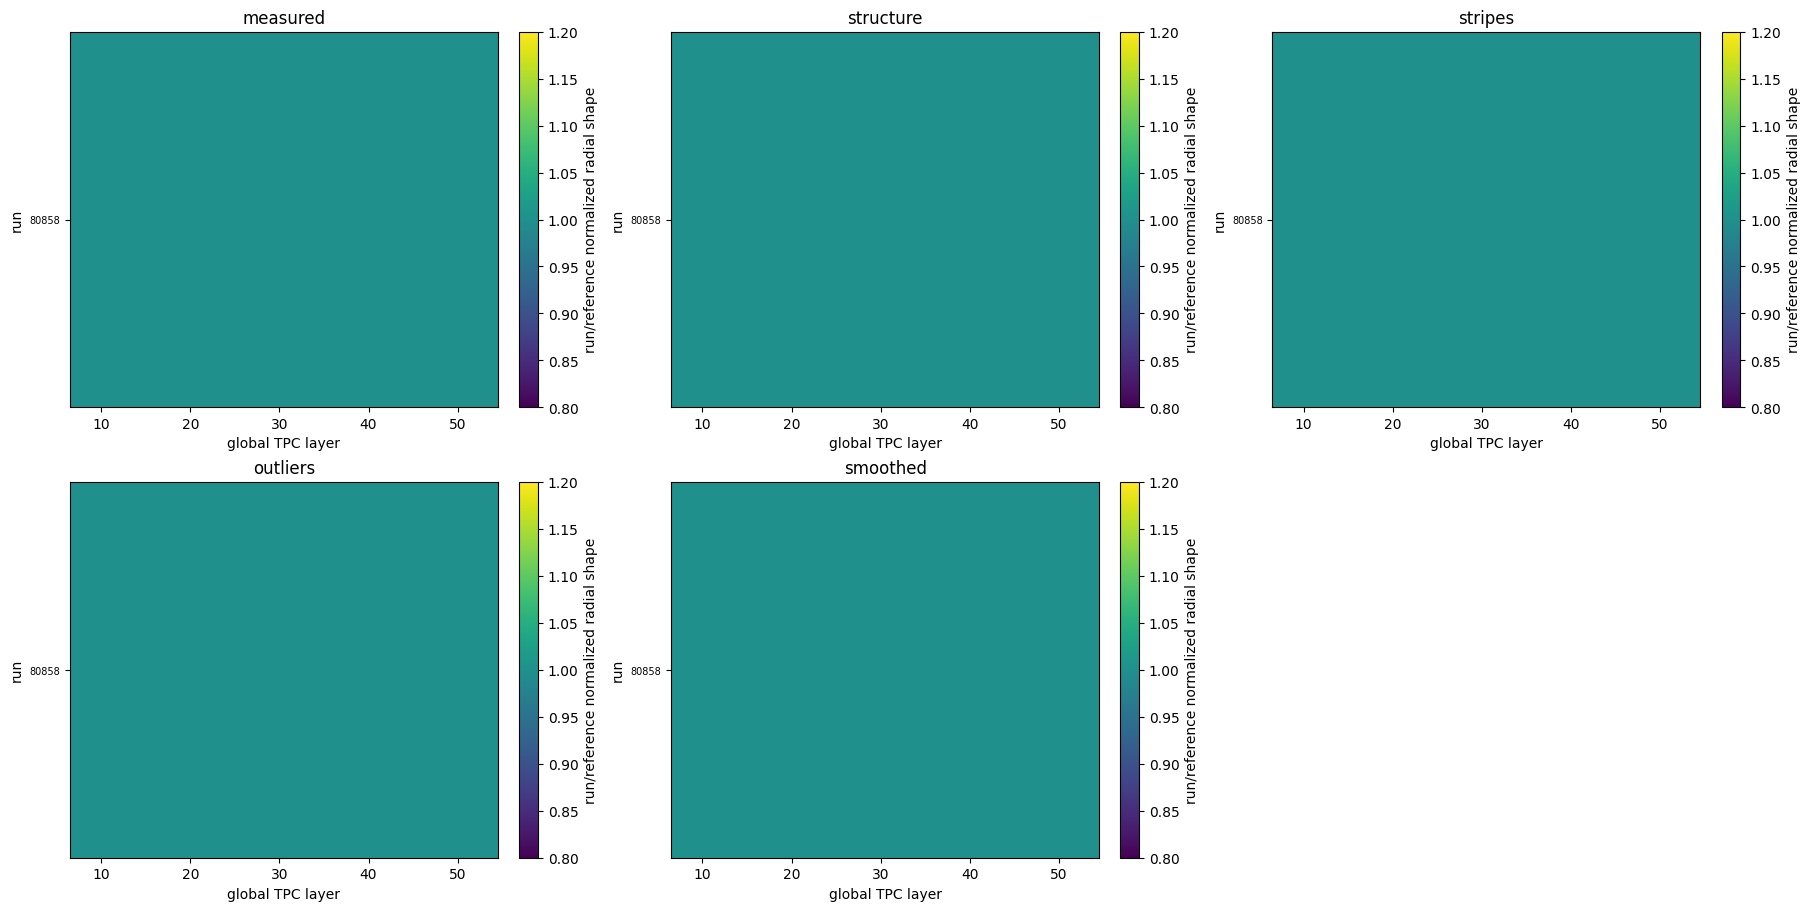

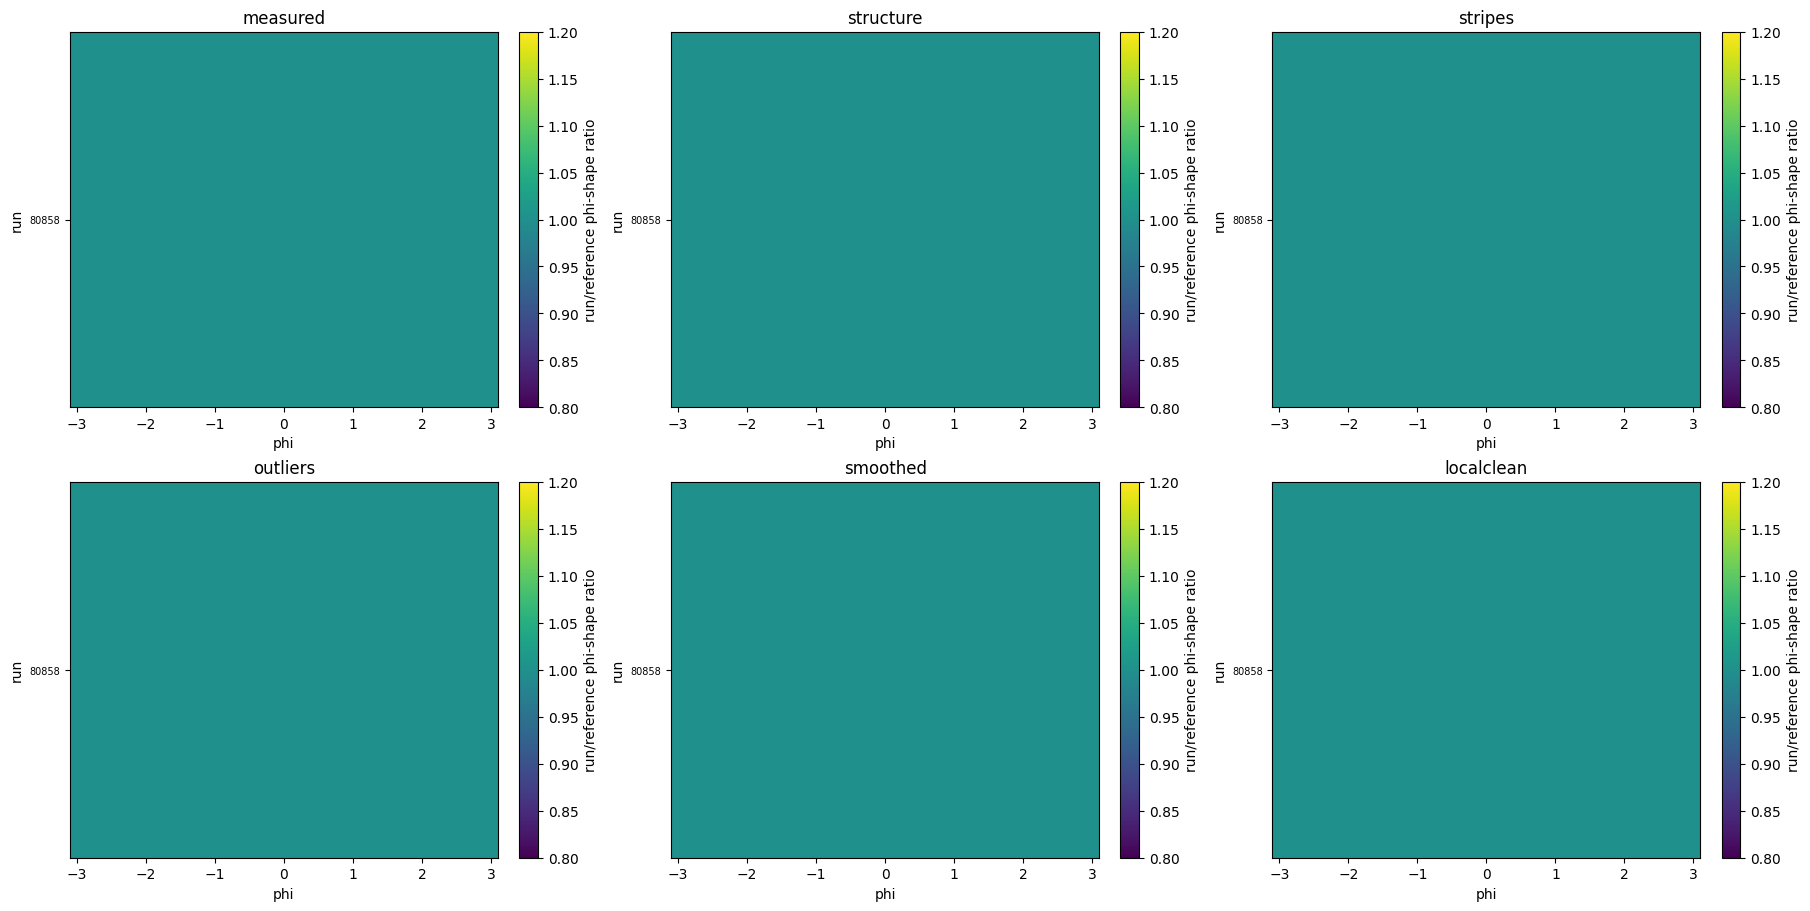

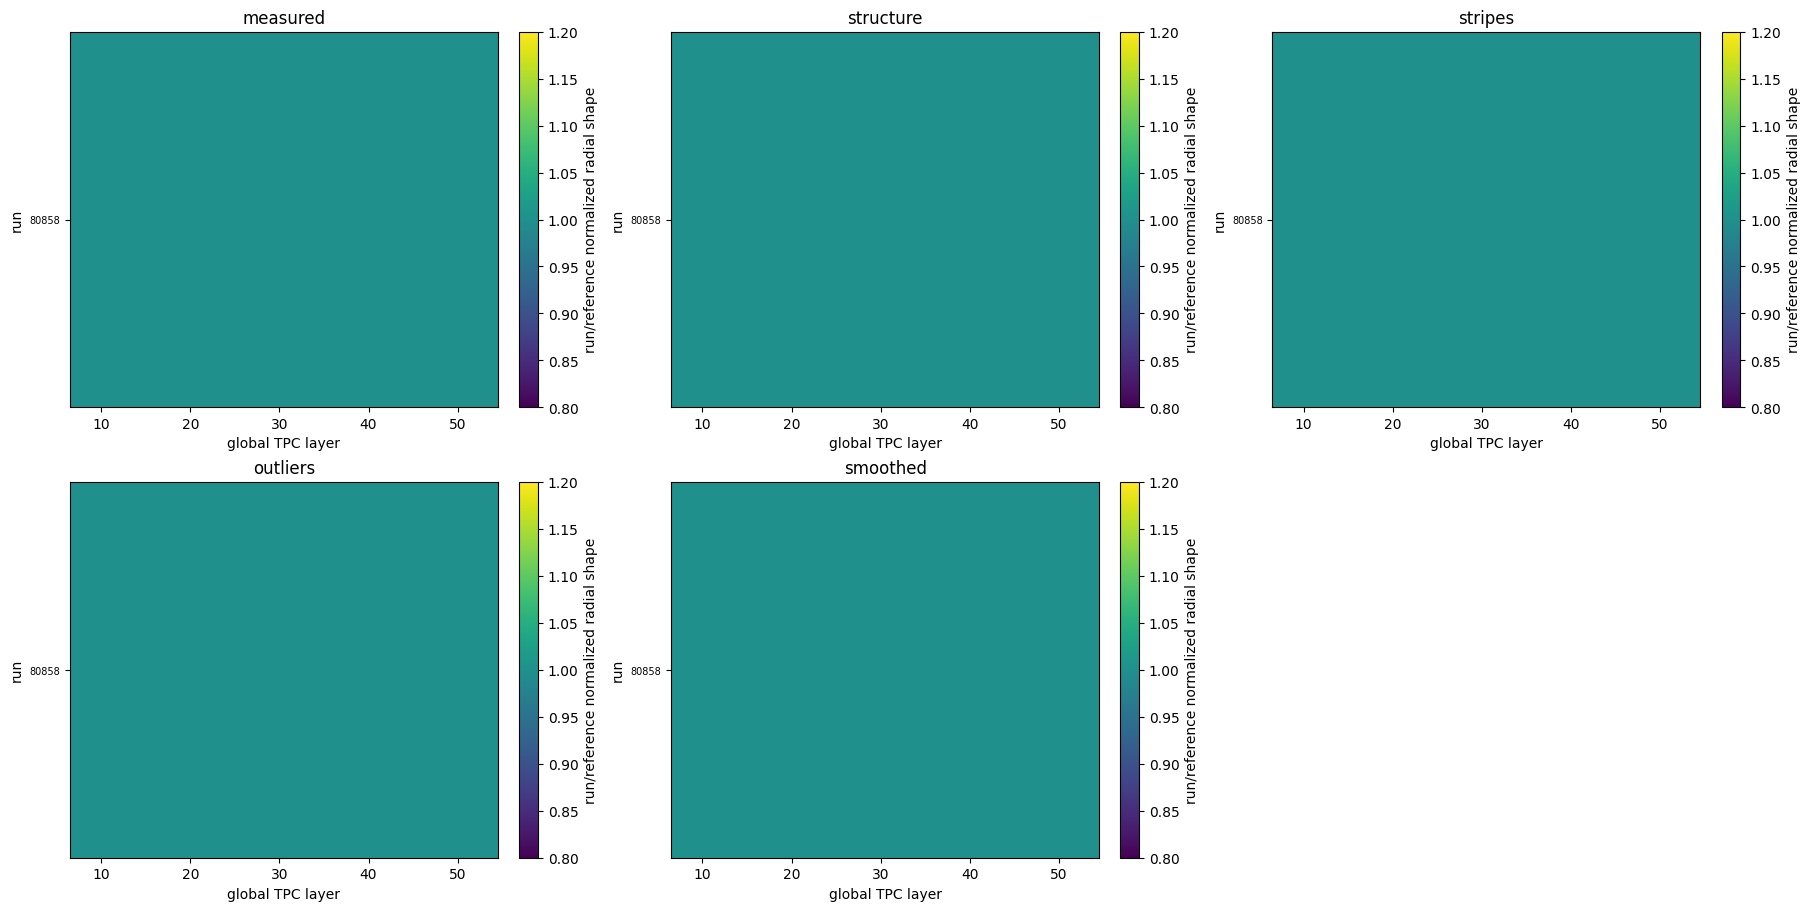

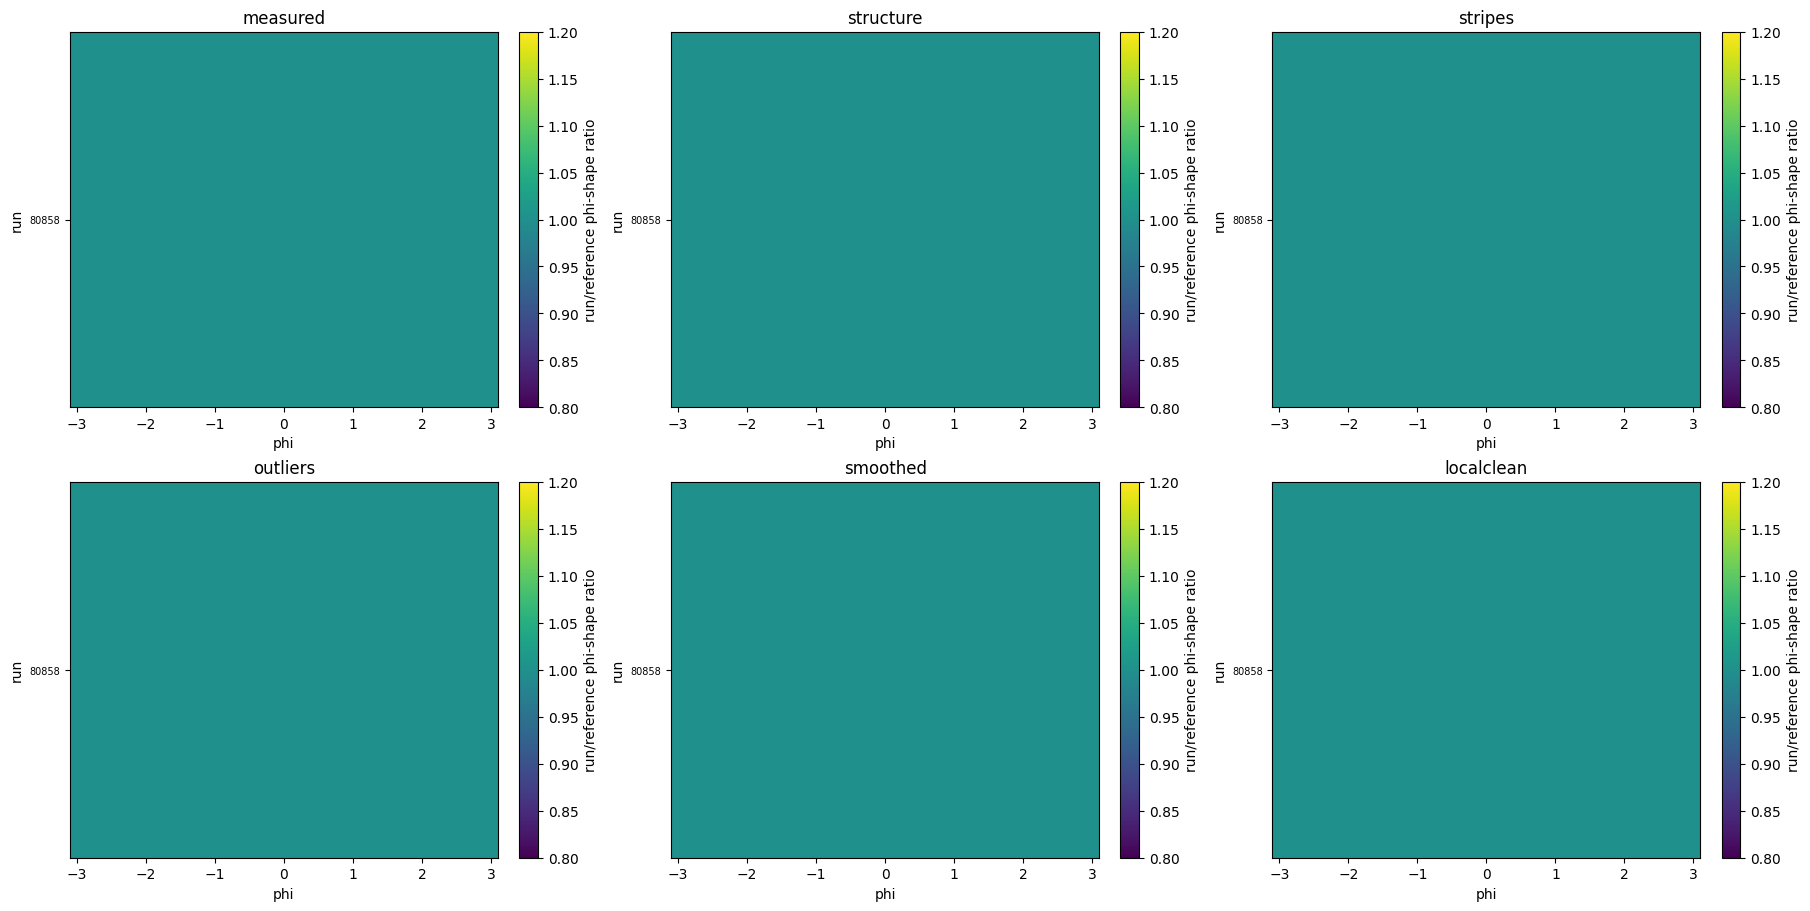

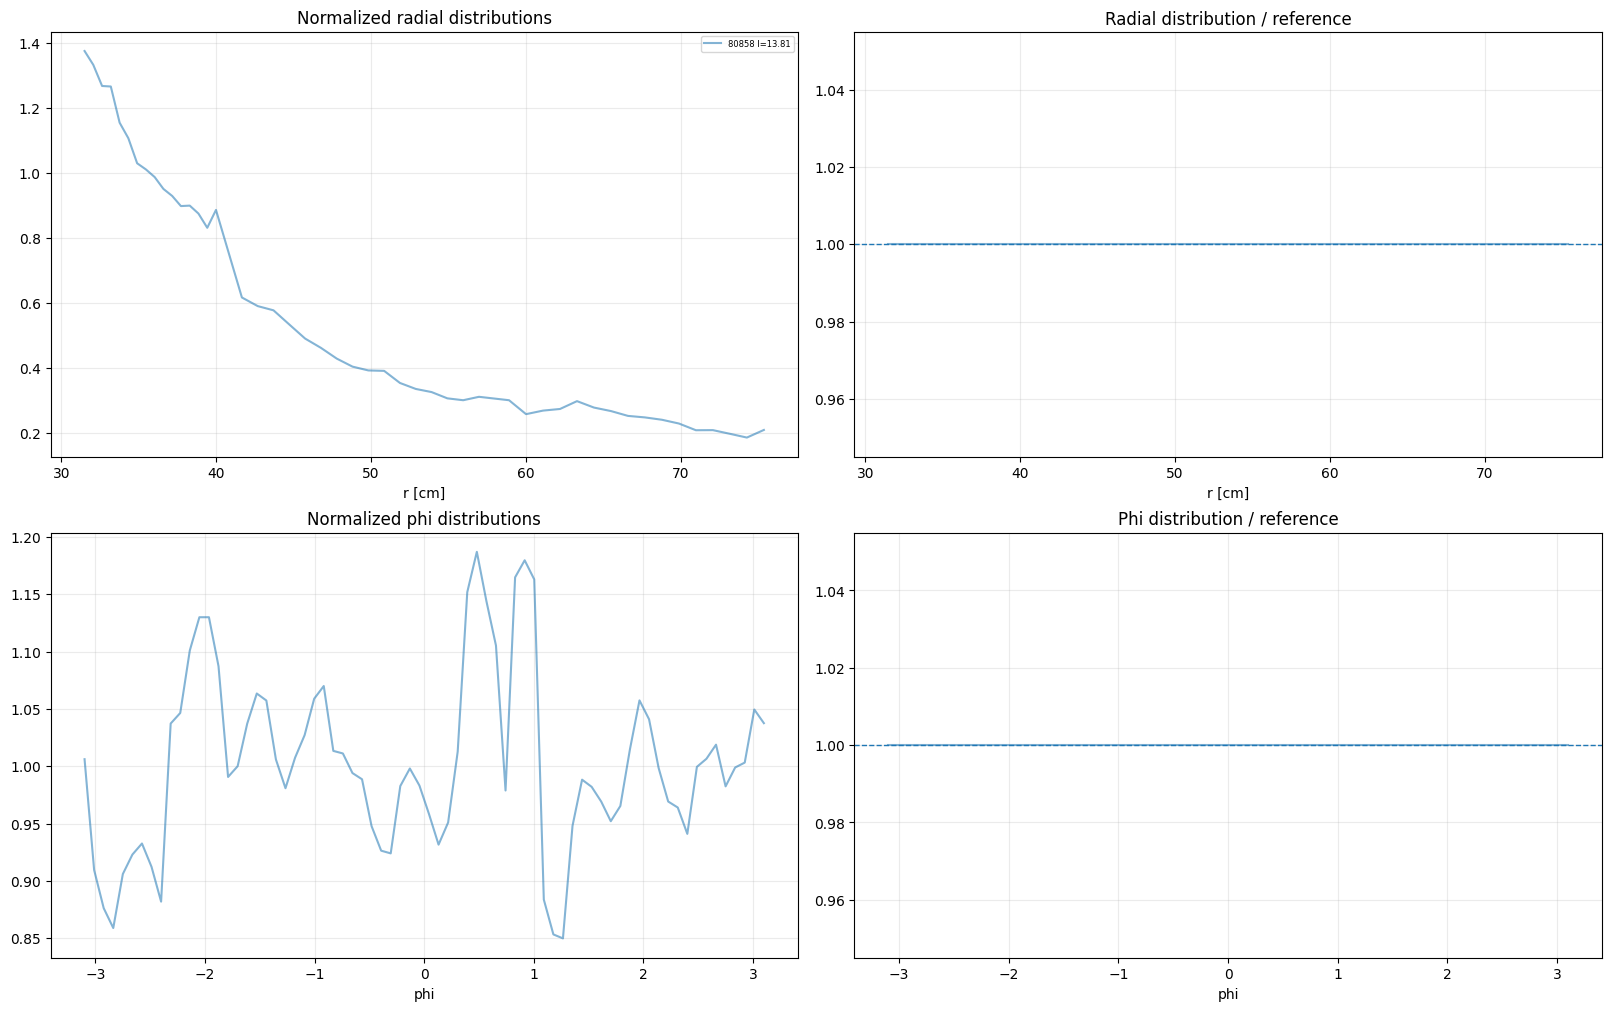

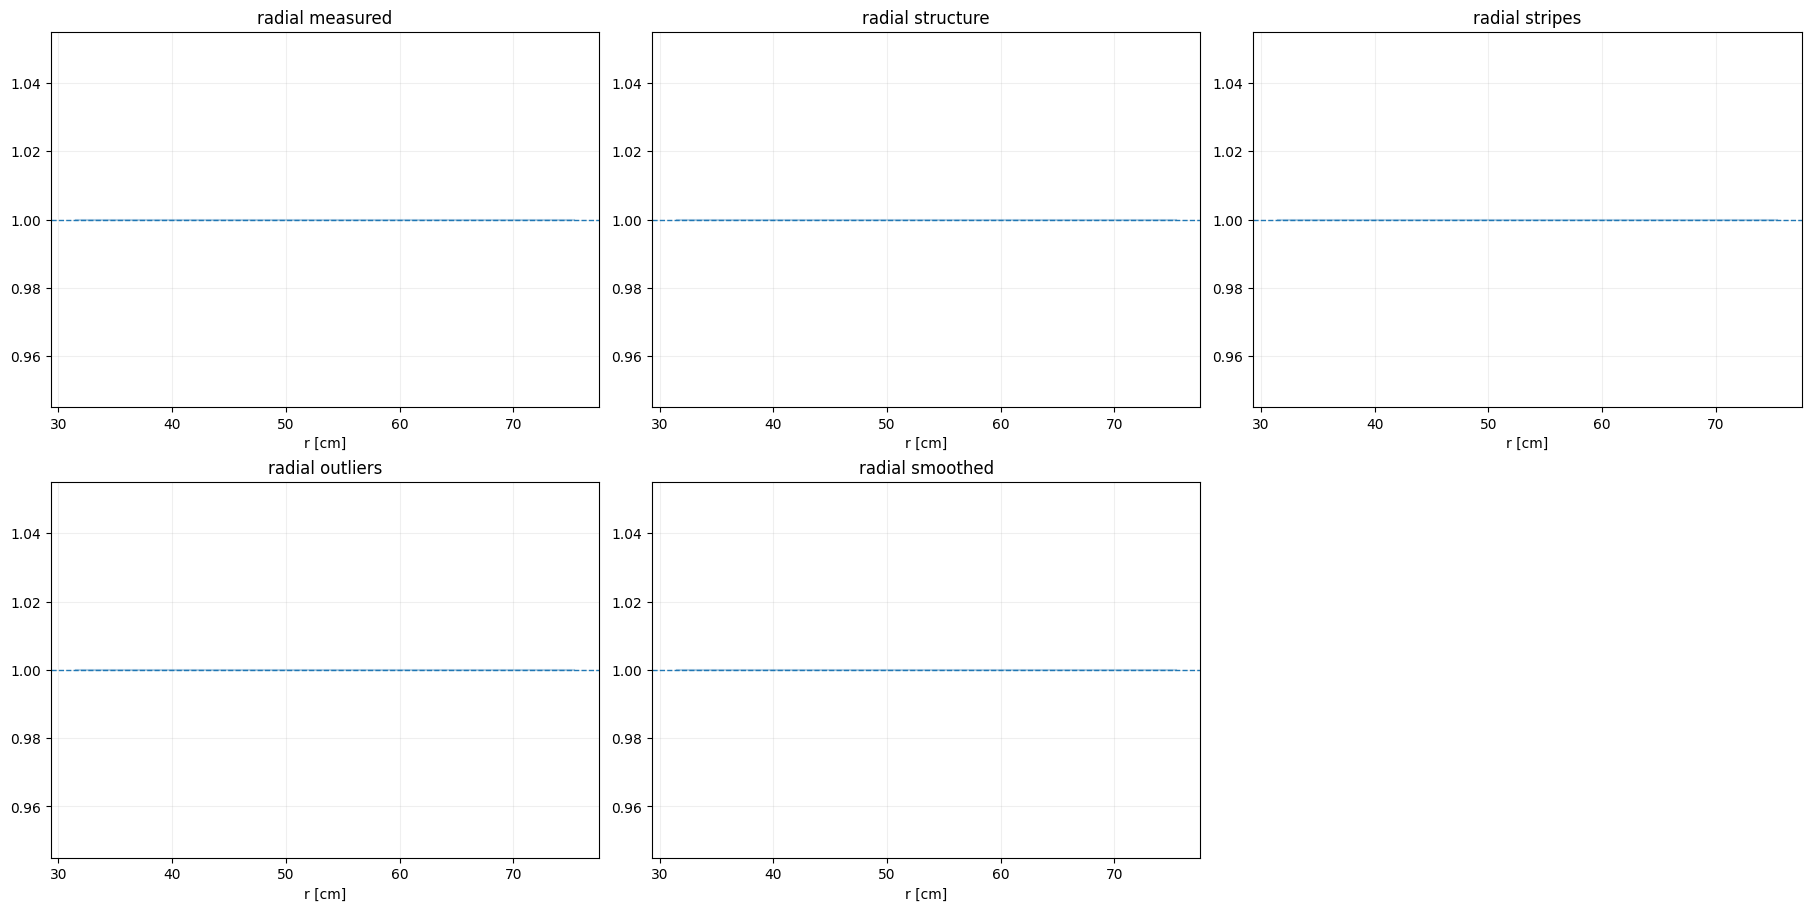

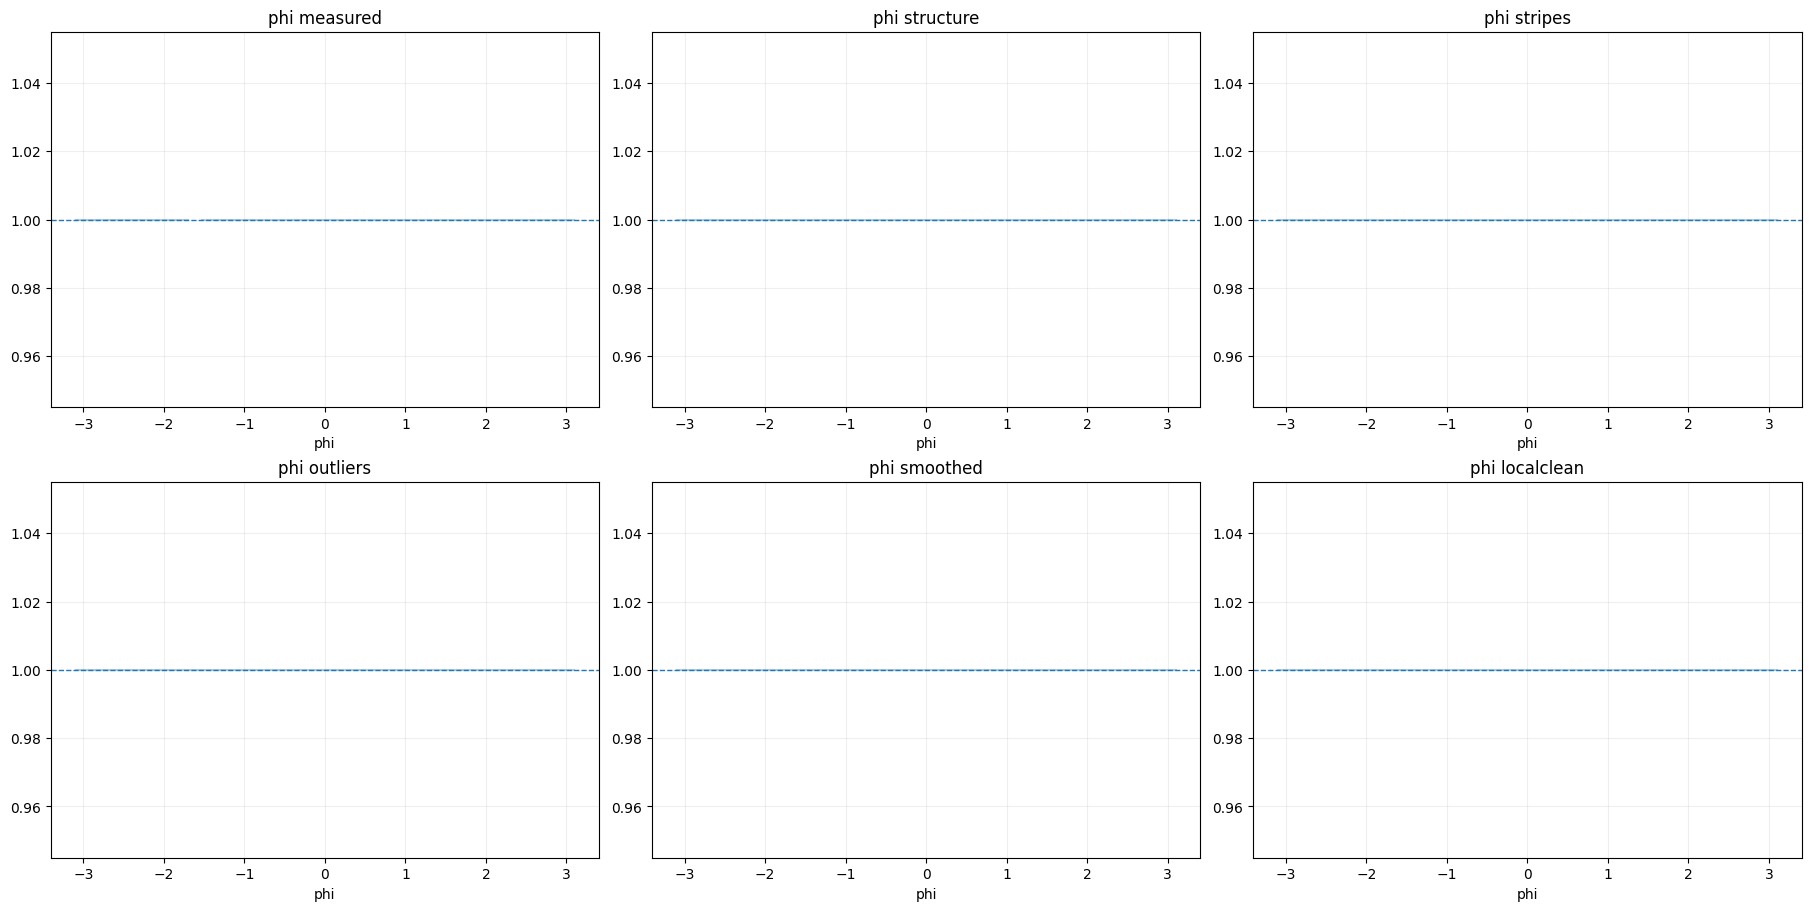

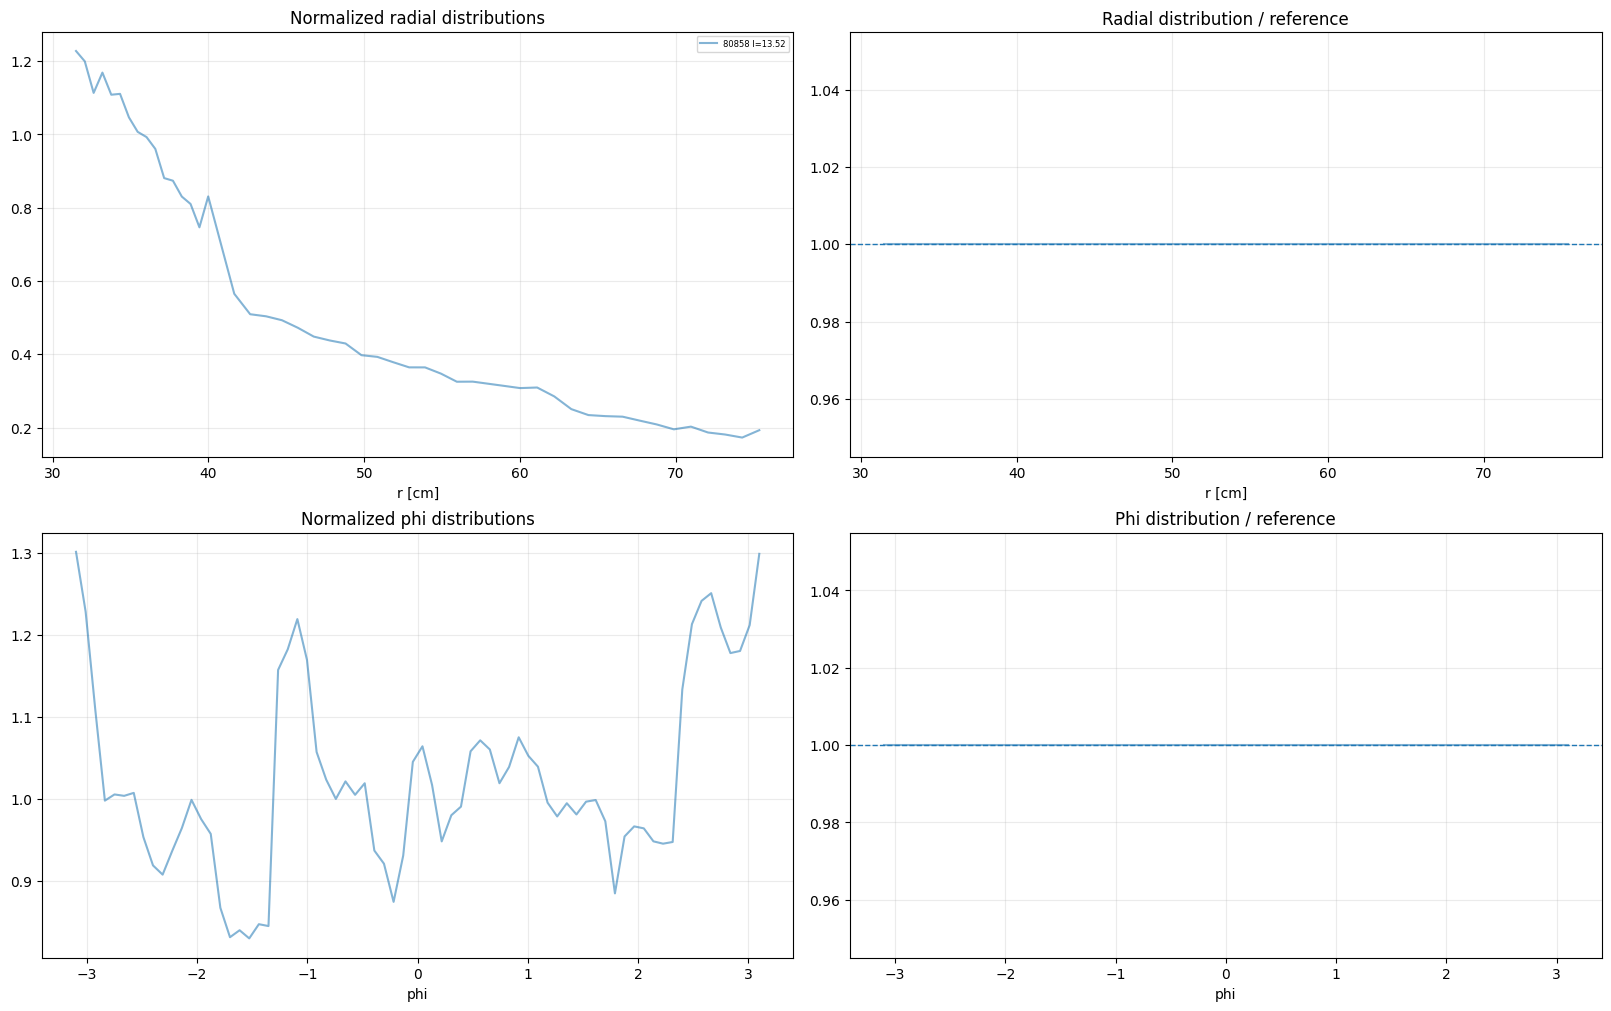

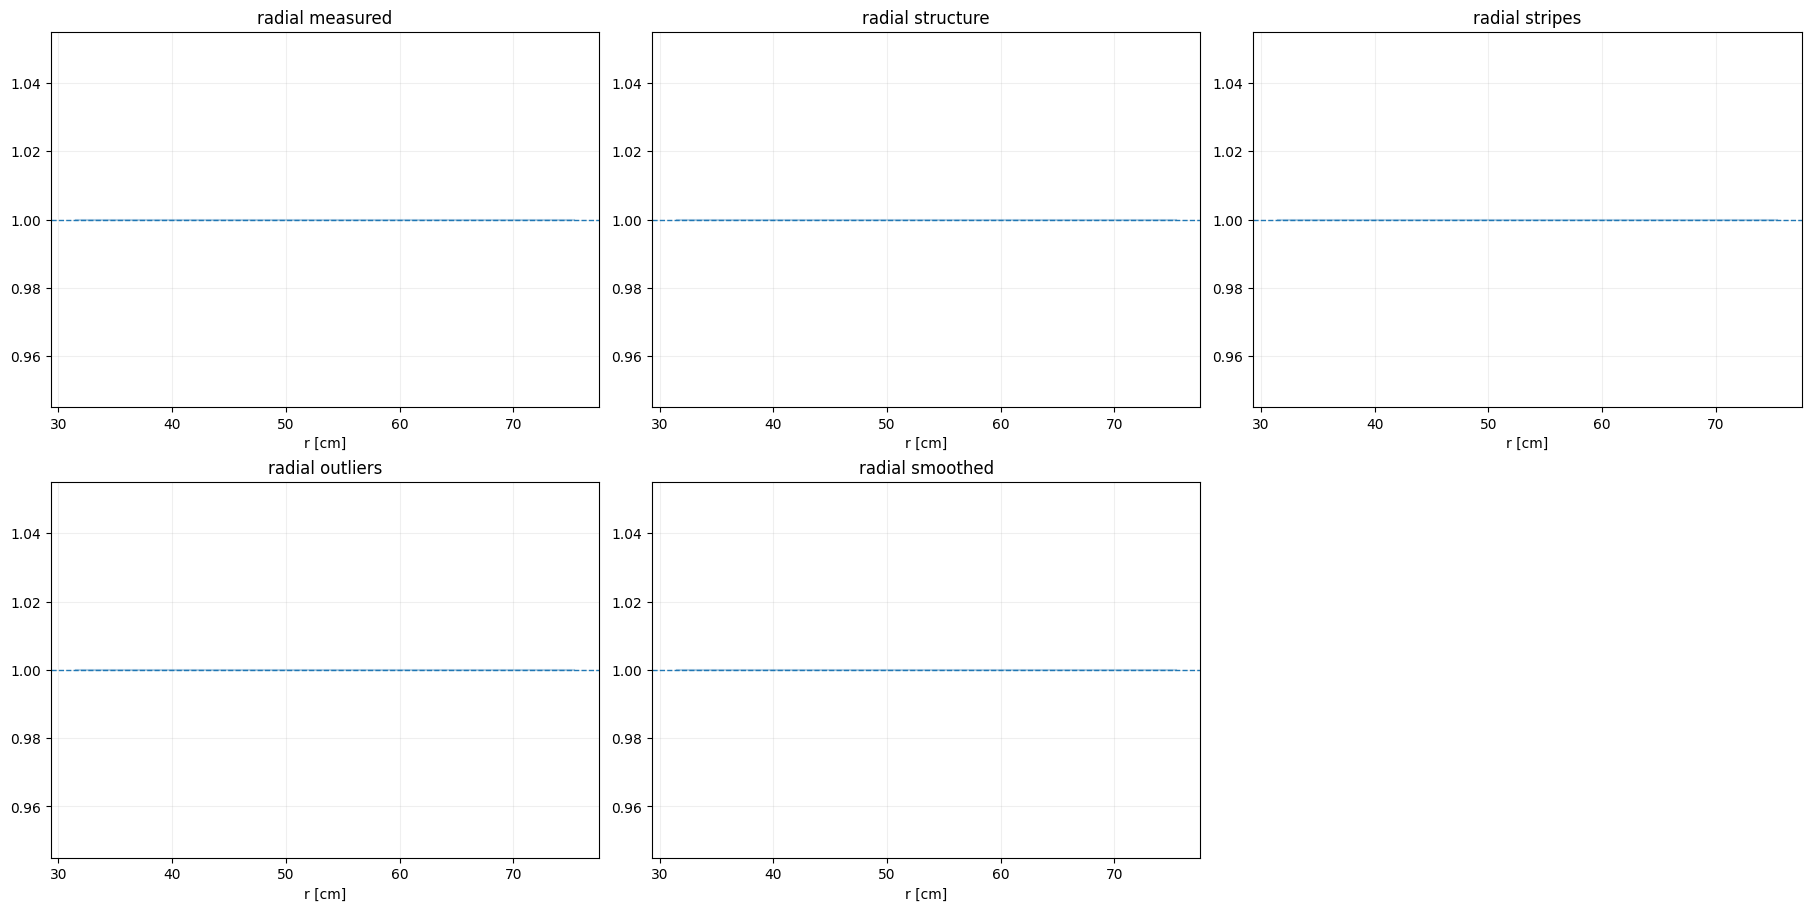

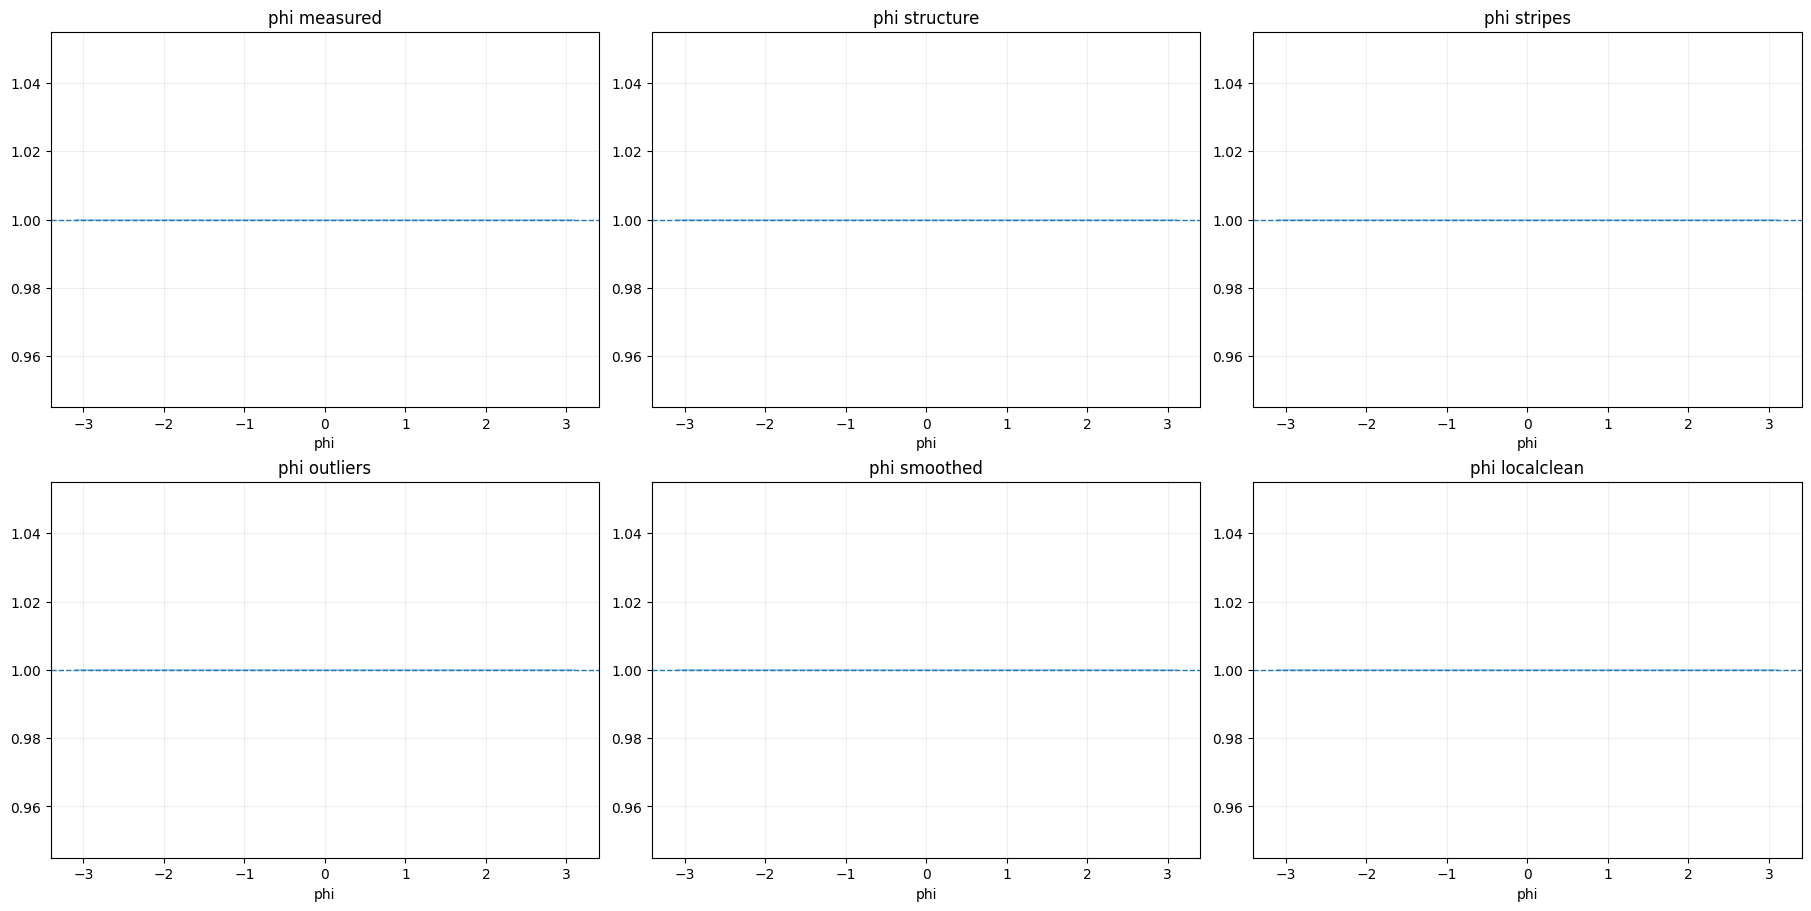

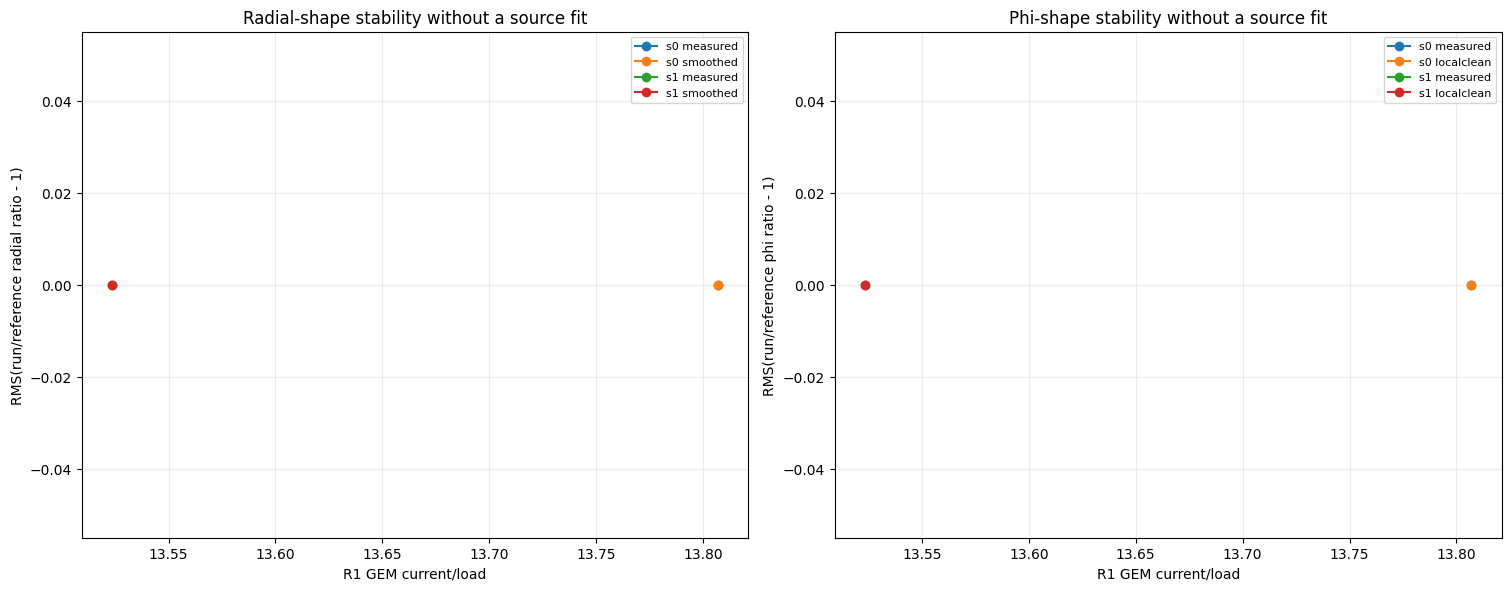

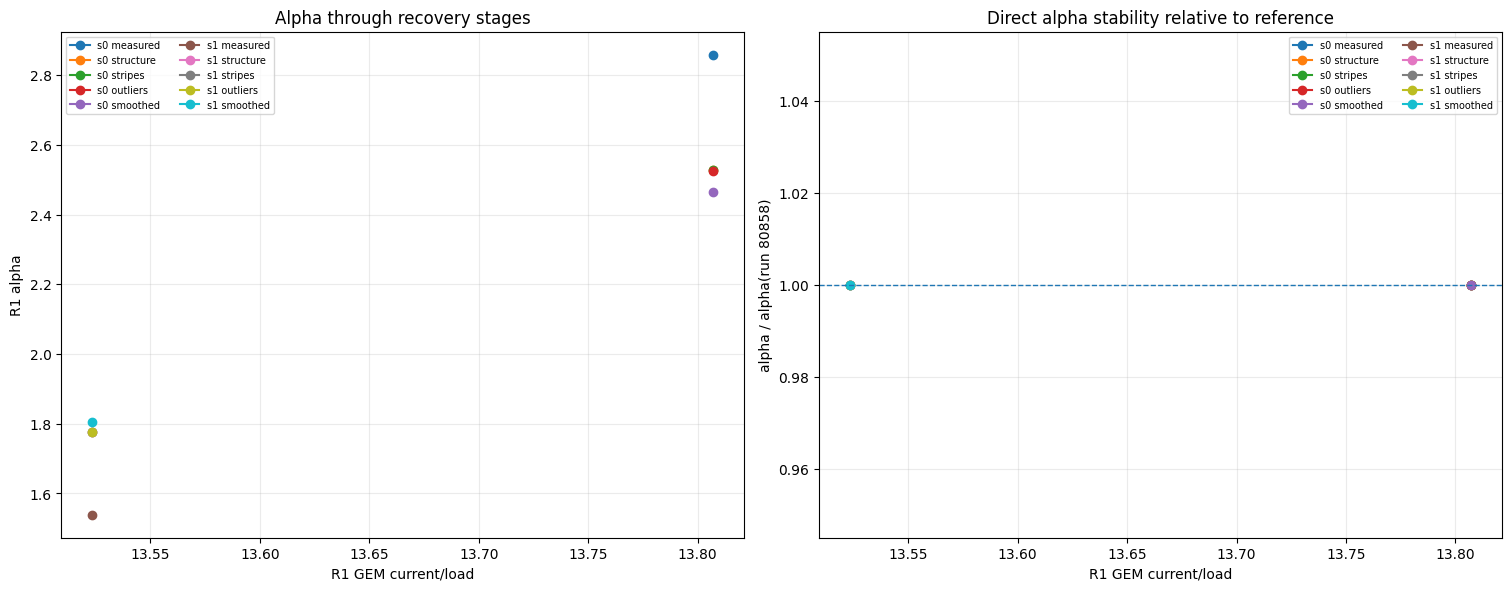

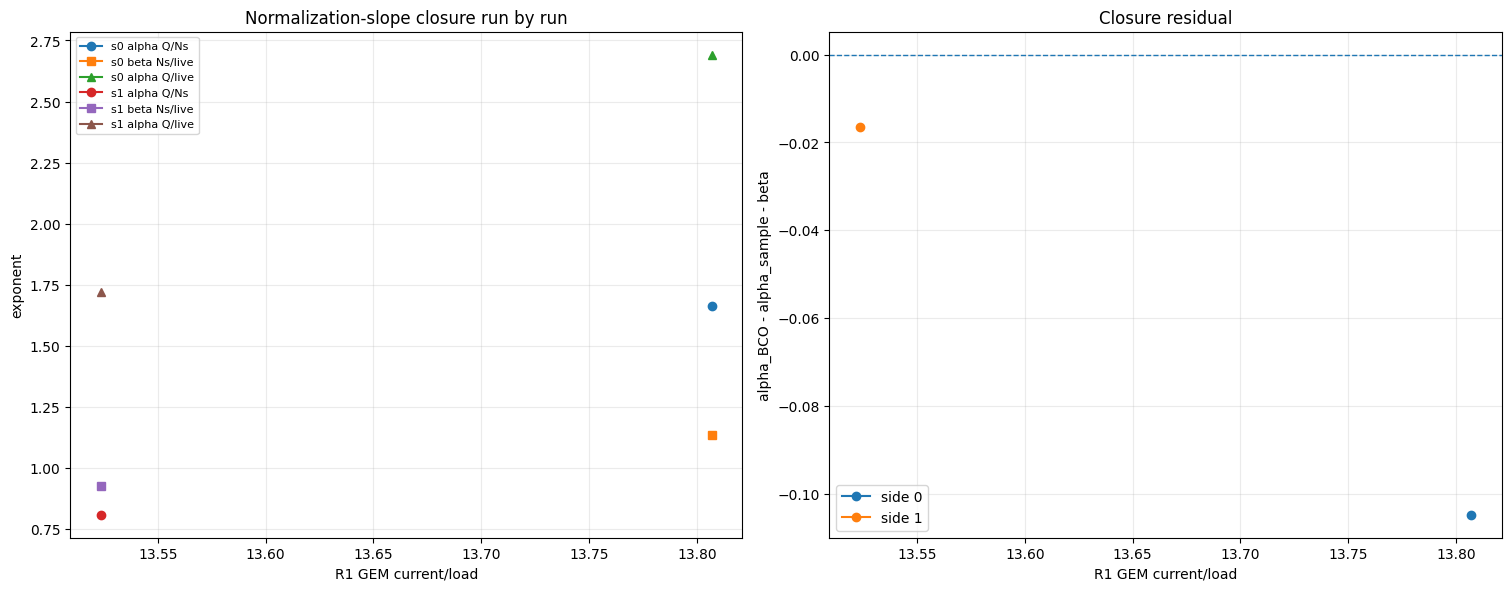

In [17]:
# v29: produce the direct r/phi run-to-reference QA once the spatial batch exists.
# Safe to run repeatedly; if the ~19 spatial products are absent it only prints a message.
_spatial_products = glob.glob(str(OUTPUT_DIR / "TPC_DC_layer_stages_v29_run*_win*.csv"))
if _spatial_products:
    radial_ratio_df, phi_ratio_df, alpha_stage_df, closure_crossrun_df = run_shape_stability_tests()
else:
    print("No v29 spatial batch products yet. Run produced_files = run_batch(discover_batch_inputs()) first.")


## 14. Fast R1 Digital-Current vs GEM-current study (recommended)

This is deliberately separate from the expensive spatial reconstruction.

For each original synchronized window it reads only the standard-R1 native histograms and computes the pedestal-subtracted integrated R1 signal per **live BCO tick**. Three versions are retained:

- **observed**: directly observed R1 channels;
- **coverage corrected**: observed sum divided by the usable-cell fraction;
- **dead-FEE recovered**: the same v20/v29 dead-FEE, block, stripe and isolated-outlier recovery is applied to the R1 map before summing.

No pad-area division, gain correction, `Nsamples` time normalization, local-rφ smoothing, or two-source fit enters this correlation. All three early/middle/late windows are cheap to read and are combined at run level by summing reconstructed charge and live BCO exposure. The window-to-window spread is shown as individual points, **not as GEM-current error bars**.

Fast GEM-current scan: 57 source ROOT files


/tmp/ipykernel_12437/643175265.py:54: RuntimeWarning: All-NaN slice encountered
  row=np.nanmedian(pos,axis=1)
/tmp/ipykernel_12437/643175265.py:55: RuntimeWarning: All-NaN slice encountered
  col=np.nanmedian(pos,axis=0)
/tmp/ipykernel_12437/643175265.py:71: RuntimeWarning: All-NaN slice encountered
  ref=np.nanmedian(


  read 10/57
  read 20/57
  read 30/57
  read 40/57
  read 50/57
  read 57/57
Wrote output_dc/TPC_DC_fast_gem_windows_v29_ped60_signed.csv
saved output_dc/fast_r1_dc_vs_gem_v29_ped60_signed.png
saved output_dc/fast_r1_dc_ratio_vs_gem_ratio_v29_ped60_signed.png
   method  side  reference_run  intercept    slope  slope_through_origin
 observed     0          80858  -0.066589 1.089450              1.007157
 observed     1          80858  -2.693527 2.846810             -0.536237
 coverage     0          80858  -0.007442 0.996432              0.987235
 coverage     1          80858  -2.513797 2.713722             -0.443586
recovered     0          80858  -0.014848 1.001545              0.983195
recovered     1          80858   0.077631 0.930658              1.028162
saved output_dc/fast_r1_dc_windows_vs_run_v29_ped60_signed.png


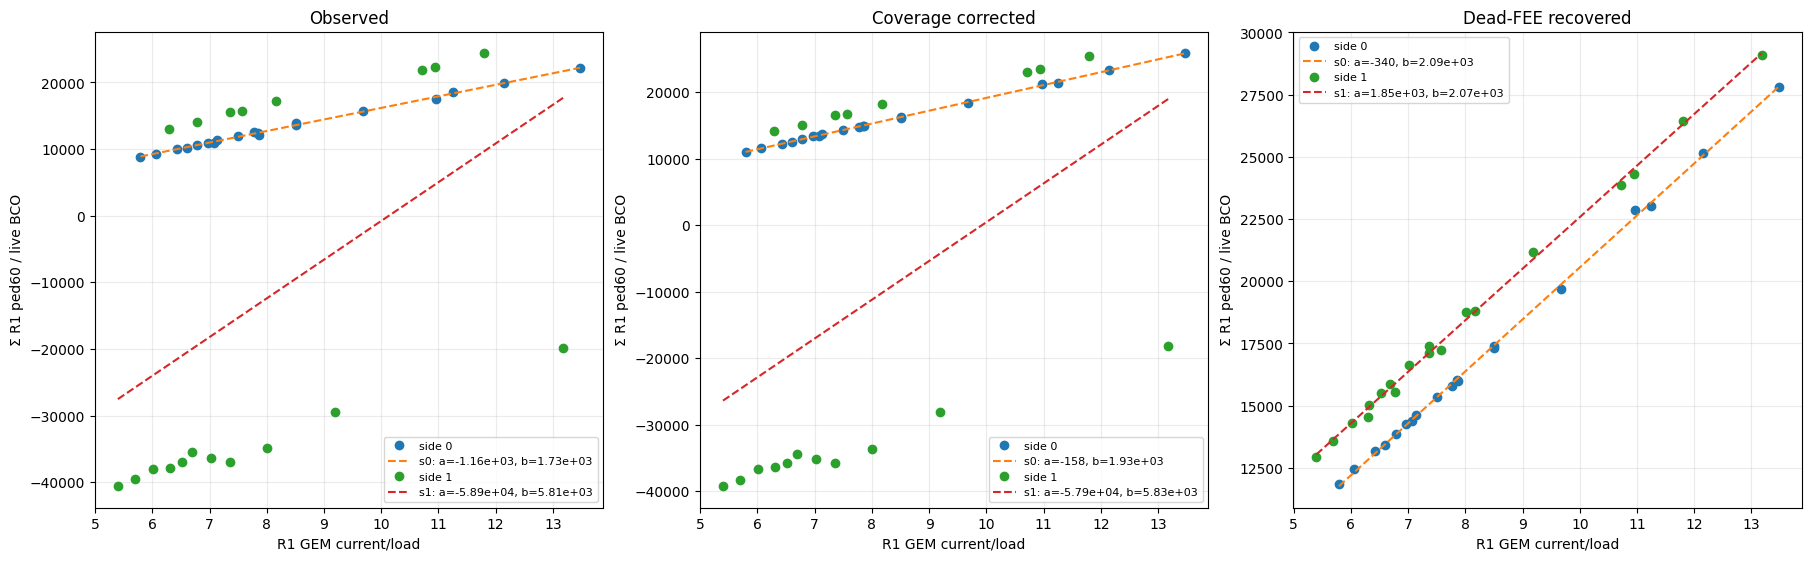

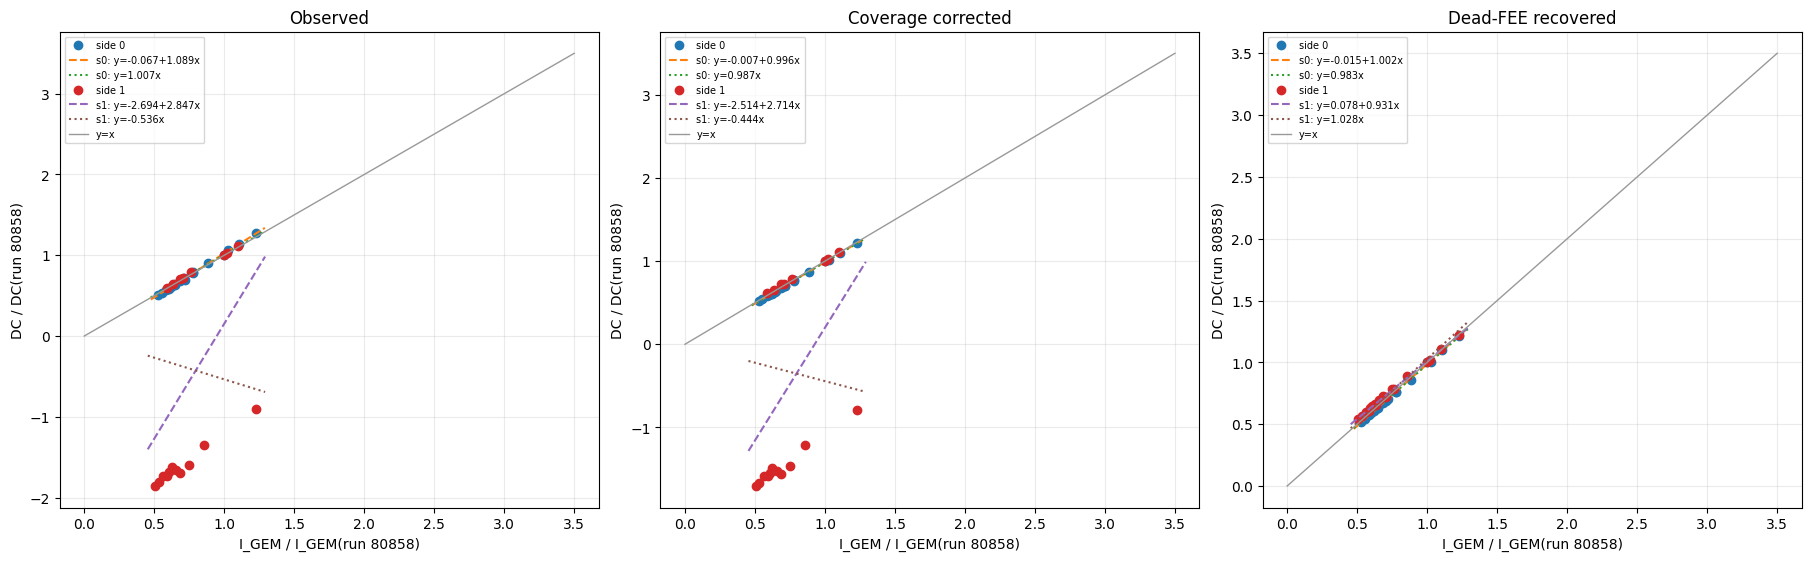

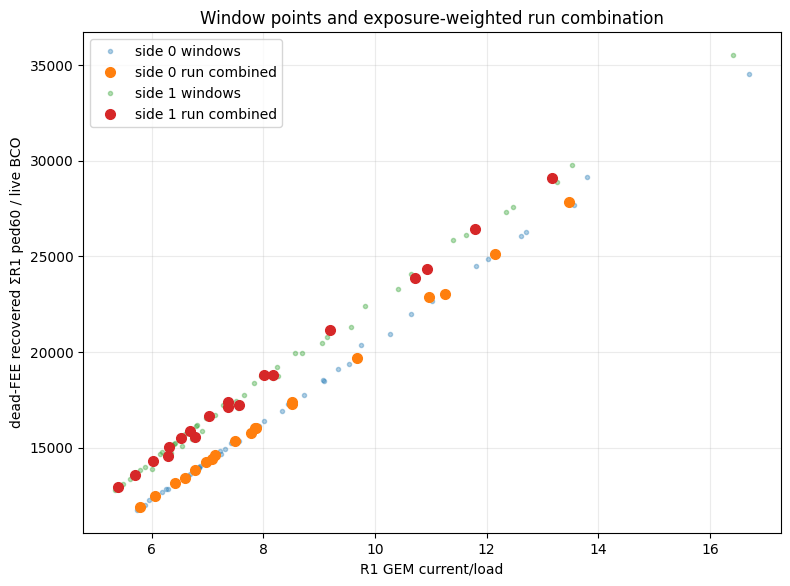

In [18]:
def _root_norm_value(f,side,label):
    h=f.Get("h_dc_norm")
    if not h:
        return np.nan
    iy=next((i for i in range(1,h.GetNbinsY()+1)
             if h.GetYaxis().GetBinLabel(i)==label),None)
    return float(h.GetBinContent(side+1,iy)) if iy else np.nan

def _r1_hist_name(kind,variant,side,sector):
    if kind=="q":
        return f"h_dc_pad_vs_layer_{variant}_side{side}_sec{sector:02d}_R1"
    if kind=="nsamples":
        return f"h_dc_nsamples_pad_vs_layer_side{side}_sec{sector:02d}_R1"
    if kind=="sampleblocks":
        return f"h_dc_sampleblocks_pad_vs_layer_side{side}_sec{sector:02d}_R1"
    raise ValueError(kind)

def _lightweight_recover_r1(target_rate,defect_rate,nsamples):
    """Apply the existing native recovery to one R1 sector without smoothing."""
    goodexp=nsamples[np.isfinite(nsamples)&(nsamples>0)]
    eref=float(np.median(goodexp)) if len(goodexp) else np.nan
    low=(~np.isfinite(nsamples))|(nsamples<=0)
    if np.isfinite(eref):
        low |= nsamples < MIN_EXPOSURE_FRACTION*eref

    mask=detect_dead_structures(defect_rate,0,low)
    a0=np.asarray(target_rate,float).copy()
    a0[low]=np.nan
    a1=repair_fee_regions(a0,mask["fee"],mask["fee_regions"],
                          mask["stripe"]|mask["block"]|low)
    a1=repair_mask_from_context(a1,mask["block"],mask["stripe"]|mask["fee"]|low)
    a2=recover_stripes(a1,mask["stripe"],mask["fee"]|mask["block"]|low)
    if REPAIR_SINGLE_OUTLIERS:
        a3,_=repair_single_outliers(a2,low)
    else:
        a3=a2
    return a3,low,mask

def read_lightweight_r1_metrics(path,variant=LIGHTWEIGHT_GEM_VARIANT):
    path=str(Path(path).resolve())
    f=root.TFile.Open(path,"READ")
    if not f or f.IsZombie():
        raise OSError(path)

    run=infer_run(path); window=infer_window(path)
    pg=f.Get("p_dc_gem_r1_current")
    gem=[float(pg.GetBinContent(1)) if pg else np.nan,
         float(pg.GetBinContent(2)) if pg else np.nan]
    rows=[]

    for side in range(2):
        live=_root_norm_value(f,side,"LIVE_BCO_TICKS")
        if not np.isfinite(live) or live<=0:
            continue

        observed_rate=0.0
        coverage_corrected_rate=0.0
        recovered_rate=0.0
        observed_cells=0
        expected_cells=0
        recovered_cells=0
        sample_norm_values=[]

        for sector in range(12):
            hq=f.Get(_r1_hist_name("q",variant,side,sector))
            hd=f.Get(_r1_hist_name("q","ped60_positive",side,sector))
            he=f.Get(_r1_hist_name("nsamples",variant,side,sector))
            if not hq or not hd or not he:
                raise KeyError(f"Missing R1 lightweight hist side={side} sec={sector} in {path}")

            q=th2_to_numpy(hq)[:16,:94]
            qdef=th2_to_numpy(hd)[:16,:94]
            ns=th2_to_numpy(he)[:16,:94]
            target=q/live
            defect=qdef/live

            finite_obs=np.isfinite(target)&np.isfinite(ns)&(ns>0)
            expected_cells += target.size
            observed_cells += int(np.count_nonzero(finite_obs))
            observed_rate += float(np.nansum(np.where(finite_obs,target,np.nan)))

            sr=safe_ratio(q,ns)
            sample_norm_values.extend(sr[np.isfinite(sr)].ravel().tolist())

            rec,low,mask=_lightweight_recover_r1(target,defect,ns)
            goodrec=np.isfinite(rec)
            recovered_cells += int(np.count_nonzero(goodrec))
            rec_sum=float(np.nansum(rec[goodrec]))
            rec_frac=np.count_nonzero(goodrec)/max(rec.size,1)
            # Remaining unrecoverable cells receive only a global coverage
            # correction; detailed dead structures are filled locally first.
            recovered_rate += rec_sum/max(rec_frac,1e-12)

            obs_frac=np.count_nonzero(finite_obs)/max(target.size,1)
            coverage_corrected_rate += float(np.nansum(np.where(finite_obs,target,np.nan)))/max(obs_frac,1e-12)

        obs_frac=observed_cells/max(expected_cells,1)
        rec_frac=recovered_cells/max(expected_cells,1)
        rows.append({
            "file":path,"run":run,"window":window,"side":side,
            "gem_current":gem[side],"live_bco_ticks":live,
            "r1_rate_observed":observed_rate,
            "r1_rate_coverage":coverage_corrected_rate,
            "r1_rate_recovered":recovered_rate,
            "r1_q_observed":observed_rate*live,
            "r1_q_coverage":coverage_corrected_rate*live,
            "r1_q_recovered":recovered_rate*live,
            "observed_cell_fraction":obs_frac,
            "recovered_cell_fraction":rec_frac,
            "legacy_q_over_nsamples_median":float(np.nanmedian(sample_norm_values)) if sample_norm_values else np.nan,
        })

    f.Close()
    return rows

def build_lightweight_gem_table(pattern=BATCH_INPUT_GLOB,variant=LIGHTWEIGHT_GEM_VARIANT):
    files=sorted(glob.glob(str(pattern)))
    rows=[]
    print(f"Fast GEM-current scan: {len(files)} source ROOT files")
    for i,p in enumerate(files,1):
        rows.extend(read_lightweight_r1_metrics(p,variant))
        if i%10==0 or i==len(files):
            print(f"  read {i}/{len(files)}")
    d=pd.DataFrame(rows).sort_values(["run","window","side"]).reset_index(drop=True)
    out=OUTPUT_DIR/f"TPC_DC_fast_gem_windows_v29_{variant}.csv"
    d.to_csv(out,index=False)
    print("Wrote",out)
    return d

def combine_lightweight_by_run(d):
    rows=[]
    for (run,side),q in d.groupby(["run","side"]):
        live=float(np.nansum(q["live_bco_ticks"]))
        if not np.isfinite(live) or live<=0:
            continue
        w=q["live_bco_ticks"].to_numpy(float)
        g=q["gem_current"].to_numpy(float)
        good=np.isfinite(w)&(w>0)&np.isfinite(g)
        gmean=float(np.sum(w[good]*g[good])/np.sum(w[good])) if np.any(good) else np.nan
        row={"run":int(run),"side":int(side),"gem_current":gmean,
             "live_bco_ticks":live,"n_windows":int(len(q))}
        for key in ("observed","coverage","recovered"):
            qsum=float(np.nansum(q[f"r1_q_{key}"]))
            row[f"r1_q_{key}"]=qsum
            row[f"r1_rate_{key}"]=qsum/live
        row["observed_cell_fraction"]=float(np.nanmean(q["observed_cell_fraction"]))
        row["recovered_cell_fraction"]=float(np.nanmean(q["recovered_cell_fraction"]))
        row["legacy_q_over_nsamples_median"]=float(np.nanmedian(q["legacy_q_over_nsamples_median"]))
        rows.append(row)
    out=pd.DataFrame(rows).sort_values(["run","side"]).reset_index(drop=True)
    out.to_csv(OUTPUT_DIR/f"TPC_DC_fast_gem_runavg_v29_{LIGHTWEIGHT_GEM_VARIANT}.csv",index=False)
    return out

def _fit_intercept_and_origin(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float)
    good=np.isfinite(x)&np.isfinite(y)
    x=x[good]; y=y[good]
    if len(x)<2:
        return (np.nan,np.nan,np.nan)
    slope,intercept=np.polyfit(x,y,1)
    slope0=float(np.sum(x*y)/np.sum(x*x)) if np.sum(x*x)>0 else np.nan
    return float(slope),float(intercept),slope0

def plot_lightweight_gem_correlation(d,runavg=None,reference_run=LIGHTWEIGHT_GEM_REFERENCE_RUN):
    if runavg is None:
        runavg=combine_lightweight_by_run(d)
    if runavg.empty:
        print("No lightweight GEM rows")
        return runavg

    available=sorted(runavg["run"].unique())
    if reference_run not in available:
        reference_run=available[0]
        print(f"Requested reference missing; using run {reference_run}")

    # 1) Absolute BCO-normalized signal vs GEM current.
    fig,ax=plt.subplots(1,3,figsize=(18,5.5),constrained_layout=True)
    methods=[("observed","Observed"),("coverage","Coverage corrected"),("recovered","Dead-FEE recovered")]
    for ia,(key,title) in enumerate(methods):
        for side in range(2):
            q=runavg[runavg["side"]==side]
            ax[ia].plot(q["gem_current"],q[f"r1_rate_{key}"],"o",label=f"side {side}")
            slope,intercept,_=_fit_intercept_and_origin(q["gem_current"],q[f"r1_rate_{key}"])
            if np.isfinite(slope):
                xx=np.linspace(q["gem_current"].min(),q["gem_current"].max(),100)
                ax[ia].plot(xx,intercept+slope*xx,"--",label=f"s{side}: a={intercept:.3g}, b={slope:.3g}")
        ax[ia].set_title(title)
        ax[ia].set_xlabel("R1 GEM current/load")
        ax[ia].set_ylabel("Σ R1 ped60 / live BCO")
        ax[ia].grid(True,alpha=0.25); ax[ia].legend(fontsize=8)
    p=OUTPUT_DIR/f"fast_r1_dc_vs_gem_v29_{LIGHTWEIGHT_GEM_VARIANT}.png"
    fig.savefig(p,dpi=180,bbox_inches="tight"); print("saved",p)

    # 2) Reference-normalized relation, directly comparable to the old streaming plot.
    fig,ax=plt.subplots(1,3,figsize=(18,5.5),constrained_layout=True)
    fit_rows=[]
    for ia,(key,title) in enumerate(methods):
        for side in range(2):
            q=runavg[runavg["side"]==side].copy()
            ref=q[q["run"]==reference_run]
            if ref.empty: continue
            gx=float(ref.iloc[0]["gem_current"])
            gy=float(ref.iloc[0][f"r1_rate_{key}"])
            q["xratio"]=q["gem_current"]/gx
            q["yratio"]=q[f"r1_rate_{key}"]/gy
            ax[ia].plot(q["xratio"],q["yratio"],"o",label=f"side {side}")
            slope,intercept,slope0=_fit_intercept_and_origin(q["xratio"],q["yratio"])
            xx=np.linspace(max(0,float(q["xratio"].min())*0.9),float(q["xratio"].max())*1.05,100)
            ax[ia].plot(xx,intercept+slope*xx,"--",label=f"s{side}: y={intercept:.3f}+{slope:.3f}x")
            ax[ia].plot(xx,slope0*xx,":",label=f"s{side}: y={slope0:.3f}x")
            fit_rows.append({"method":key,"side":side,"reference_run":reference_run,
                             "intercept":intercept,"slope":slope,"slope_through_origin":slope0})
        ax[ia].plot([0,3.5],[0,3.5],color="0.6",lw=1,label="y=x")
        ax[ia].set_title(title)
        ax[ia].set_xlabel(f"I_GEM / I_GEM(run {reference_run})")
        ax[ia].set_ylabel(f"DC / DC(run {reference_run})")
        ax[ia].grid(True,alpha=0.25); ax[ia].legend(fontsize=7)
    p=OUTPUT_DIR/f"fast_r1_dc_ratio_vs_gem_ratio_v29_{LIGHTWEIGHT_GEM_VARIANT}.png"
    fig.savefig(p,dpi=180,bbox_inches="tight"); print("saved",p)
    fits=pd.DataFrame(fit_rows)
    fits.to_csv(OUTPUT_DIR/f"TPC_DC_fast_gem_fits_v29_{LIGHTWEIGHT_GEM_VARIANT}.csv",index=False)
    print(fits.to_string(index=False))

    # 3) Window-level points show time evolution without pretending the spread is an error bar.
    fig,ax=plt.subplots(figsize=(9,6.5))
    for side in range(2):
        q=d[d["side"]==side]
        ax.plot(q["gem_current"],q["r1_rate_recovered"],".",alpha=0.35,label=f"side {side} windows")
        r=runavg[runavg["side"]==side]
        ax.plot(r["gem_current"],r["r1_rate_recovered"],"o",ms=7,label=f"side {side} run combined")
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("dead-FEE recovered ΣR1 ped60 / live BCO")
    ax.set_title("Window points and exposure-weighted run combination")
    ax.grid(True,alpha=0.25); ax.legend()
    p=OUTPUT_DIR/f"fast_r1_dc_windows_vs_run_v29_{LIGHTWEIGHT_GEM_VARIANT}.png"
    fig.savefig(p,dpi=180,bbox_inches="tight"); print("saved",p)
    return runavg

# Recommended fast study (all 57 source windows, no notebook reruns):
gem_windows = build_lightweight_gem_table()
gem_runs = combine_lightweight_by_run(gem_windows)
plot_lightweight_gem_correlation(gem_windows, gem_runs)


def plot_lightweight_normalization_qa(gem_runs):
    """Show why Q/Nsamples and Q/live-BCO answer different questions."""
    if gem_runs is None or len(gem_runs)==0:
        return
    fig,ax=plt.subplots(1,2,figsize=(14,5.5),constrained_layout=True)
    for side in (0,1):
        q=gem_runs[gem_runs["side"]==side].sort_values("gem_current")
        ax[0].plot(q["gem_current"],q["r1_rate_recovered"],"o-",label=f"side {side}")
        ax[1].plot(q["gem_current"],q["legacy_q_over_nsamples_median"],"o-",label=f"side {side}")
    ax[0].set_title("Recovered R1 Q/live BCO")
    ax[0].set_ylabel("R1 recovered charge rate")
    ax[1].set_title("Legacy median Q/Nsamples")
    ax[1].set_ylabel("median Q/Nsamples")
    for a in ax:
        a.set_xlabel("R1 GEM current/load"); a.grid(True,alpha=.25); a.legend()
    p=OUTPUT_DIR/"fast_normalization_comparison_v29.png"
    fig.savefig(p,dpi=170,bbox_inches="tight"); print("saved",p)

# After build_lightweight_gem_table/combine_lightweight_by_run:
# plot_lightweight_normalization_qa(gem_runs)
